---
# PART 1 - PGA-UNet (IMG_SIZE=256)
---

# PGA-UNet - Test & Visualization (IMG_SIZE=256)
**Checkpoint**: fill in `CKPT_ID` in the setup cell

Run in order: **Setup → Test → Visualization**

In [1]:
# ── Setup ──────────────────────────────────────────────────────────
%cd /kaggle/working
import os, gdown, torch

print("CUDA:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Clone repo
if not os.path.exists('PGA_Unet2D'):
    !git clone --branch main --single-branch https://github.com/ThongLuc2k3/PGA_Unet2D.git
else:
    !cd PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation && git pull -q

# Dataset
!gdown --id 1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv -O /kaggle/working/dataset_FracAtlas.zip -q
!unzip -oq /kaggle/working/dataset_FracAtlas.zip -d /kaggle/working/
!rsync -a /kaggle/working/dataset_FracAtlas/ /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset_FracAtlas/ 2>/dev/null

%cd /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation
!pip install -q tqdm opencv-python matplotlib gdown scipy

# ── Checkpoint ─────────────────────────────────────────────────────
CKPT_ID   = '1U9CNawER4ckiFBUGpb_K1CoDxhtU5kWG'
CKPT_PATH = '/kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_256_best.pth'
os.makedirs(os.path.dirname(CKPT_PATH), exist_ok=True)
assert CKPT_ID, '❌ CKPT_ID is missing - upload the checkpoint to Drive and fill in the ID here'
gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_PATH, quiet=False)
assert os.path.exists(CKPT_PATH)
print(f'\n✅ Setup complete  |  {os.path.getsize(CKPT_PATH)//1024} KB')


/kaggle/working
CUDA: True
GPU: Tesla T4
Cloning into 'PGA_Unet2D'...
remote: Enumerating objects: 4402, done.
remote: Counting objects: 100% (639/639), done.
remote: Compressing objects: 100% (302/302), done.
remote: Total 4402 (delta 440), reused 477 (delta 336), pack-reused 3763 (from 2)
Receiving objects: 100% (4402/4402), 1.21 GiB | 40.79 MiB/s, done.
Resolving deltas: 100% (2654/2654), done.
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
/kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation


Downloading...
From: https://drive.google.com/uc?id=1U9CNawER4ckiFBUGpb_K1CoDxhtU5kWG
To: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/checkpoints/pga_unet_center_mixed_x3_shift05_qhead_256_best.pth
100%|██████████| 11.9M/11.9M [00:00<00:00, 55.7MB/s]


✅ Setup complete  |  11645 KB


## Test - 2 prompt modes (image-level merging)

In [2]:
# ── Test: 2 prompt modes - image-level merging ─────────────────────
import os, cv2, csv
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from scipy.ndimage import binary_erosion, distance_transform_edt
from collections import OrderedDict
import sys

# ── Ensure that the correct PGA dataset is imported (avoid stale cache from SAM-Med2D or U-Net) ──────
_PGA_PATH = '/kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation'
for _k in list(sys.modules.keys()):
    if any(x in _k for x in ('dataset', 'models', 'prompt_unet', 'unet')):
        del sys.modules[_k]
if _PGA_PATH in sys.path: sys.path.remove(_PGA_PATH)
sys.path.insert(0, _PGA_PATH)

import importlib as _importlib
if 'dataset' in sys.modules: del sys.modules['dataset']
_importlib.invalidate_caches()
from dataset import PromptSegmentationDataset
from models.networks.prompt_unet_2D import PGA_UNet

# Quick signature check to confirm the correct file is loaded
import inspect as _ins
assert 'prompt_mode' in _ins.signature(PromptSegmentationDataset.__init__).parameters, \
    f'❌ Incorrect dataset.py imported. Actual module: {PromptSegmentationDataset.__module__}'
print(f'✅ PromptSegmentationDataset OK - {_PGA_PATH}/dataset.py')

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 256
IMG_DIR  = f'{_PGA_PATH}/dataset_FracAtlas/test/images'
JSON_DIR = f'{_PGA_PATH}/dataset_FracAtlas/test/annotations'
os.makedirs(f'{_PGA_PATH}/results', exist_ok=True)

model = PGA_UNet(in_channels=1, n_classes=1, use_encoder_prompt=True).to(DEVICE)
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE, weights_only=True))
model.eval()
print(f'✅ Model loaded  device={DEVICE}')

def calc_hd95(pred, gt):
    p, g = pred.astype(bool), gt.astype(bool)
    if not p.any() and not g.any(): return 0.0
    if not p.any() or not g.any(): return float(IMG_SIZE)
    pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
    d1 = distance_transform_edt(~ge)[pe]; d2 = distance_transform_edt(~pe)[ge]
    return float(IMG_SIZE) if not len(d1) or not len(d2) else float(max(np.percentile(d1,95), np.percentile(d2,95)))

def calc_metrics_img(prob_np, gt_np):
    pm = (prob_np > 0.5).astype(np.float32)
    gm = (gt_np  > 0.5).astype(np.float32); eps = 1e-6
    tp = (pm * gm).sum(); fp = (pm * (1-gm)).sum(); fn = ((1-pm) * gm).sum()
    hd95 = calc_hd95(pm, gm)
    if gm.sum() == 0 or pm.sum() == 0:
        cbl = 0.0
    else:
        ys, xs = np.where(gm > 0.5); yp, xp = np.where(pm > 0.5)
        bbox_diag = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + eps
        cbl = float(np.clip(1. - np.sqrt((xp.mean()-xs.mean())**2 + (yp.mean()-ys.mean())**2) / bbox_diag, 0, 1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp + eps) / (tp + fp + fn + eps)),
                precision=float(tp / (tp + fp+eps)),   recall=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl)

KEYS  = ['dice', 'iou', 'precision', 'recall', 'hd95', 'cbl']
HDRS  = ['Dice\u2191', 'IoU\u2191', 'Prec\u2191', 'Rec\u2191', 'HD95\u2193', 'CBL\u2191']
MODES = ['center_zoom', 'center_shift']
all_image_records = {}
pga_results = {}   # used in the summary cell
csv_rows = []

for mode in MODES:
    ds     = PromptSegmentationDataset(IMG_DIR, JSON_DIR, img_size=IMG_SIZE, is_train=False, prompt_mode=mode)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=0)

    groups = OrderedDict()
    for i, (img_t, mask_t, prompt_t) in enumerate(tqdm(loader, desc=f'[{mode}]')):
        img_name, _ = ds.all_samples[i]
        gt_np     = mask_t[0, 0].numpy()
        prompt_np = prompt_t[0, 0].numpy()
        with torch.no_grad():
            prob = torch.sigmoid(model(img_t.to(DEVICE), prompt_t.to(DEVICE)))[0, 0].cpu().numpy()
        if img_name not in groups:
            groups[img_name] = dict(img=img_t[0, 0].numpy(),
                                    gt_union=gt_np.copy(),
                                    prob_max=prob.copy(),
                                    prompts=[prompt_np])
        else:
            g = groups[img_name]
            np.maximum(g['gt_union'], gt_np, out=g['gt_union'])
            np.maximum(g['prob_max'], prob,  out=g['prob_max'])
            g['prompts'].append(prompt_np)

    img_recs = []
    for img_name in sorted(groups.keys()):
        g = groups[img_name]
        m = calc_metrics_img(g['prob_max'], g['gt_union'])
        img_recs.append(dict(img_name=img_name,
                             img=g['img'], gt=g['gt_union'], prob=g['prob_max'],
                             prompts=g['prompts'], n_samples=len(g['prompts']), **m))

    all_image_records[mode] = img_recs
    m_avg  = {k: np.mean([r[k] for r in img_recs]) for k in KEYS}
    pga_results[mode] = m_avg
    n_imgs = len(img_recs)
    n_samp = sum(r['n_samples'] for r in img_recs)
    csv_rows.append([mode] + [f'{m_avg[k]:.4f}' for k in KEYS] + [str(n_imgs), str(n_samp)])

bar = '=' * 82
print(f'\n{bar}\n  PGA-UNet - Image-level metrics (GT union + max-merge)  IMG_SIZE={IMG_SIZE}\n{bar}')
print(f"  {'Mode':<16}" + ''.join(f'{h:>8}' for h in HDRS) + f"  {'N_img':>6}  {'N_smp':>6}")
print(f"  {'-'*78}")
for row in csv_rows:
    print(f"  {row[0]:<16}" + ''.join(f'{row[i+1]:>8}' for i in range(len(KEYS))) + f"  {row[-2]:>6}  {row[-1]:>6}")
print(bar)

with open(f'{_PGA_PATH}/results/pga_unet2d_r256_test_results.csv', 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['mode'] + KEYS + ['N_img', 'N_samples'])
    w.writerows(csv_rows)
print(f'\n✅ CSV: {_PGA_PATH}/results/pga_unet2d_r256_test_results.csv')


✅ PromptSegmentationDataset OK - /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/dataset.py
✅ Model loaded  device=cuda


[center_shift]: 100%|██████████| 92/92 [00:02<00:00, 33.31it/s]



  PGA-UNet - Image-level metrics (GT union + max-merge)  IMG_SIZE=256
  Mode               Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑   N_img   N_smp
  ------------------------------------------------------------------------------
  center_zoom       0.6287  0.4704  0.5026  0.9071 10.6074  0.8951      72      92
  center_shift      0.5943  0.4360  0.4862  0.8454 11.7347  0.8489      72      92

✅ CSV: /kaggle/working/PGA_Unet2D/Source/Prompt-Guided-XRay-Segmentation/results/pga_unet2d_r256_test_results.csv


## Visualization - balanced test stems (5 multi-polygon + 5 single-polygon when available)


Balanced test stems (10): ['IMG0000144.png', 'IMG0000151.png', 'IMG0000453.png', 'IMG0000454.png', 'IMG0001123.png', 'IMG0001360.png', 'IMG0001980.png', 'IMG0002021.png', 'IMG0002180.png', 'IMG0002300.png']


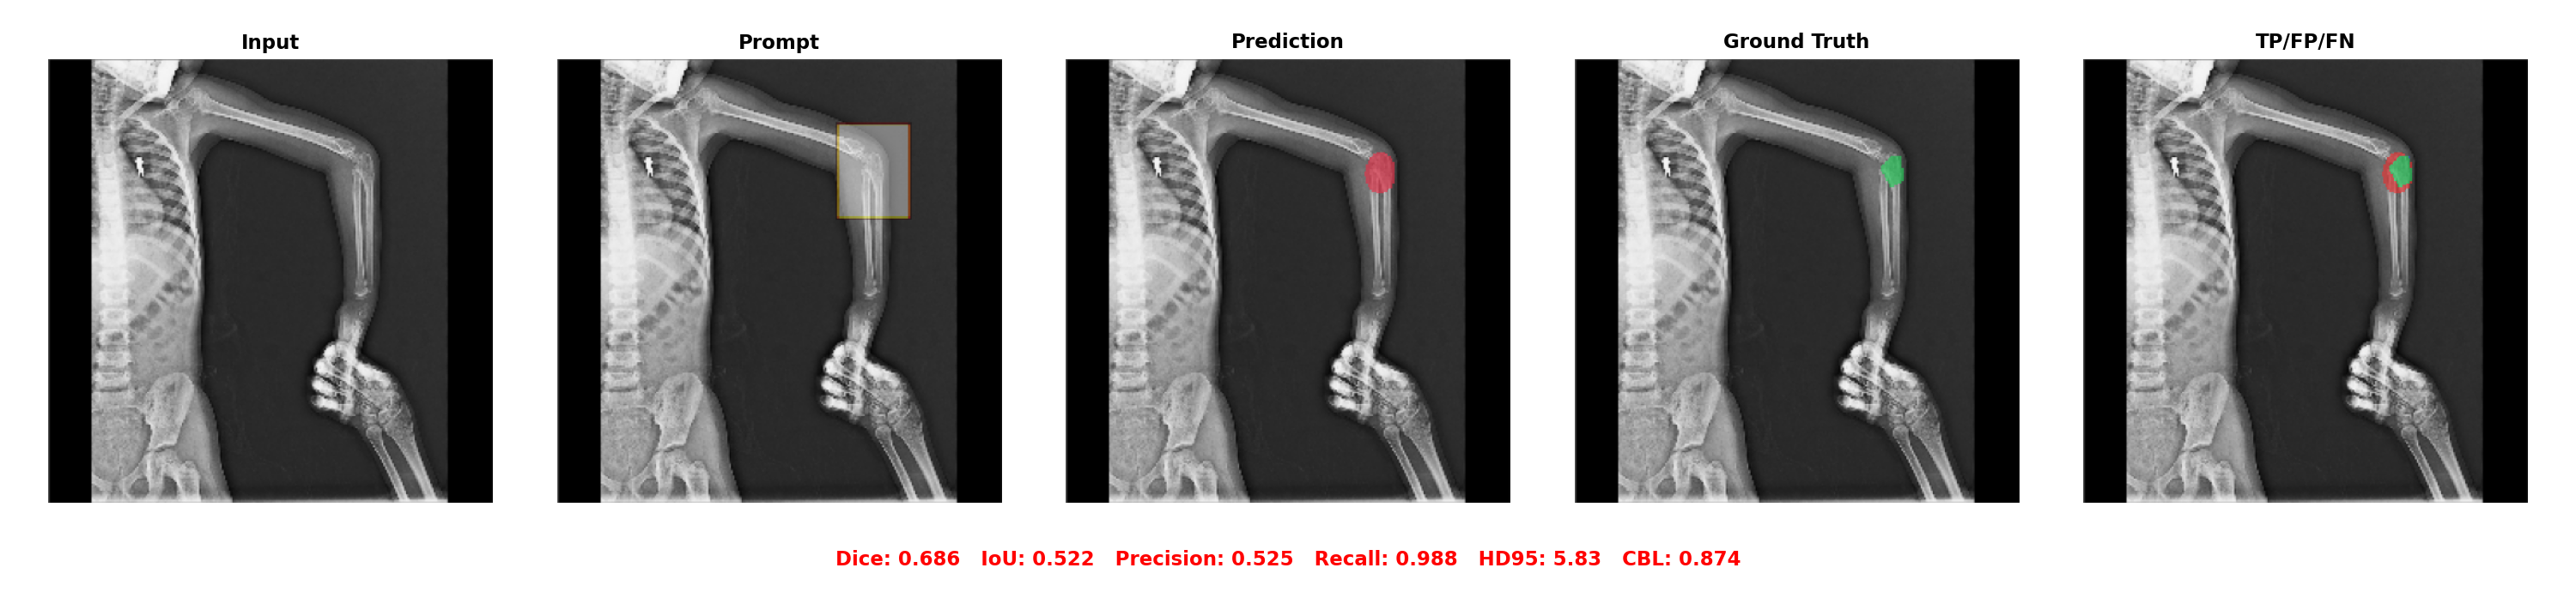

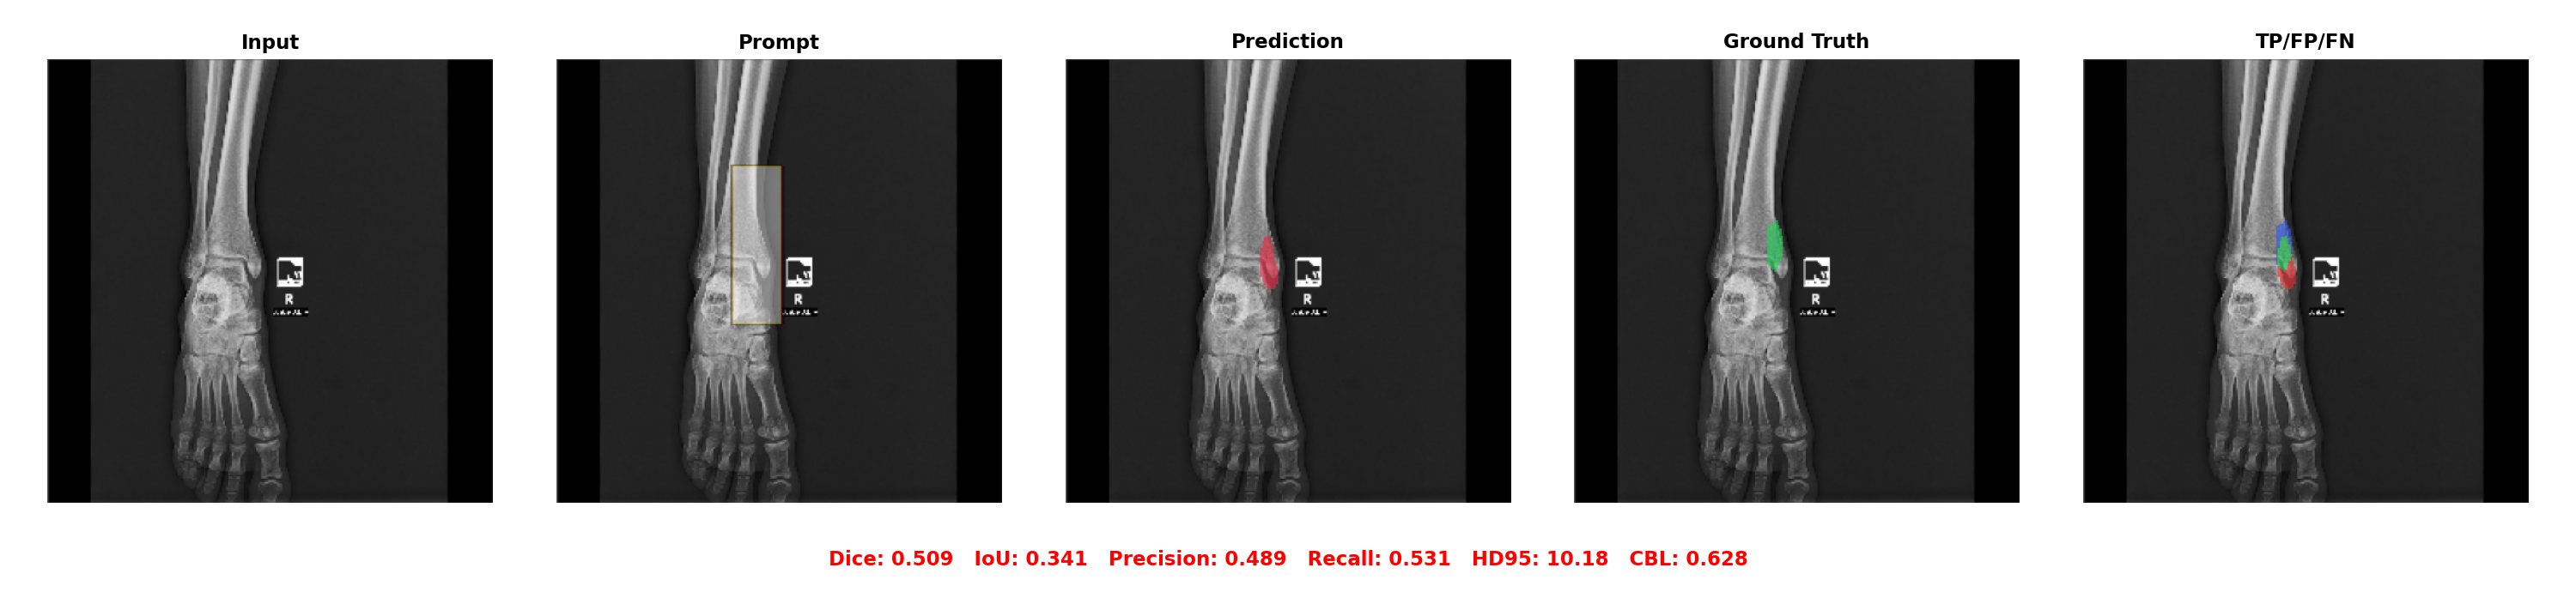

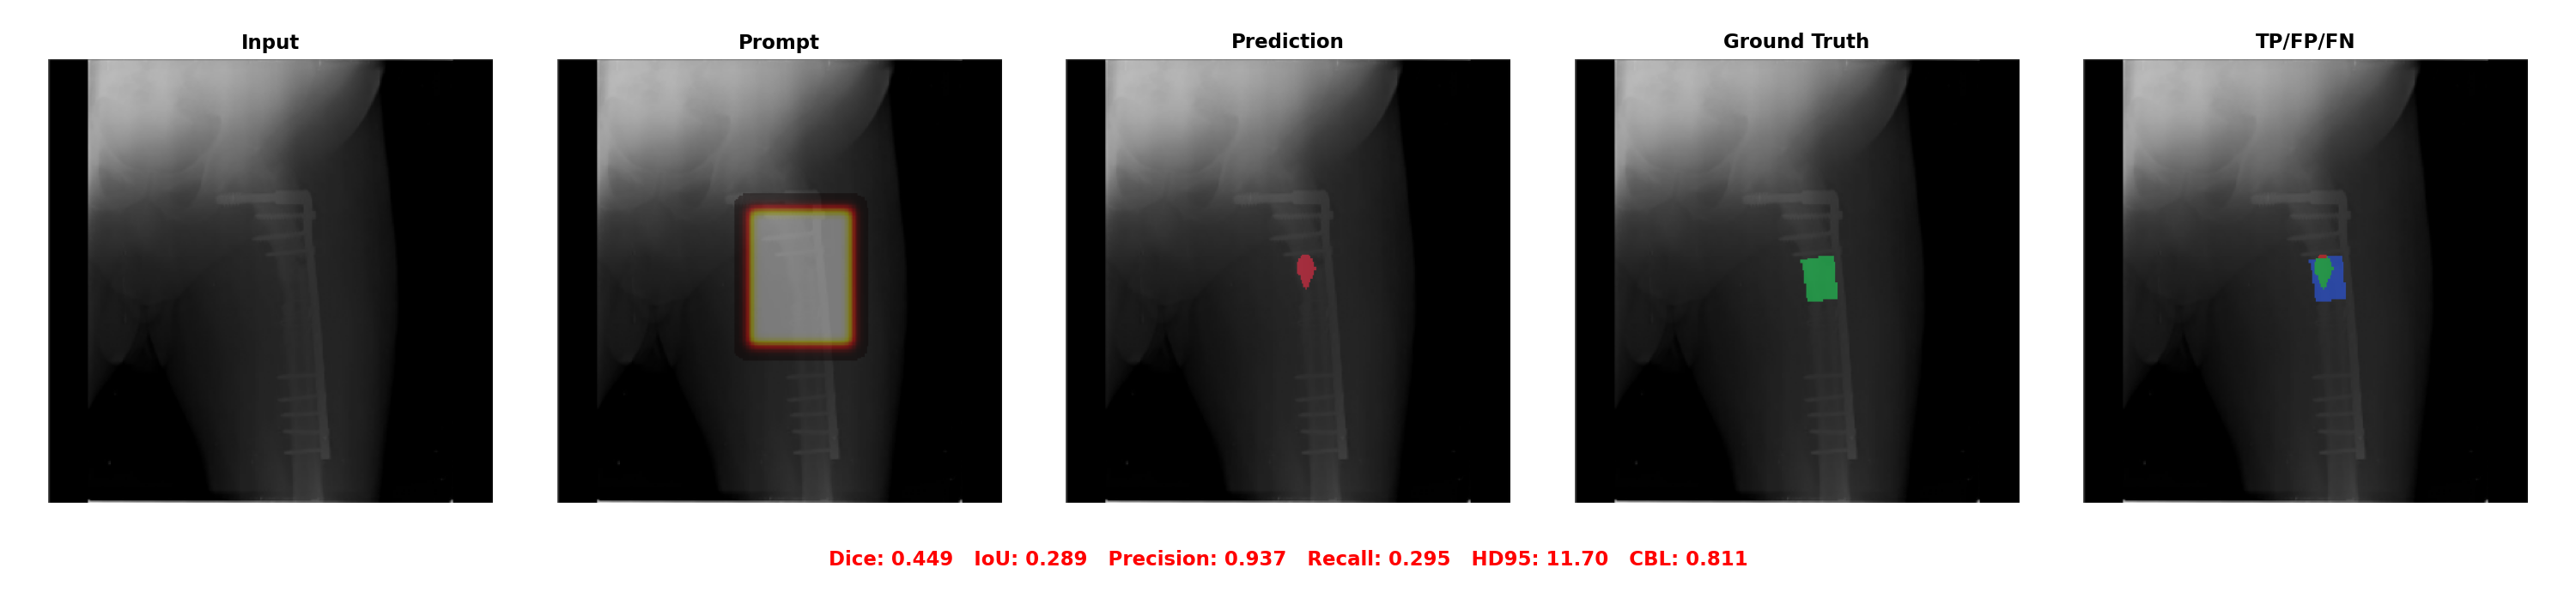

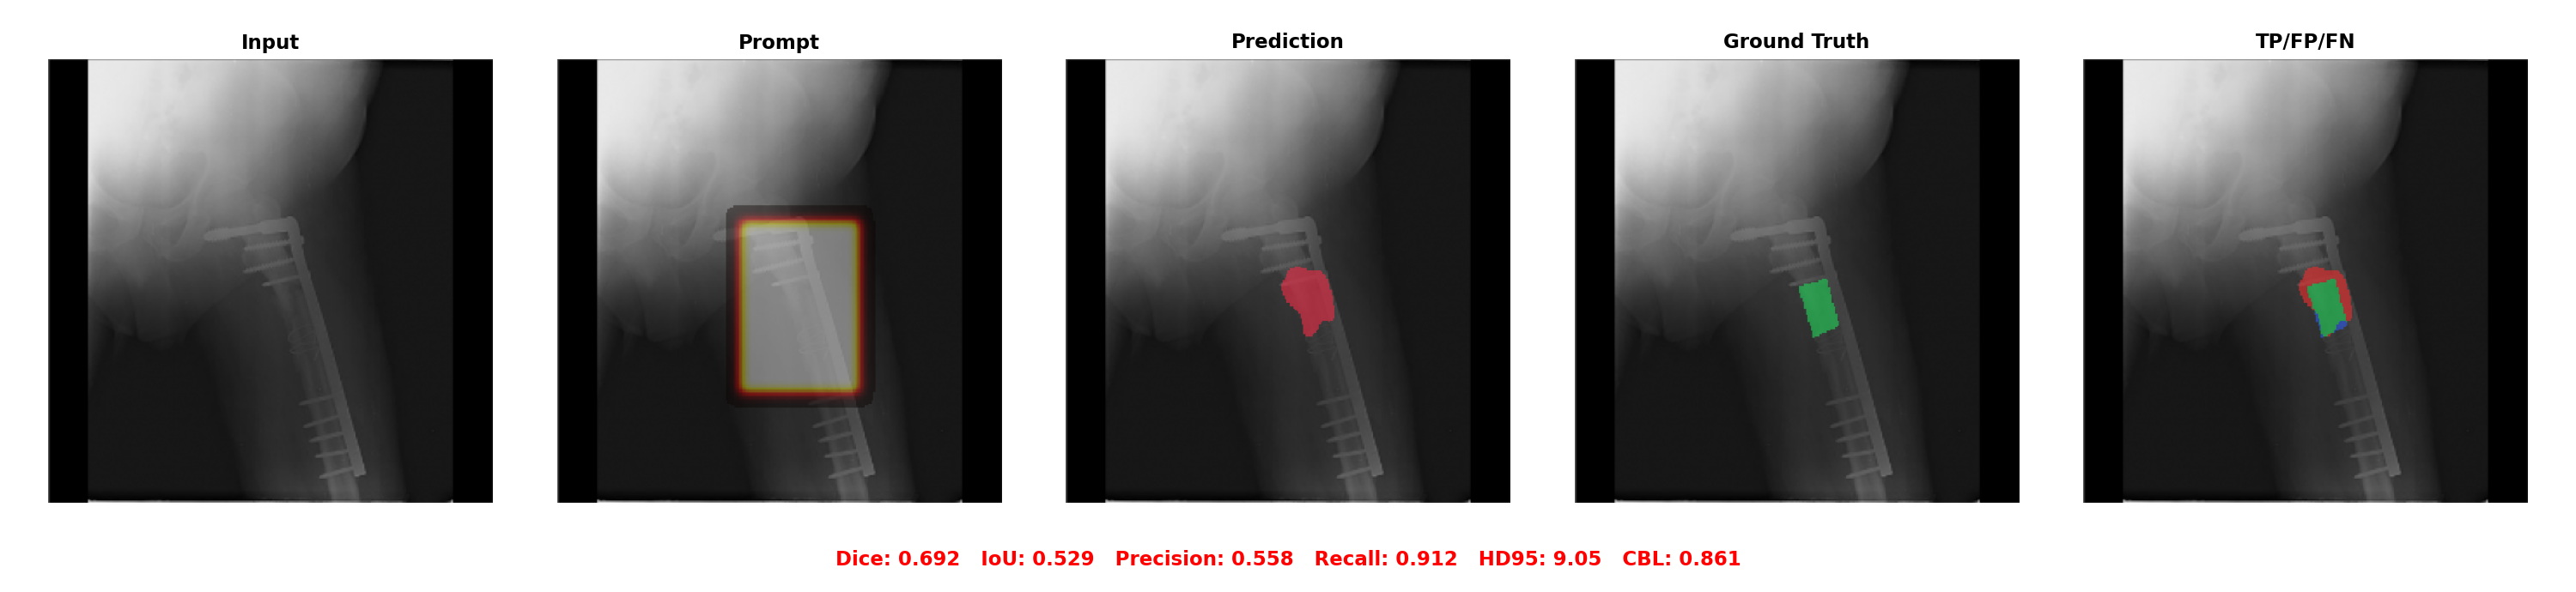

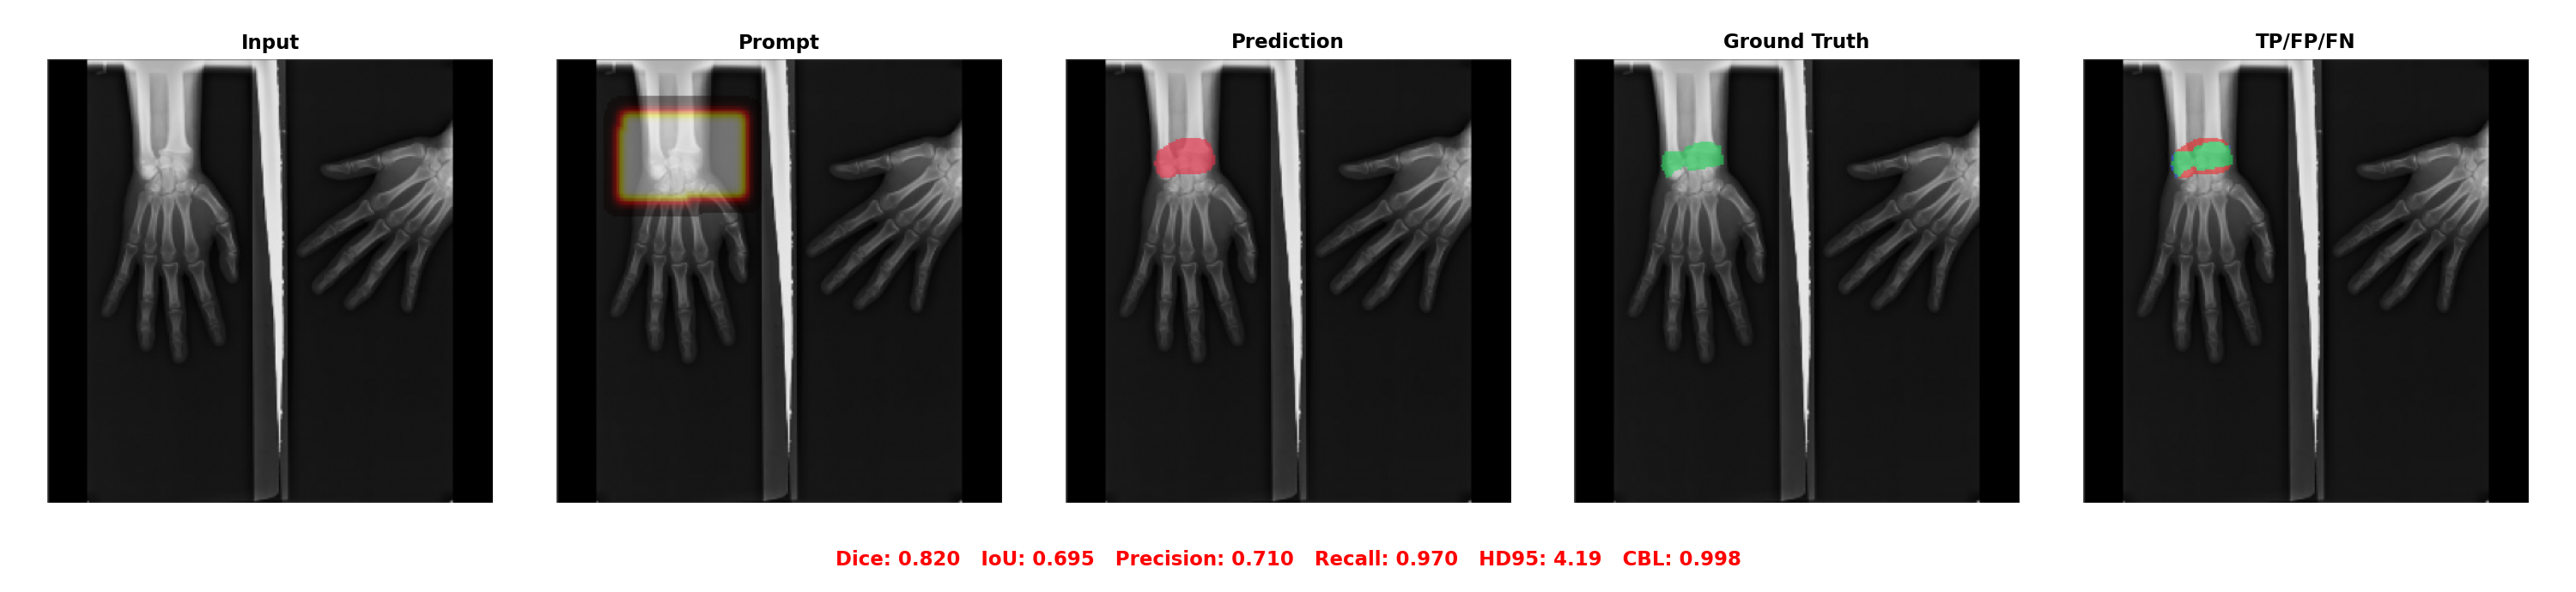

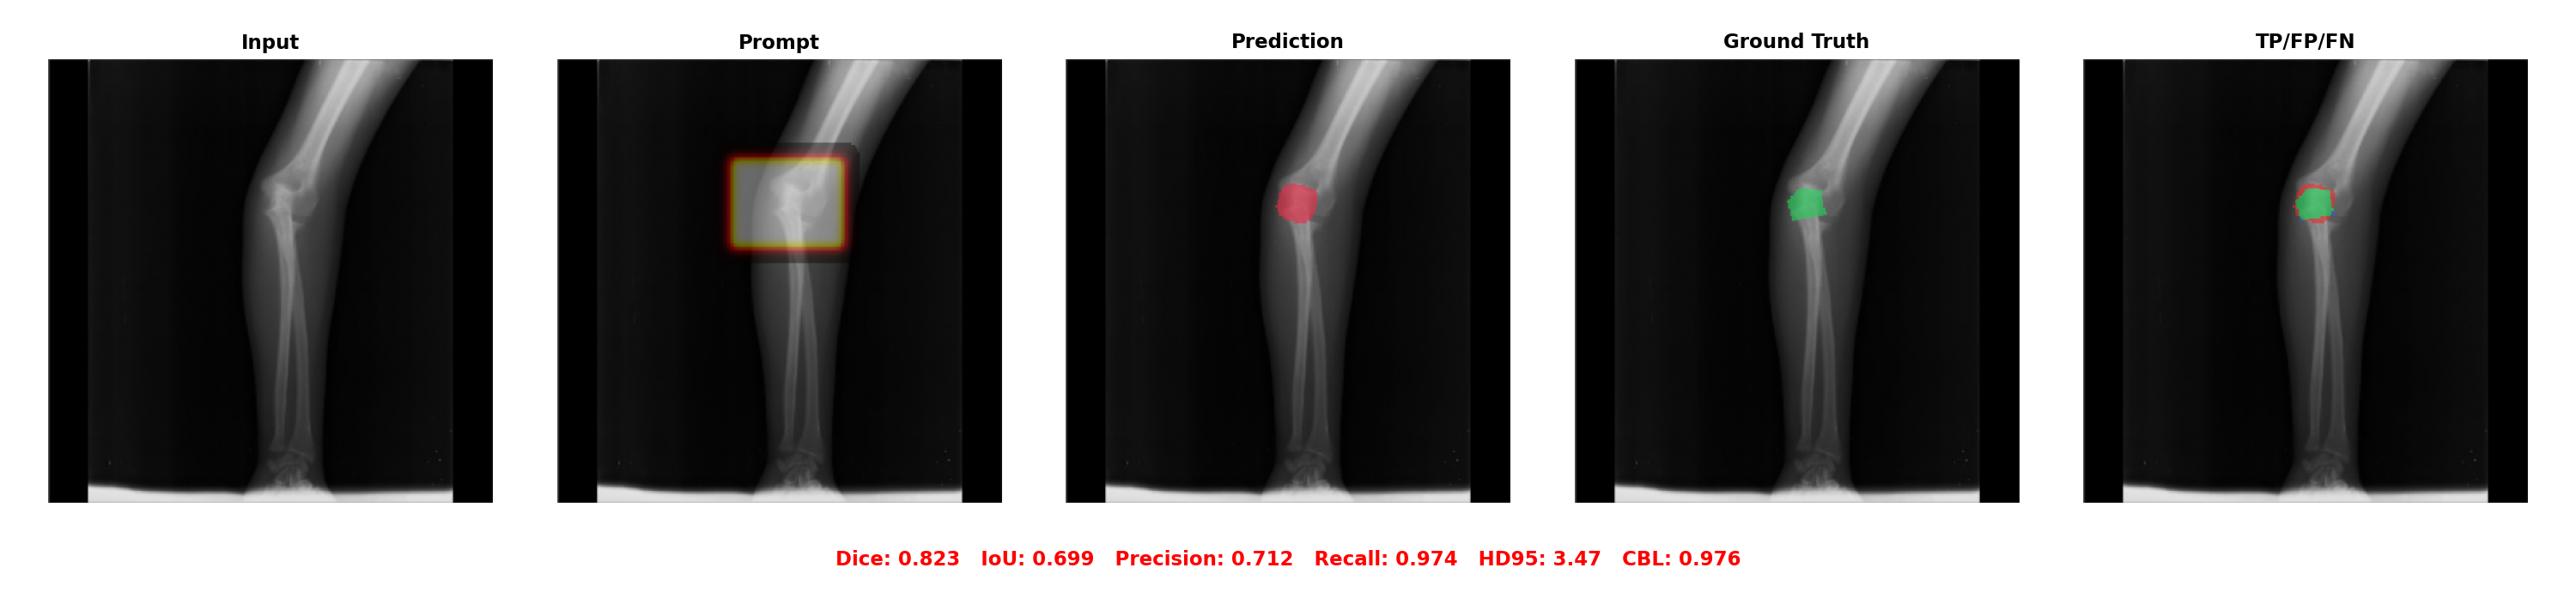

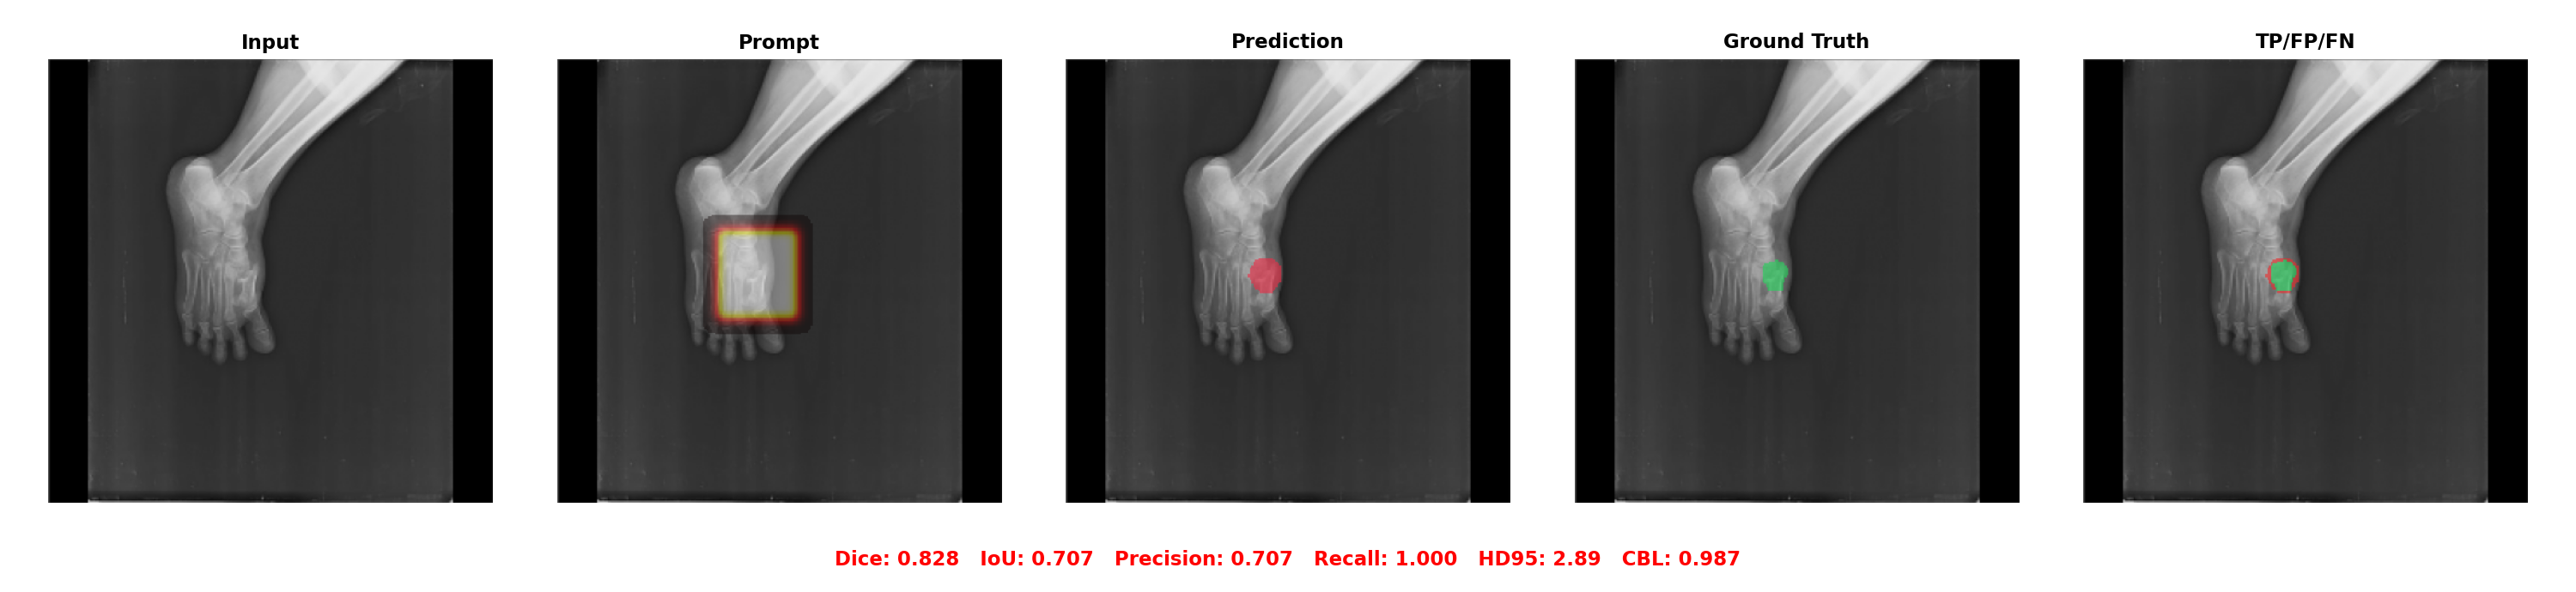

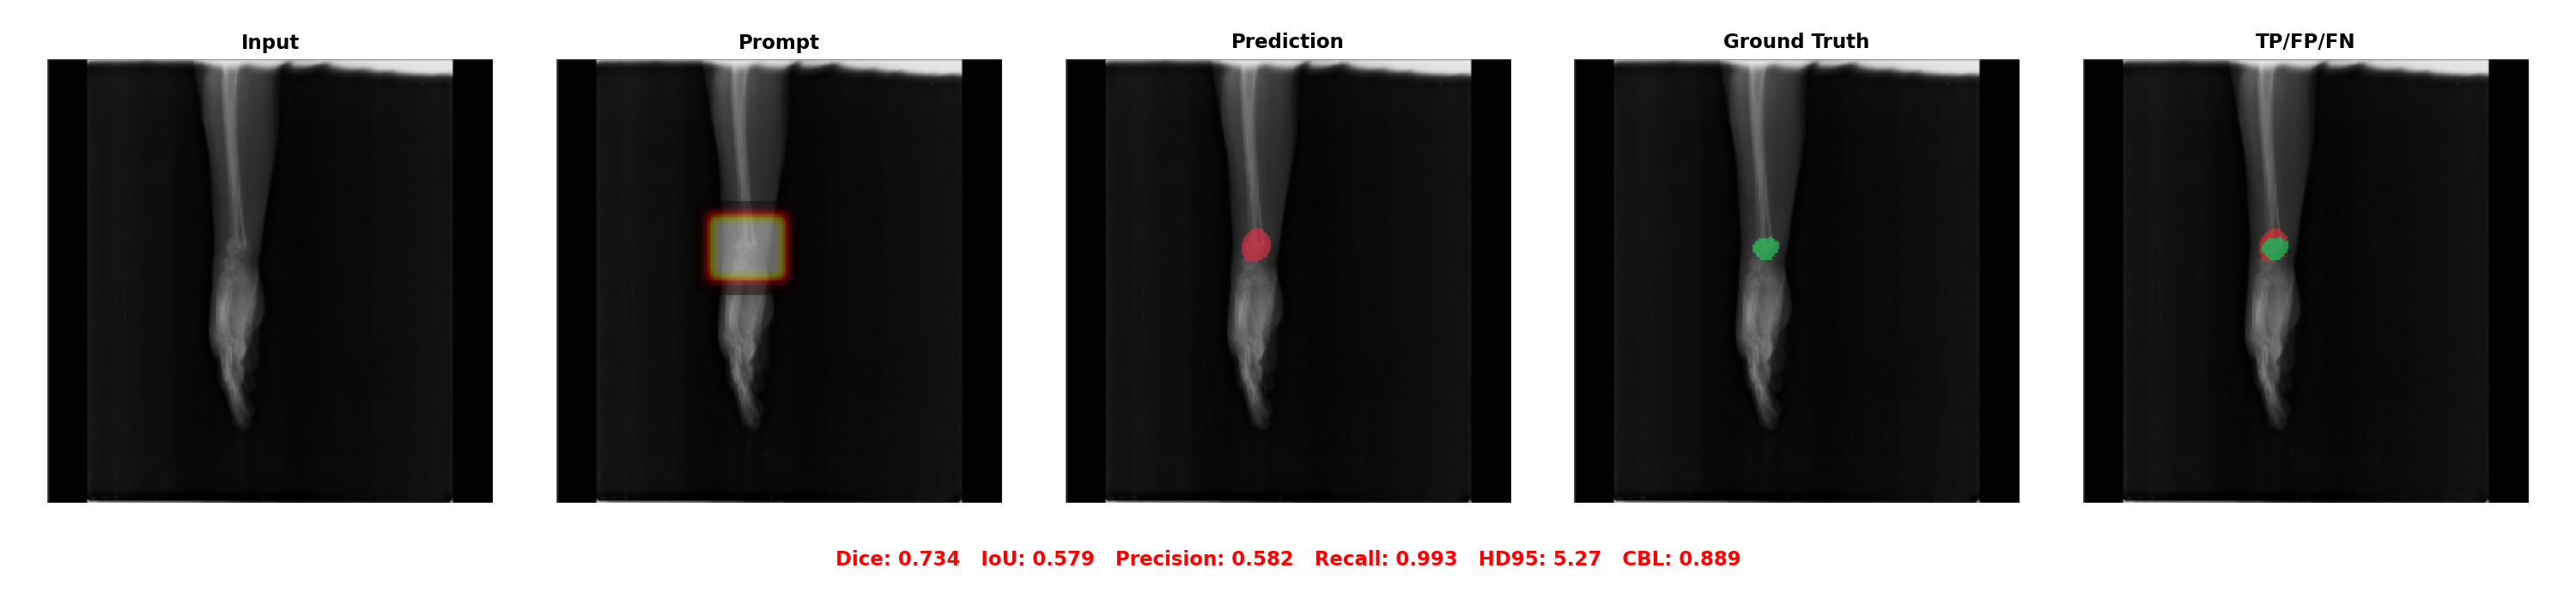

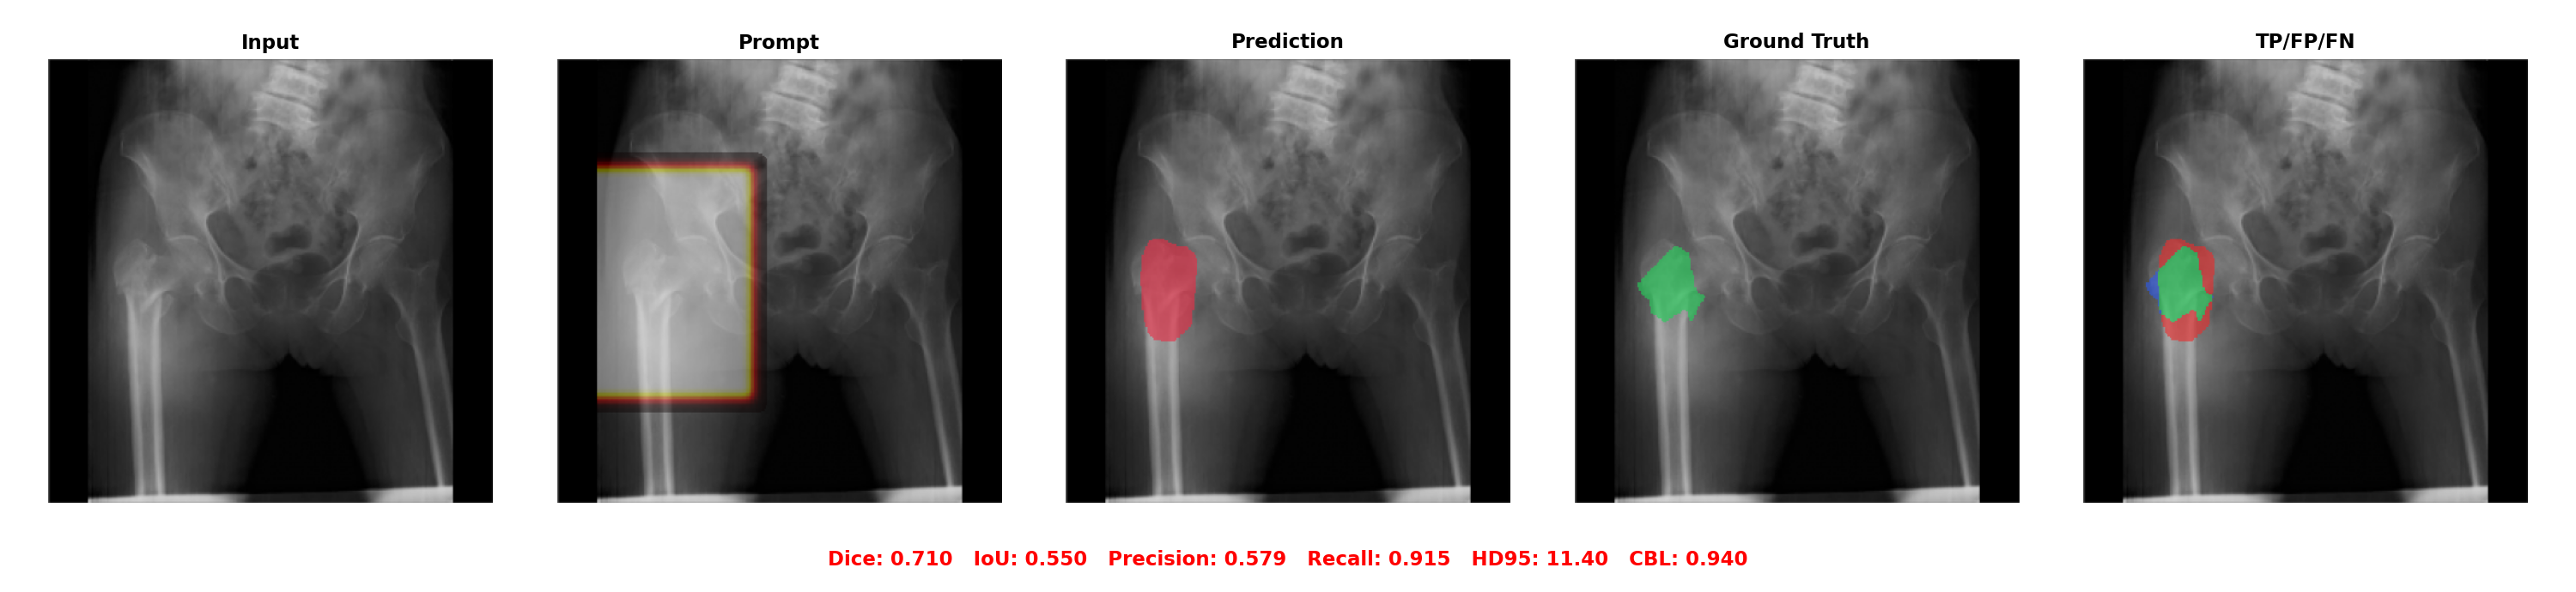

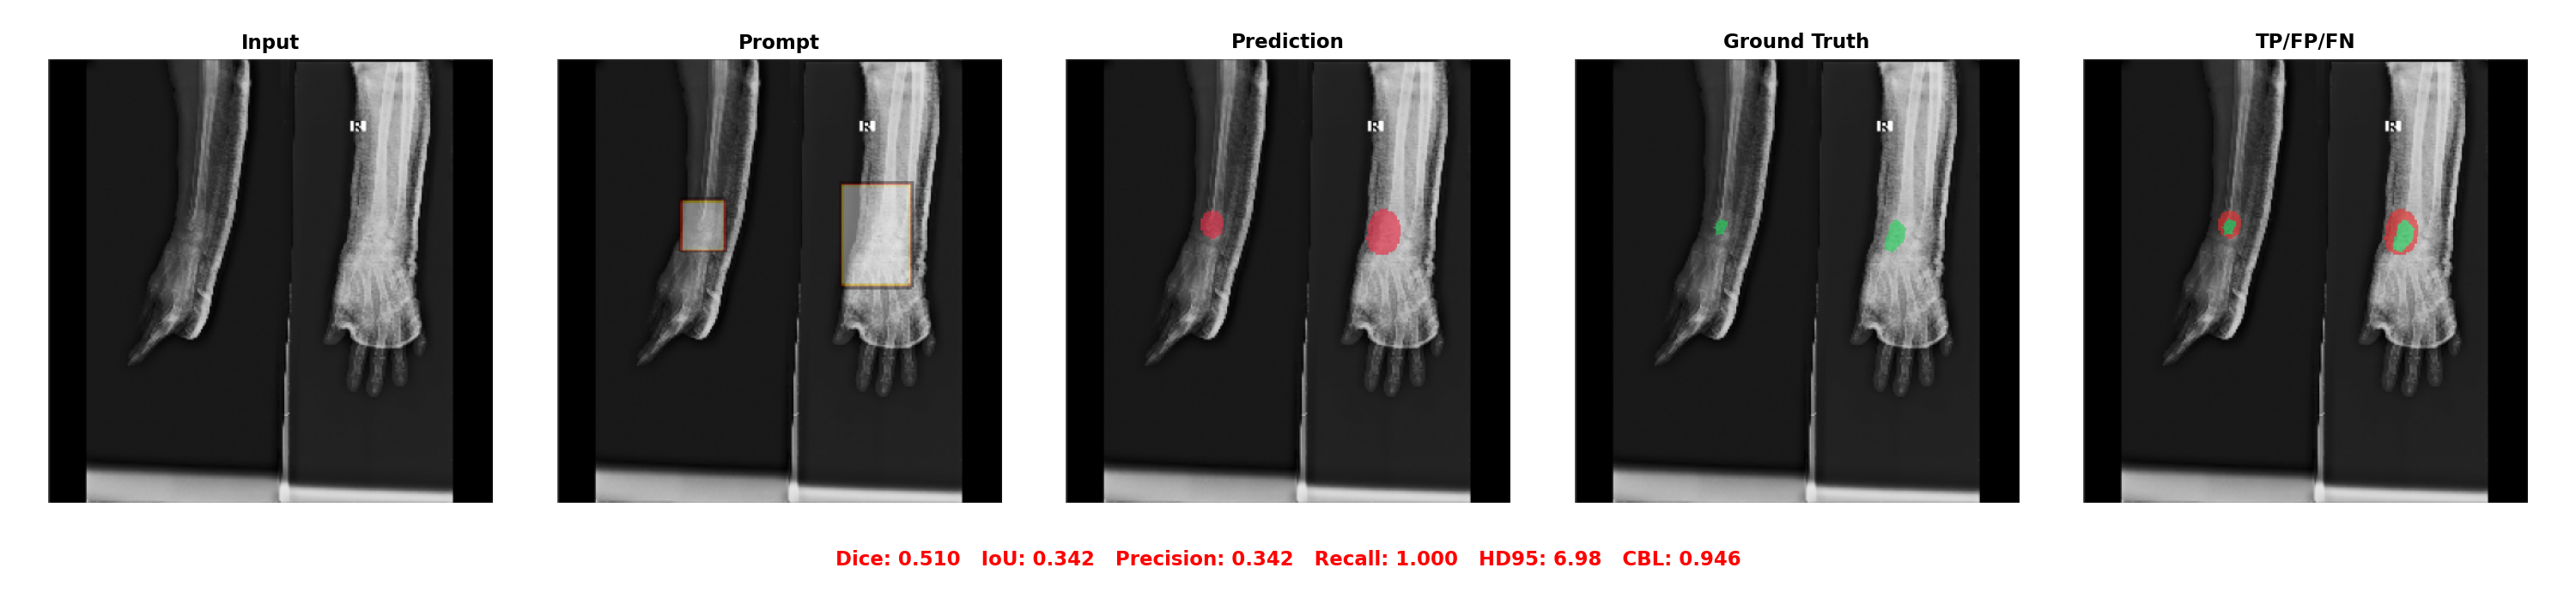

In [3]:
from qualitative_visualization import select_shared_stems, records_for_stems
from qualitative_visualization import export_qualitative_rows
# ── Visualization: balanced test stems (center_zoom, image-level merged) ───
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from IPython.display import display as _ipy_display

assert 'all_image_records' in dir(), '❌ Run the test cell first'
N_MULTI=5
N_SINGLE=5

BALANCED_TEST_STEMS_R256 = select_shared_stems(
    all_image_records['center_zoom'], N_MULTI, N_SINGLE)
print(f'Balanced test stems ({len(BALANCED_TEST_STEMS_R256)}): {BALANCED_TEST_STEMS_R256}')

recs = records_for_stems(all_image_records['center_zoom'], BALANCED_TEST_STEMS_R256, context='qualitative records')
N_SHOW = len(recs)

fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
if N_SHOW == 1:
    axes = axes[np.newaxis, :]
fig.suptitle('PGA-UNet - balanced test images (5 multi-polygon + 5 single-polygon when available)', fontsize=13, y=1.001)

col_titles = ['Input image', 'Image + prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for ax, ct in zip(axes[0], col_titles):
    ax.set_title(ct, fontsize=10, fontweight='bold')

for count, rec in enumerate(recs):
    img_np  = rec['img'] * 0.5 + 0.5
    gt_np   = (rec['gt']   > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    prompt_merged = np.max(np.stack(rec['prompts'], axis=0), axis=0)

    tp = (pred_np * gt_np).sum(); fp = (pred_np * (1-gt_np)).sum()
    fn = ((1-pred_np) * gt_np).sum(); e = 1e-6
    dice = float((2*tp+e)/(2*tp+fp+fn+e)); iou  = float((tp + e) / (tp + fp + fn + e))
    pre  = float(tp / (tp + fp+e));         rec_ = float((tp+e)/(tp+fn+e))
    n    = rec['n_samples']

    row = axes[count]
    bg  = np.stack([img_np]*3, axis=-1)

    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{n} poly]\nDice={dice:.3f}', fontsize=8)

    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[1].imshow(np.where(prompt_merged>0,prompt_merged,np.nan), cmap='hot', alpha=0.4, vmin=0, vmax=1)
    row[1].set_title(rec['img_name'], fontsize=6, pad=2)

    pr_ov = bg.copy()
    pr_ov[..., 0] = np.clip(pr_ov[..., 0] + pred_np * 0.55, 0, 1)
    pr_ov[..., 1] = np.clip(pr_ov[..., 1] - pred_np * 0.2,  0, 1)
    row[2].imshow(pr_ov)
    row[2].set_title(f'Dice={dice:.3f}  IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)

    gt_ov = bg.copy()
    gt_ov[..., 1] = np.clip(gt_ov[..., 1] + gt_np * 0.55, 0, 1)
    gt_ov[..., 0] = np.clip(gt_ov[..., 0] - gt_np * 0.2,  0, 1)
    row[3].imshow(gt_ov)

    inter = bg.copy()
    inter[..., 1] = np.clip(inter[..., 1] + pred_np * gt_np       * 0.9, 0, 1)
    inter[..., 0] = np.clip(inter[..., 0] + pred_np * (1-gt_np)   * 1.0, 0, 1)
    inter[..., 2] = np.clip(inter[..., 2] + (1-pred_np) * gt_np   * 1.0, 0, 1)
    row[4].imshow(inter)
    row[4].set_title(f'Pre={pre:.3f}  Rec={rec_:.3f}', fontsize=7, color='saddlebrown', pad=2)

    for ax in row:
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

fig.legend(
    handles=[Patch(facecolor='green', label='TP'),
             Patch(facecolor='red',   label='FP'),
             Patch(facecolor='blue',  label='FN')],
    loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.005)
)
plt.tight_layout()
export_qualitative_rows(fig, axes, recs)
plt.close(fig)


---
# PART 2 - SAM-Med2D Fine-tuned
---

# SAM-Med2D Fine-tuned - Test Only (Robust Bbox)

Execution order: **Setup → Preparation → (%%writefile) → Test A / B → Results**

In [4]:
%cd /kaggle/working

# ── Install packages ──────────────────────────────────────────────────
!pip install -q albumentations gdown

import os, gdown, cv2, json as _json, numpy as np, glob

# ── Clone SAM-Med2D ───────────────────────────────────────────────
if not os.path.exists('SAM-Med2D'):
    !git clone -q --branch main --single-branch https://github.com/OpenGVLab/SAM-Med2D/

%cd /kaggle/working/SAM-Med2D

# ── Dataset ───────────────────────────────────────────────────────
if not os.path.exists('dataset_FracAtlas'):
    gdown.download('https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv',
                   '/tmp/dataset_FracAtlas.zip', quiet=False)
    !unzip -oq /tmp/dataset_FracAtlas.zip -d /kaggle/working/SAM-Med2D/

# ── Per-polygon masks: JSON annotations -> one PNG per polygon ──
def build_per_polygon_masks(split):
    ann_dir  = f"dataset_FracAtlas/{split}/annotations"
    mask_dir = f"dataset_FracAtlas/{split}/masks"
    img_dir  = f"dataset_FracAtlas/{split}/images"
    if not os.path.exists(ann_dir):
        print(f"[!] {split}: annotations not found, skipping"); return
    for p in glob.glob(os.path.join(mask_dir, "*.png")): os.remove(p)
    n = 0
    for jf in sorted(glob.glob(os.path.join(ann_dir, "*.json"))):
        base = os.path.splitext(os.path.basename(jf))[0]
        img_path = next(
            (os.path.join(img_dir, base + e) for e in ('.png', '.jpg', '.jpeg')
             if os.path.exists(os.path.join(img_dir, base + e))), None)
        if img_path is None: continue
        img  = cv2.imread(img_path)
        H, W = img.shape[:2]
        data = _json.load(open(jf, encoding='utf-8'))
        polys = [s for s in data.get('shapes', []) if s.get('shape_type') == 'polygon']
        for i, shp in enumerate(polys, 1):
            pts  = np.array(shp['points'], dtype=np.float32).reshape(-1, 1, 2).astype(np.int32)
            mask = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(mask, [pts], 255)
            cv2.imwrite(os.path.join(mask_dir, f"{base}_{i}.png"), mask)
            n += 1
    print(f"[✅] {split}: {n} per-polygon masks")

for split in ['train', 'val', 'test']:
    build_per_polygon_masks(split)

# ── Fine-tuned checkpoint ─────────────────────────────────────────
CKPT_ID    = '1hVkf2OIf1s4M9ojpZ-Ra_6KrTlBdoNLW'
CKPT_LOCAL = '/kaggle/working/SAM-Med2D/checkpoint/best_sam.pth'
os.makedirs(os.path.dirname(CKPT_LOCAL), exist_ok=True)
if not os.path.exists(CKPT_LOCAL):
    gdown.download(f'https://drive.google.com/uc?id={CKPT_ID}', CKPT_LOCAL, quiet=False)
assert os.path.exists(CKPT_LOCAL), '❌ Checkpoint download failed'
print(f'\n✅ Setup complete | {CKPT_LOCAL}  ({os.path.getsize(CKPT_LOCAL)//1024//1024} MB)')

/kaggle/working
/kaggle/working/SAM-Med2D


Downloading...
From (original): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv
From (redirected): https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv&confirm=t&uuid=e05d94e8-a981-4414-8300-86c6eea886e6
To: /tmp/dataset_FracAtlas.zip
100%|██████████| 231M/231M [00:03<00:00, 58.3MB/s]


[✅] train: 730 per-polygon masks
[✅] val: 95 per-polygon masks
[✅] test: 92 per-polygon masks


Downloading...
From (original): https://drive.google.com/uc?id=1hVkf2OIf1s4M9ojpZ-Ra_6KrTlBdoNLW
From (redirected): https://drive.google.com/uc?id=1hVkf2OIf1s4M9ojpZ-Ra_6KrTlBdoNLW&confirm=t&uuid=5b6c4b93-c8d2-498d-88bc-79a806cf1582
To: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
100%|██████████| 2.56G/2.56G [00:41<00:00, 61.2MB/s]


✅ Setup complete | /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth  (2443 MB)


## Part 2: Evaluation Experiment

Two prompt-box scenarios (matching the PGA `center_zoom`/`center_shift` test protocol, `scale_factor=3.0`, `shift_ratio=0.5`):
- **A: Center-Zoom**: tight GT box scaled outward from its own center by `scale_factor=3.0`
- **B: Center-Shift**: `center_zoom` plus a fixed, reproducible off-center offset that still fully covers the ground truth

### 2.0: Preparation (run once before testing)

In [5]:
%cd /kaggle/working/SAM-Med2D
import os, json, glob, gdown

# ── Create label2image_test.json & label2image_val.json ─────────────
def create_evaluation_json(split="test"):
    mask_dir = f"dataset_FracAtlas/{split}/masks"
    img_dir  = f"dataset_FracAtlas/{split}/images"
    label2image = {}
    if not os.path.exists(mask_dir) or not os.path.exists(img_dir):
        print(f"[!] Directory not found for split: '{split}'"); return
    img_dict = {}
    for f in os.listdir(img_dir):
        if f.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_dict[os.path.splitext(f)[0]] = f
    for mask_name in sorted(os.listdir(mask_dir)):
        if not mask_name.lower().endswith(('.png', '.jpg', '.jpeg')): continue
        mask_base = os.path.splitext(mask_name)[0]
        img_base  = mask_base.rsplit('_', 1)[0] if '_' in mask_base else mask_base
        if img_base in img_dict:
            label2image[f"dataset_FracAtlas/{split}/masks/{mask_name}"] = \
                        f"dataset_FracAtlas/{split}/images/{img_dict[img_base]}"
    out = f"dataset_FracAtlas/label2image_{split}.json"
    with open(out, "w", encoding="utf-8") as fo:
        json.dump(label2image, fo, indent=4, ensure_ascii=False)
    print(f"[*] label2image_{split}.json - {len(label2image)} samples -> {out}")

create_evaluation_json("test")
create_evaluation_json("val")

# ── Load the checkpoint (Drive mount -> checkpoint/ -> workdir -> download fallback) ───────────
CKPT_DRIVE_ID = '1hVkf2OIf1s4M9ojpZ-Ra_6KrTlBdoNLW'
CKPT_LOCAL    = '/kaggle/working/SAM-Med2D/checkpoint/best_sam.pth'

def find_ckpt(folder):
    for name in ["best_sam.pth", "last_sam.pth"]:
        p = os.path.join(folder, name)
        if os.path.exists(p): return p
    return None

FT_CHECKPOINT = (find_ckpt("/kaggle/working/drive/MyDrive/model") or
              find_ckpt("/kaggle/working/SAM-Med2D/checkpoint") or
              find_ckpt("/kaggle/working/SAM-Med2D/workdir/models/sam-med2d"))

if FT_CHECKPOINT:
    src = "Drive-mount" if "MyDrive" in FT_CHECKPOINT else "Local"
    print(f"[{src}] ✅ {FT_CHECKPOINT}")
else:
    print("[Download] Downloading the fine-tuned checkpoint from Google Drive...")
    os.makedirs(os.path.dirname(CKPT_LOCAL), exist_ok=True)
    gdown.download(f'https://drive.google.com/uc?id={CKPT_DRIVE_ID}', CKPT_LOCAL, quiet=False)
    FT_CHECKPOINT = CKPT_LOCAL

assert os.path.exists(FT_CHECKPOINT), "❌ Checkpoint does not exist!"
print(f"\n✅ Checkpoint: {FT_CHECKPOINT}  ({os.path.getsize(FT_CHECKPOINT)//1024//1024} MB)")

/kaggle/working/SAM-Med2D
[*] label2image_test.json - 92 samples -> dataset_FracAtlas/label2image_test.json
[*] label2image_val.json - 95 samples -> dataset_FracAtlas/label2image_val.json
[Local] ✅ /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth

✅ Checkpoint: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth  (2443 MB)


In [6]:
%%writefile /kaggle/working/SAM-Med2D/segment_anything/build_sam.py
# Copyright (c) Meta Platforms, Inc. and affiliates.
# All rights reserved.

import torch
from functools import partial
from .modeling import ImageEncoderViT, MaskDecoder, PromptEncoder, Sam, TwoWayTransformer
from torch.nn import functional as F

def build_sam_vit_h(args):
    return _build_sam(
        encoder_embed_dim=1280,
        encoder_depth=32,
        encoder_num_heads=16,
        encoder_global_attn_indexes=[7, 15, 23, 31],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

build_sam = build_sam_vit_h

def build_sam_vit_l(args):
    return _build_sam(
        encoder_embed_dim=1024,
        encoder_depth=24,
        encoder_num_heads=16,
        encoder_global_attn_indexes=[5, 11, 17, 23],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

def build_sam_vit_b(args):
    return _build_sam(
        encoder_embed_dim=768,
        encoder_depth=12,
        encoder_num_heads=12,
        encoder_global_attn_indexes=[2, 5, 8, 11],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter=args.encoder_adapter,
    )

sam_model_registry = {
    "default": build_sam_vit_h,
    "vit_h":   build_sam_vit_h,
    "vit_l":   build_sam_vit_l,
    "vit_b":   build_sam_vit_b,
}

def _build_sam(encoder_embed_dim, encoder_depth, encoder_num_heads,
               encoder_global_attn_indexes, image_size, checkpoint, encoder_adapter):
    prompt_embed_dim = 256
    vit_patch_size   = 16
    image_embedding_size = image_size // vit_patch_size
    sam = Sam(
        image_encoder=ImageEncoderViT(
            depth=encoder_depth,
            embed_dim=encoder_embed_dim,
            img_size=image_size,
            mlp_ratio=4,
            norm_layer=partial(torch.nn.LayerNorm, eps=1e-6),
            num_heads=encoder_num_heads,
            patch_size=vit_patch_size,
            qkv_bias=True,
            use_rel_pos=True,
            global_attn_indexes=encoder_global_attn_indexes,
            window_size=14,
            out_chans=prompt_embed_dim,
            adapter_train=encoder_adapter,
        ),
        prompt_encoder=PromptEncoder(
            embed_dim=prompt_embed_dim,
            image_embedding_size=(image_embedding_size, image_embedding_size),
            input_image_size=(image_size, image_size),
            mask_in_chans=16,
        ),
        mask_decoder=MaskDecoder(
            num_multimask_outputs=3,
            transformer=TwoWayTransformer(
                depth=2,
                embedding_dim=prompt_embed_dim,
                mlp_dim=2048,
                num_heads=8,
            ),
            transformer_dim=prompt_embed_dim,
            iou_head_depth=3,
            iou_head_hidden_dim=256,
        ),
        pixel_mean=[123.675, 116.28, 103.53],
        pixel_std=[58.395, 57.12, 57.375],
    )
    if checkpoint is not None:
        with open(checkpoint, "rb") as f:
            state_dict = torch.load(f, map_location="cpu", weights_only=False)
        try:
            if 'model' in state_dict:
                print(encoder_adapter)
                sam.load_state_dict(state_dict['model'], strict=False)
            else:
                if image_size == 1024 and encoder_adapter:
                    sam.load_state_dict(state_dict, strict=False)
                else:
                    sam.load_state_dict(state_dict)
        except Exception:
            print('**** interpolate pos embed')
            new_state_dict = load_from(sam, state_dict, image_size, vit_patch_size)
            sam.load_state_dict(new_state_dict)
        print(f"**** loaded {checkpoint}")
    return sam

def load_from(sam, state_dicts, image_size, vit_patch_size):
    sam_dict    = sam.state_dict()
    skip_keys   = ['mask_tokens', 'output_hypernetworks_mlps', 'iou_prediction_head']
    new_sd      = {k: v for k, v in state_dicts.items()
                   if k in sam_dict and not any(s in k for s in skip_keys)}
    pos_embed   = new_sd.get('image_encoder.pos_embed')
    token_size  = image_size // vit_patch_size
    if pos_embed is not None and pos_embed.shape[1] != token_size:
        pos_embed = F.interpolate(
            pos_embed.permute(0,3,1,2), (token_size, token_size),
            mode='bilinear', align_corners=False).permute(0,2,3,1)
        new_sd['image_encoder.pos_embed'] = pos_embed
        for k in [k for k in sam_dict if 'rel_pos' in k and
                  any(t in k for t in ['2','5','7','8','11','13','15','23','31'])]:
            rp = new_sd.get(k)
            if rp is not None:
                h_c, w_c = sam_dict[k].shape
                if rp.shape != (h_c, w_c):
                    rp = F.interpolate(rp.unsqueeze(0).unsqueeze(0),
                                       (h_c, w_c), mode='bilinear', align_corners=False)[0,0]
                new_sd[k] = rp
    sam_dict.update(new_sd)
    return sam_dict

Overwriting /kaggle/working/SAM-Med2D/segment_anything/build_sam.py


In [7]:
%%writefile /kaggle/working/SAM-Med2D/DataLoader.py
import os, json, random
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset
from torch.nn import functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from utils import train_transforms, get_boxes_from_mask, init_point_sampling


class TestingDataset(Dataset):
    def __init__(self, data_path, image_size=256, mode='test', requires_name=True,
                 point_num=1, return_ori_mask=True, prompt_path=None,
                 prompt_mode='center_shift', shift_ratio=0.5, scale_factor=3.0):
        self.image_size    = image_size
        self.return_ori_mask = return_ori_mask
        self.prompt_path   = prompt_path
        self.prompt_list   = {} if prompt_path is None else json.load(open(prompt_path))
        self.requires_name = requires_name
        self.point_num     = point_num
        self.mode          = mode
        self.is_train      = (mode == 'train')
        self.prompt_mode   = prompt_mode
        self.shift_ratio   = shift_ratio
        # How many times larger than the tight GT box the covering box is,
        # measured from the GT center. Mirrors dataset.py's scale_factor.
        self.scale_factor  = scale_factor

        dataset = json.load(open(os.path.join(data_path, f'label2image_{mode}.json')))
        sorted_items       = sorted(dataset.items(), key=lambda x: os.path.basename(x[0]))
        self.label_paths   = [k for k, v in sorted_items]
        self.image_paths   = [v for k, v in sorted_items]
        self.pixel_mean    = [123.675, 116.28, 103.53]
        self.pixel_std     = [58.395, 57.12, 57.375]

    def _center_zoom_bbox(self, x_min, x_max, y_min, y_max, orig_h, orig_w):
        """Scale the tight GT box outward from its own center by a fixed
        scale_factor (all four sides together). No randomness (train and
        test use the same formula). Mirrors
        PromptSegmentationDataset._center_zoom_bbox in dataset.py exactly."""
        cx = (x_min + x_max) / 2.0
        cy = (y_min + y_max) / 2.0
        half_w = (x_max - x_min) / 2.0 * self.scale_factor
        half_h = (y_max - y_min) / 2.0 * self.scale_factor
        bx_min = max(0,       cx - half_w)
        bx_max = min(orig_w,  cx + half_w)
        by_min = max(0,       cy - half_h)
        by_max = min(orig_h,  cy + half_h)
        return bx_min, bx_max, by_min, by_max

    def _center_shift_bbox(self, x_min, x_max, y_min, y_max, orig_h, orig_w, seed_idx=None):
        """Displaces _center_zoom_bbox off-center: train picks a random
        offset each sample, test uses a fixed, reproducible offset per
        sample (seeded by seed_idx). Mirrors dataset.py's
        _center_shift_bbox exactly."""
        gt_w, gt_h = x_max - x_min, y_max - y_min
        bx_min, bx_max, by_min, by_max = self._center_zoom_bbox(
            x_min, x_max, y_min, y_max, orig_h, orig_w)
        if self.is_train:
            dx = random.uniform(-gt_w * self.shift_ratio, gt_w * self.shift_ratio)
            dy = random.uniform(-gt_h * self.shift_ratio, gt_h * self.shift_ratio)
        else:
            rng = random.Random(seed_idx or 0)
            dx = rng.uniform(gt_w * 0.4, gt_w * 0.7) * self.shift_ratio
            dy = rng.uniform(gt_h * 0.1, gt_h * 0.3) * self.shift_ratio
        bx_min = max(0,       bx_min + dx)
        bx_max = min(orig_w,  bx_max + dx)
        by_min = max(0,       by_min + dy)
        by_max = min(orig_h,  by_max + dy)
        # Shift must still cover the full GT, only changing its relative position inside the box.
        box_w = bx_max - bx_min
        box_h = by_max - by_min
        bx_min = min(bx_min, x_min)
        by_min = min(by_min, y_min)
        bx_max = max(bx_max, x_max)
        by_max = max(by_max, y_max)
        if bx_max - bx_min < box_w:
            if bx_min <= 0:
                bx_max = min(orig_w, bx_min + box_w)
            elif bx_max >= orig_w:
                bx_min = max(0, bx_max - box_w)
        if by_max - by_min < box_h:
            if by_min <= 0:
                by_max = min(orig_h, by_min + box_h)
            elif by_max >= orig_h:
                by_min = max(0, by_max - box_h)
        return bx_min, bx_max, by_min, by_max

    def __getitem__(self, index):
        image = cv2.imread(self.image_paths[index])
        image = (image - self.pixel_mean) / self.pixel_std

        mask_path  = self.label_paths[index]
        ori_np_mask = cv2.imread(mask_path, 0)
        if ori_np_mask.max() == 255:
            ori_np_mask = ori_np_mask / 255
        assert np.array_equal(ori_np_mask, ori_np_mask.astype(bool)), \
            f"Mask must be binary. {mask_path}"

        h, w = ori_np_mask.shape
        ori_mask = torch.tensor(ori_np_mask).unsqueeze(0)

        transforms = train_transforms(self.image_size, h, w)
        aug   = transforms(image=image, mask=ori_np_mask)
        image, mask = aug['image'], aug['mask'].to(torch.int64)

        if self.prompt_path is None:
            y_idx, x_idx = torch.where(mask > 0)
            if len(y_idx) > 0:
                y_min, y_max = y_idx.min().item(), y_idx.max().item()
                x_min, x_max = x_idx.min().item(), x_idx.max().item()
            else:
                x_min, x_max, y_min, y_max = 0, self.image_size, 0, self.image_size
            S = self.image_size
            if self.prompt_mode == 'center_zoom':
                bx0, bx1, by0, by1 = self._center_zoom_bbox(x_min, x_max, y_min, y_max, S, S)
            elif self.prompt_mode == 'center_shift':
                bx0, bx1, by0, by1 = self._center_shift_bbox(x_min, x_max, y_min, y_max, S, S, index)
            else:
                bx0, bx1, by0, by1 = x_min, x_max, y_min, y_max
            boxes = torch.tensor([[bx0, by0, bx1, by1]], dtype=torch.float)
            point_coords, point_labels = init_point_sampling(mask, self.point_num)
        else:
            key          = mask_path.split('/')[-1]
            boxes        = torch.as_tensor(self.prompt_list[key]["boxes"], dtype=torch.float)
            point_coords = torch.as_tensor(self.prompt_list[key]["point_coords"], dtype=torch.float)
            point_labels = torch.as_tensor(self.prompt_list[key]["point_labels"], dtype=torch.int)

        image_input = {
            "image":         image,
            "label":         mask.unsqueeze(0),
            "point_coords":  point_coords,
            "point_labels":  point_labels,
            "boxes":         boxes,
            "original_size": (h, w),
            "label_path":    '/'.join(mask_path.split('/')[:-1]),
        }
        if self.return_ori_mask:
            image_input["ori_label"] = ori_mask
        if self.requires_name:
            image_input["name"] = self.label_paths[index].split('/')[-1]
        return image_input

    def __len__(self):
        return len(self.label_paths)


class TrainingDataset(Dataset):
    def __init__(self, data_dir, image_size=256, mode='train', requires_name=True,
                 point_num=1, mask_num=5, zoom_ratio=(0.15, 0.45), shift_ratio=0.30):
        self.image_size    = image_size
        self.requires_name = requires_name
        self.point_num     = point_num
        self.mask_num      = mask_num
        self.zoom_ratio    = zoom_ratio
        self.shift_ratio   = shift_ratio
        self.pixel_mean    = [123.675, 116.28, 103.53]
        self.pixel_std     = [58.395, 57.12, 57.375]
        dataset = json.load(open(os.path.join(data_dir, f'image2label_{mode}.json')))
        self.image_paths = list(dataset.keys())
        self.label_paths = list(dataset.values())

    def _noisy_box(self, mask_tensor):
        y_idx, x_idx = torch.where(mask_tensor > 0)
        if len(y_idx) == 0:
            return torch.zeros(1, 4, dtype=torch.float)
        x0, x1 = int(x_idx.min()), int(x_idx.max())
        y0, y1 = int(y_idx.min()), int(y_idx.max())
        S  = self.image_size
        lo, hi = self.zoom_ratio
        gw, gh = x1 - x0, y1 - y0
        bx0 = max(0, x0 - gw * random.uniform(lo, hi))
        bx1 = min(S, x1 + gw * random.uniform(lo, hi))
        by0 = max(0, y0 - gh * random.uniform(lo, hi))
        by1 = min(S, y1 + gh * random.uniform(lo, hi))
        return torch.tensor([[bx0, by0, bx1, by1]], dtype=torch.float)

    def __getitem__(self, index):
        image  = cv2.imread(self.image_paths[index])
        image  = (image - self.pixel_mean) / self.pixel_std
        h, w, _ = image.shape
        transforms = train_transforms(self.image_size, h, w)
        masks_list, boxes_list, pc_list, pl_list = [], [], [], []
        for m_path in random.choices(self.label_paths[index], k=self.mask_num):
            pre_mask = cv2.imread(m_path, 0)
            if pre_mask.max() == 255: pre_mask = pre_mask / 255
            aug = transforms(image=image, mask=pre_mask)
            img_t, mask_t = aug['image'], aug['mask'].to(torch.int64)
            boxes = self._noisy_box(mask_t)
            pc, pl = init_point_sampling(mask_t, self.point_num)
            masks_list.append(mask_t); boxes_list.append(boxes)
            pc_list.append(pc);        pl_list.append(pl)
        image_input = {
            "image":        img_t.unsqueeze(0),
            "label":        torch.stack(masks_list).unsqueeze(1),
            "boxes":        torch.stack(boxes_list),
            "point_coords": torch.stack(pc_list),
            "point_labels": torch.stack(pl_list),
        }
        if self.requires_name:
            image_input["name"] = self.image_paths[index].split('/')[-1]
        return image_input

    def __len__(self):
        return len(self.image_paths)


def stack_dict_batched(batched_input):
    out_dict = {}
    for k, v in batched_input.items():
        if isinstance(v, list): out_dict[k] = v
        else: out_dict[k] = v.reshape(-1, *v.shape[2:])
    return out_dict

Overwriting /kaggle/working/SAM-Med2D/DataLoader.py


In [8]:
%%writefile /kaggle/working/SAM-Med2D/metrics.py
import torch
import torch.nn as nn


class SegMetrics(nn.Module):
    def __init__(self, pred, label, metrics):
        super().__init__()
        pred_bin  = (pred  > 0).float()
        label_bin = (label > 0).float()
        B = pred_bin.shape[0]
        p = pred_bin.view(B, -1)
        g = label_bin.view(B, -1)
        tp  = (p * g).sum(dim=1)
        fp  = (p * (1 - g)).sum(dim=1)
        fn  = ((1 - p) * g).sum(dim=1)
        eps = 1e-7
        self._map = {
            'iou':       ((tp + eps) / (tp + fp + fn + eps)).mean(),
            'dice':      (2 * tp / (2 * tp + fp + fn + eps)).mean(),
            'precision': (tp / (tp + fp + eps)).mean(),
            'recall':    (tp / (tp + fn + eps)).mean(),
        }
        self._results = [self._map[m] for m in metrics]

    def __getitem__(self, idx): return self._results[idx]
    def __len__(self): return len(self._results)

Overwriting /kaggle/working/SAM-Med2D/metrics.py


In [9]:
%%writefile /kaggle/working/SAM-Med2D/test.py
from segment_anything import sam_model_registry
import torch, torch.nn as nn, argparse, os, csv, json, random
import numpy as np
from torch.nn import functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import logging
import datetime
from scipy.ndimage import binary_erosion, distance_transform_edt
from utils import FocalDiceloss_IoULoss, generate_point, save_masks
from DataLoader import TestingDataset
from metrics import SegMetrics


def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--work_dir",       type=str,   default="workdir")
    parser.add_argument("--run_name",       type=str,   default="sammed")
    parser.add_argument("--batch_size",     type=int,   default=1)
    parser.add_argument("--image_size",     type=int,   default=256)
    parser.add_argument("--device",         type=str,   default="cuda")
    parser.add_argument("--data_path",      type=str,   default="data_demo")
    parser.add_argument("--metrics",        nargs="+",  default=["iou","dice","precision","recall"])
    parser.add_argument("--model_type",     type=str,   default="vit_b")
    parser.add_argument("--sam_checkpoint", type=str,   default="pretrain_model/sam-med2d_b.pth")
    parser.add_argument("--boxes_prompt",   type=bool,  default=True)
    parser.add_argument("--point_num",      type=int,   default=1)
    parser.add_argument("--iter_point",     type=int,   default=1)
    parser.add_argument("--multimask",      type=bool,  default=True)
    parser.add_argument("--encoder_adapter",type=bool,  default=True)
    parser.add_argument("--prompt_path",    type=str,   default=None)
    parser.add_argument("--save_pred",      type=bool,  default=False)
    parser.add_argument("--prompt_mode",    type=str,   default="center_shift",
                        choices=["center_zoom","center_shift"])
    parser.add_argument("--scale_factor",   type=float, default=3.0)
    parser.add_argument("--shift_ratio",    type=float, default=0.5)
    args = parser.parse_args()
    if args.iter_point > 1:
        args.point_num = 1
    return args


def to_device(batch_input, device):
    out = {}
    for k, v in batch_input.items():
        if v is None:
            out[k] = v
        elif k in ("image", "label"):
            out[k] = v.float().to(device)
        elif isinstance(v, (list, torch.Size)):
            out[k] = v
        else:
            out[k] = v.to(device)
    return out


def postprocess_masks(low_res_masks, image_size, original_size):
    ori_h, ori_w = original_size
    masks = F.interpolate(low_res_masks, (image_size, image_size),
                          mode="bilinear", align_corners=False)
    if ori_h < image_size and ori_w < image_size:
        top  = torch.div(image_size - ori_h, 2, rounding_mode="trunc")
        left = torch.div(image_size - ori_w, 2, rounding_mode="trunc")
        masks = masks[..., top:ori_h+top, left:ori_w+left]
        pad = (top, left)
    else:
        masks = F.interpolate(masks, original_size, mode="bilinear", align_corners=False)
        pad = None
    return masks, pad


def prompt_and_decoder(args, batched_input, model, image_embeddings):
    points = (batched_input["point_coords"], batched_input["point_labels"]) \
             if batched_input["point_coords"] is not None else None
    with torch.no_grad():
        sparse_emb, dense_emb = model.prompt_encoder(
            points=points,
            boxes=batched_input.get("boxes"),
            masks=batched_input.get("mask_inputs"),
        )
        low_res_masks, iou_preds = model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_emb,
            dense_prompt_embeddings=dense_emb,
            multimask_output=args.multimask,
        )
    if args.multimask:
        max_vals, max_idx = torch.max(iou_preds, dim=1)
        iou_preds     = max_vals.unsqueeze(1)
        low_res_masks = torch.stack([low_res_masks[i:i+1, idx]
                                     for i, idx in enumerate(max_idx)], 0)
    masks = F.interpolate(low_res_masks, (args.image_size, args.image_size),
                          mode="bilinear", align_corners=False)
    return masks, low_res_masks, iou_preds


def calc_hd95(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any(): return 0.0
    if not pred.any() or  not gt.any(): return 256.0
    pe = pred ^ binary_erosion(pred)
    ge = gt   ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2): return 256.0
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))


def calc_cbl(pred_bin, gt_bin):
    if gt_bin.sum() == 0: return None
    ys, xs  = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + 1e-6
    if pred_bin.sum() == 0: return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean()-xs.mean())**2 + (yp.mean()-ys.mean())**2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))


def main(args):
    print('*'*80)
    for k, v in vars(args).items(): print(f"  {k}: {v}")
    print('*'*80)

    model = sam_model_registry[args.model_type](args).to(args.device)
    criterion = FocalDiceloss_IoULoss()
    test_dataset = TestingDataset(
        data_path=args.data_path, image_size=args.image_size,
        mode='test', requires_name=True, point_num=args.point_num,
        return_ori_mask=True, prompt_path=args.prompt_path,
        prompt_mode=args.prompt_mode,
        scale_factor=args.scale_factor, shift_ratio=args.shift_ratio)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)
    print(f'Test data: {len(test_loader)}  |  prompt_mode: {args.prompt_mode}')

    model.eval()
    test_loss, test_hd95, test_cbl = [], [], []
    test_iter_metrics = [0.0] * len(args.metrics)
    n = len(test_loader)

    save_path = os.path.join(args.work_dir, args.run_name, f"boxes_{args.prompt_mode}")

    for batched_input in tqdm(test_loader):
        batched_input = to_device(batched_input, args.device)
        ori_labels    = batched_input["ori_label"]
        original_size = batched_input["original_size"]
        img_name      = batched_input['name'][0]

        with torch.no_grad():
            image_embeddings = model.image_encoder(batched_input["image"])

        batched_input["point_coords"] = None
        batched_input["point_labels"] = None
        masks, low_res_masks, iou_preds = prompt_and_decoder(
            args, batched_input, model, image_embeddings)

        masks, pad = postprocess_masks(low_res_masks, args.image_size, original_size)
        if args.save_pred:
            save_masks(masks, save_path, img_name, args.image_size,
                       original_size, pad, batched_input.get("boxes"), None)

        loss = criterion(masks, ori_labels, iou_preds)
        test_loss.append(loss.item())

        pred_bin = (masks[0,0].cpu().numpy() > 0).astype(np.float32)
        gt_bin   = ori_labels[0,0].cpu().numpy().astype(np.float32)
        test_hd95.append(calc_hd95(pred_bin, gt_bin))
        cbl = calc_cbl(pred_bin, gt_bin)
        if cbl is not None: test_cbl.append(cbl)

        bm = SegMetrics(masks, ori_labels, args.metrics)
        for j in range(len(args.metrics)):
            test_iter_metrics[j] += float(bm[j])

    avg = {args.metrics[i]: test_iter_metrics[i]/n for i in range(len(args.metrics))}
    mean_hd95 = float(np.mean(test_hd95)) if test_hd95 else 0.0
    mean_cbl  = float(np.mean(test_cbl))  if test_cbl  else 0.0
    print(f"\n[{args.prompt_mode}] loss={np.mean(test_loss):.4f} | "
          f"IoU={avg.get('iou',0):.4f} | Dice={avg.get('dice',0):.4f} | "
          f"Pre={avg.get('precision',0):.4f} | Rec={avg.get('recall',0):.4f} | "
          f"HD95={mean_hd95:.2f}px | CBL={mean_cbl:.4f} | N={n}")

    os.makedirs(os.path.join(args.work_dir, "csv"), exist_ok=True)
    csv_path = os.path.join(args.work_dir, "csv", f"sammed2d_{args.prompt_mode}.csv")
    with open(csv_path, "w", newline="") as fc:
        w = csv.writer(fc)
        w.writerow(["model","prompt_mode","dice","iou","precision","recall","hd95","cbl","n"])
        w.writerow(["SAM-Med2D-FT", args.prompt_mode,
                    f"{avg.get('dice',0):.4f}", f"{avg.get('iou',0):.4f}",
                    f"{avg.get('precision',0):.4f}", f"{avg.get('recall',0):.4f}",
                    f"{mean_hd95:.4f}", f"{mean_cbl:.4f}", n])
    print(f"CSV saved: {csv_path}")


if __name__ == '__main__':
    main(parse_args())


Overwriting /kaggle/working/SAM-Med2D/test.py


### 2.1: Scenario A: Center-Zoom (scale_factor=3.0)
The box is expanded by the fixed 50% test margin around the tight GT bounding box.

In [10]:
assert FT_CHECKPOINT, "❌ FT_CHECKPOINT is empty - run the Preparation cell in Part 2 first"
!python test.py \
    --work_dir  workdir/test_results \
    --data_path dataset_FracAtlas \
    --batch_size 1 \
    --image_size 256 \
    --boxes_prompt True \
    --encoder_adapter True \
    --prompt_mode center_zoom \
    --scale_factor 3.0 \
    --sam_checkpoint {FT_CHECKPOINT} \
    --save_pred True

********************************************************************************
  work_dir: workdir/test_results
  run_name: sammed
  batch_size: 1
  image_size: 256
  device: cuda
  data_path: dataset_FracAtlas
  metrics: ['iou', 'dice', 'precision', 'recall']
  model_type: vit_b
  sam_checkpoint: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
  boxes_prompt: True
  point_num: 1
  iter_point: 1
  multimask: True
  encoder_adapter: True
  prompt_path: None
  save_pred: True
  prompt_mode: center_zoom
  scale_factor: 3.0
  shift_ratio: 0.5
********************************************************************************
True
**** loaded /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
Test data: 92  |  prompt_mode: center_zoom
100%|███████████████████████████████████████████| 92/92 [00:28<00:00,  3.22it/s]

[center_zoom] loss=0.5728 | IoU=0.3896 | Dice=0.5276 | Pre=0.6127 | Rec=0.5373 | HD95=27.28px | CBL=0.8187 | N=92
CSV saved: workdir/test_results/csv/sammed2d_center_zoom.csv


### 2.2: Scenario B: Center-Shift (shift_ratio=0.5)
The box is shifted by 50% of the available margin while still fully covering the ground truth.

In [11]:
assert FT_CHECKPOINT, "❌ FT_CHECKPOINT is empty - run the Preparation cell in Part 2 first"
!python test.py \
    --work_dir  workdir/test_results \
    --data_path dataset_FracAtlas \
    --batch_size 1 \
    --image_size 256 \
    --boxes_prompt True \
    --encoder_adapter True \
    --prompt_mode center_shift \
    --shift_ratio 0.5 \
    --sam_checkpoint {FT_CHECKPOINT} \
    --save_pred True

********************************************************************************
  work_dir: workdir/test_results
  run_name: sammed
  batch_size: 1
  image_size: 256
  device: cuda
  data_path: dataset_FracAtlas
  metrics: ['iou', 'dice', 'precision', 'recall']
  model_type: vit_b
  sam_checkpoint: /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
  boxes_prompt: True
  point_num: 1
  iter_point: 1
  multimask: True
  encoder_adapter: True
  prompt_path: None
  save_pred: True
  prompt_mode: center_shift
  scale_factor: 3.0
  shift_ratio: 0.5
********************************************************************************
True
**** loaded /kaggle/working/SAM-Med2D/checkpoint/best_sam.pth
Test data: 92  |  prompt_mode: center_shift
100%|███████████████████████████████████████████| 92/92 [00:26<00:00,  3.44it/s]

[center_shift] loss=0.6051 | IoU=0.3681 | Dice=0.5054 | Pre=0.5800 | Rec=0.5099 | HD95=25.11px | CBL=0.8004 | N=92
CSV saved: workdir/test_results/csv/sammed2d_center_shift.csv

### 2.3: Result summary and visualization
Comparison table for the three scenarios with PGA-style qualitative visualization.

/kaggle/working/SAM-Med2D

  SAM-Med2D Fine-tuned - IMAGE-LEVEL metrics (GT union + max-merge)
  Mode               Dice↑    IoU↑   Prec↑    Rec↑   HD95↓    CBL↑   N_img
  --------------------------------------------------------------------------
  center_zoom       0.5628  0.4165  0.6357  0.5660  7.9983  0.8458      72
  center_shift      0.5317  0.3892  0.5976  0.5313  8.3534  0.8156      72


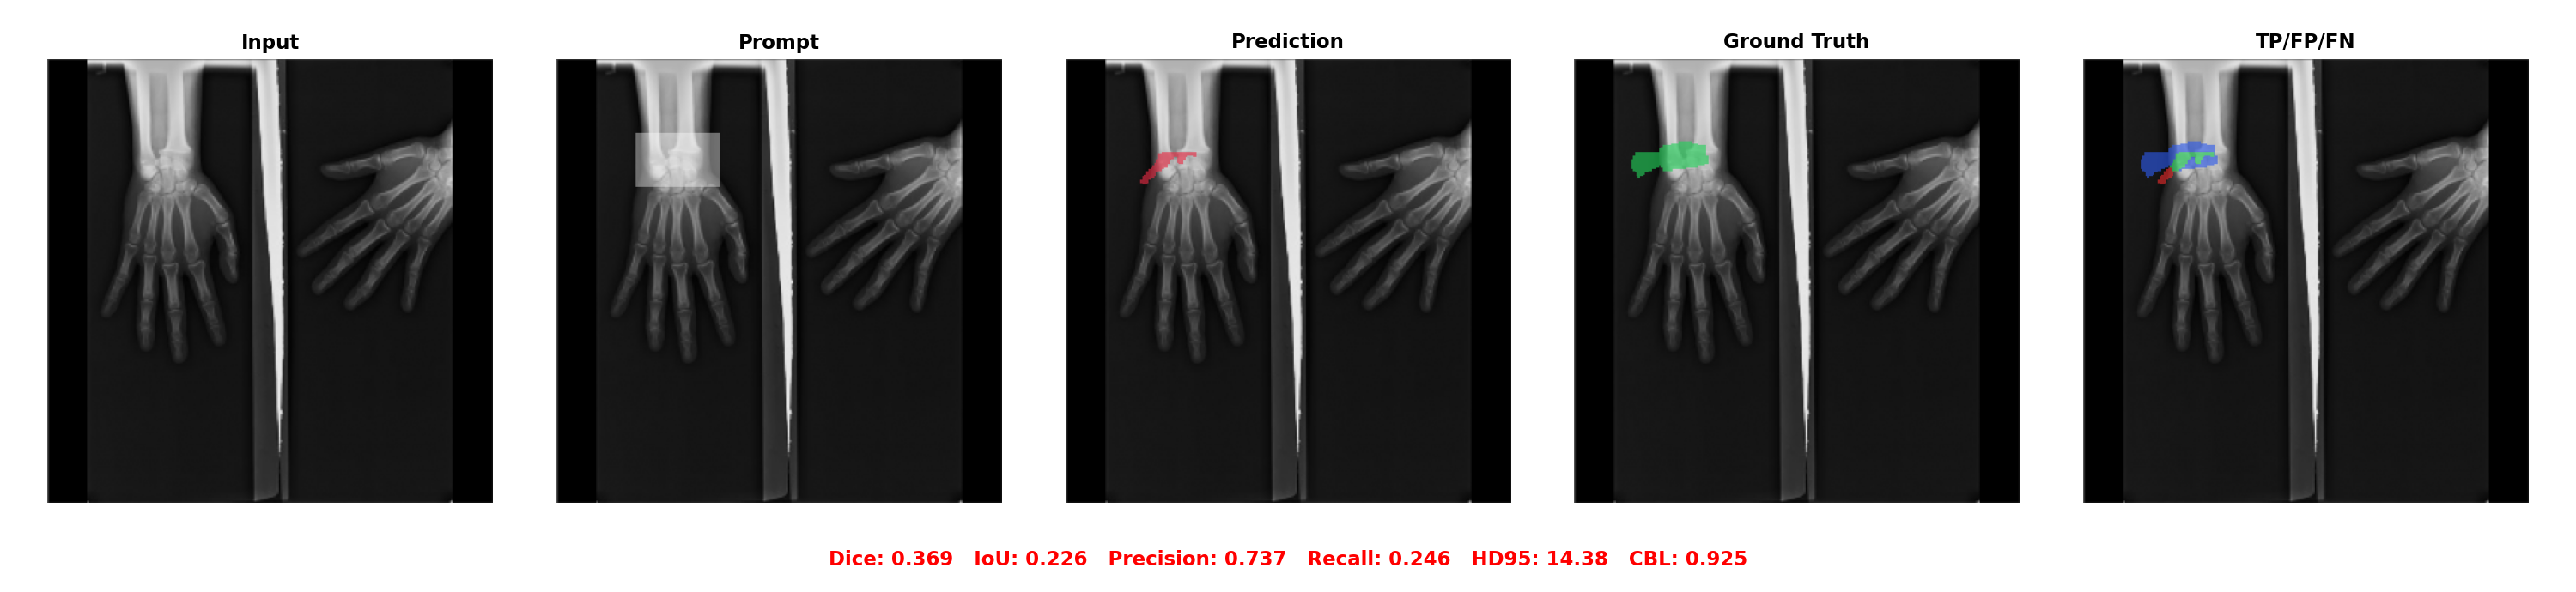

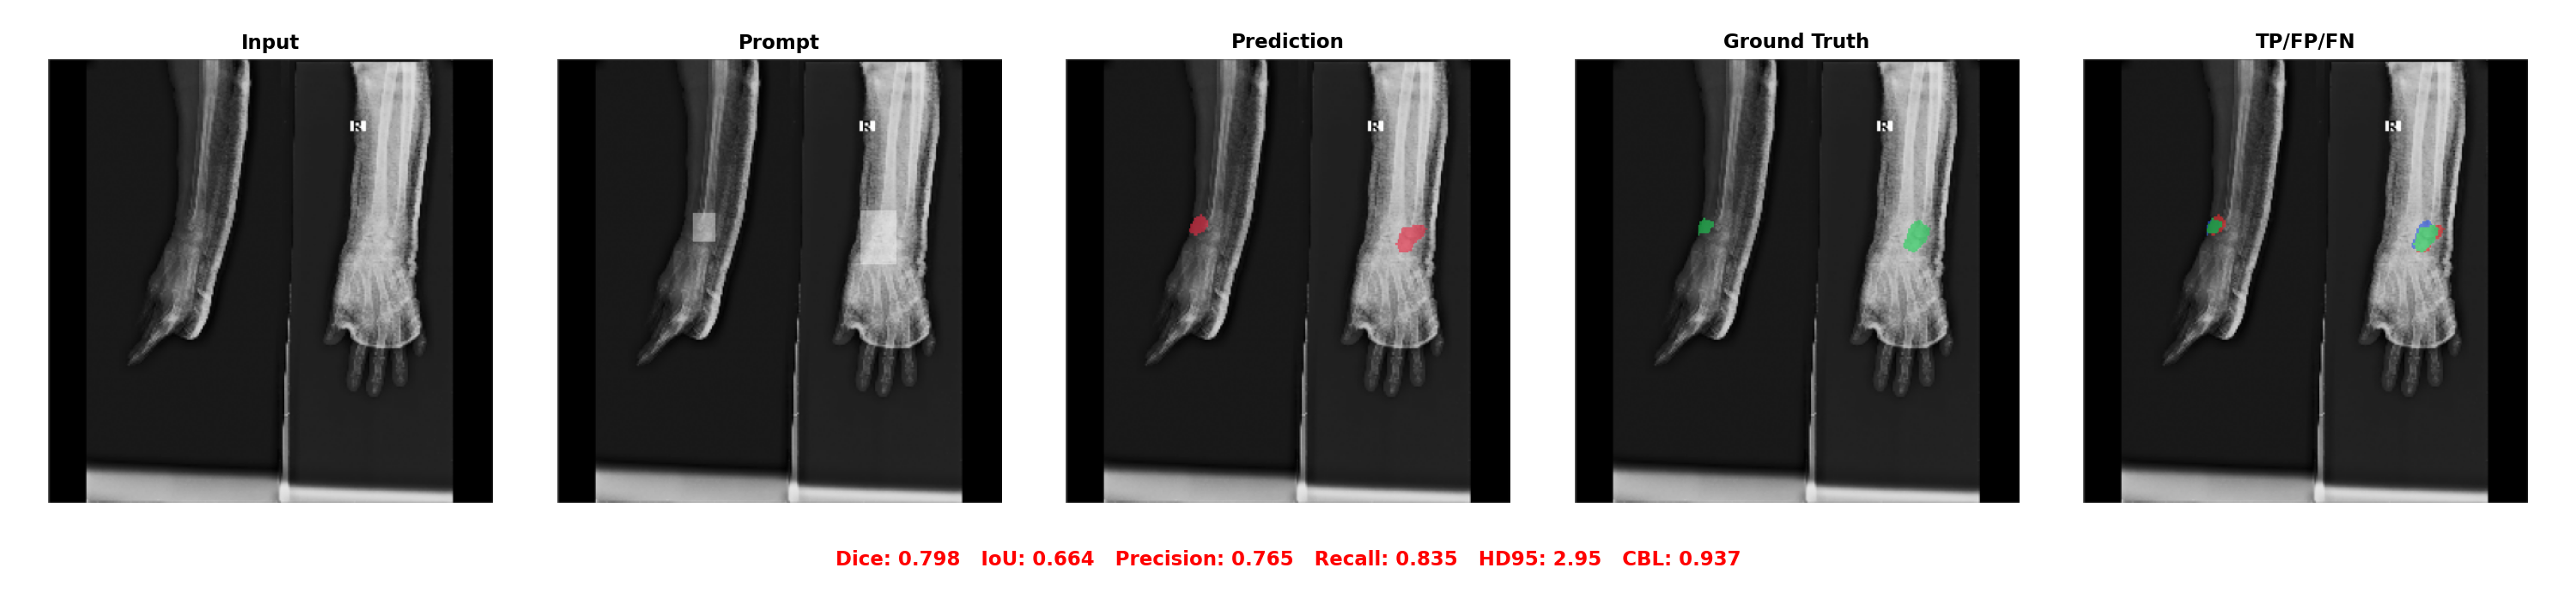

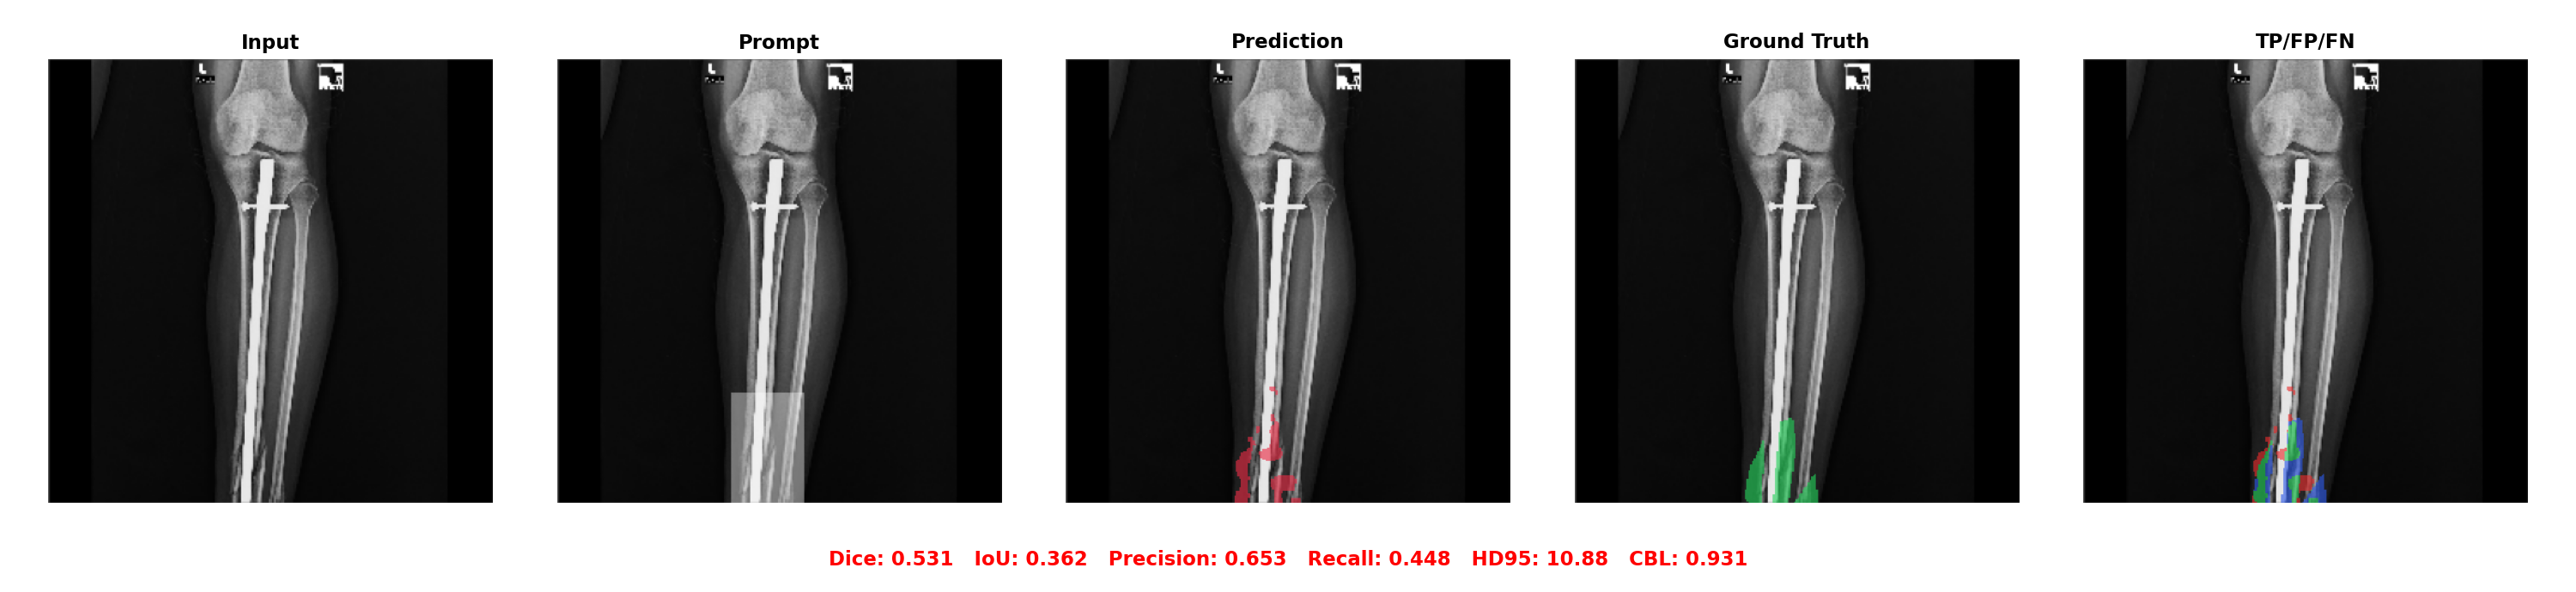

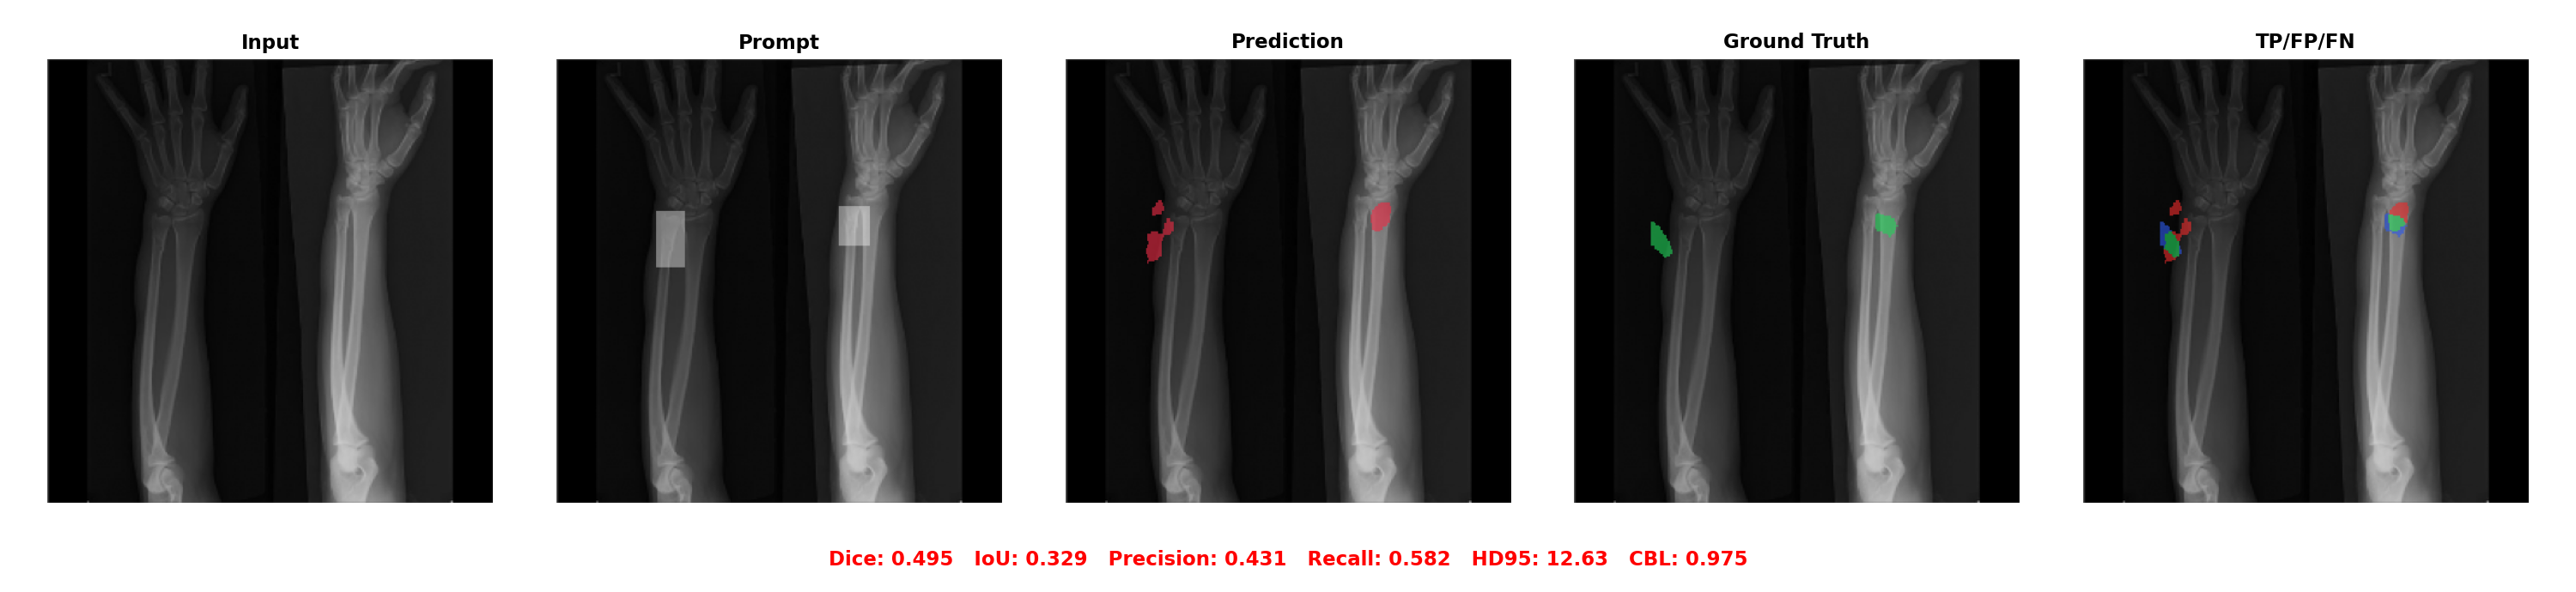

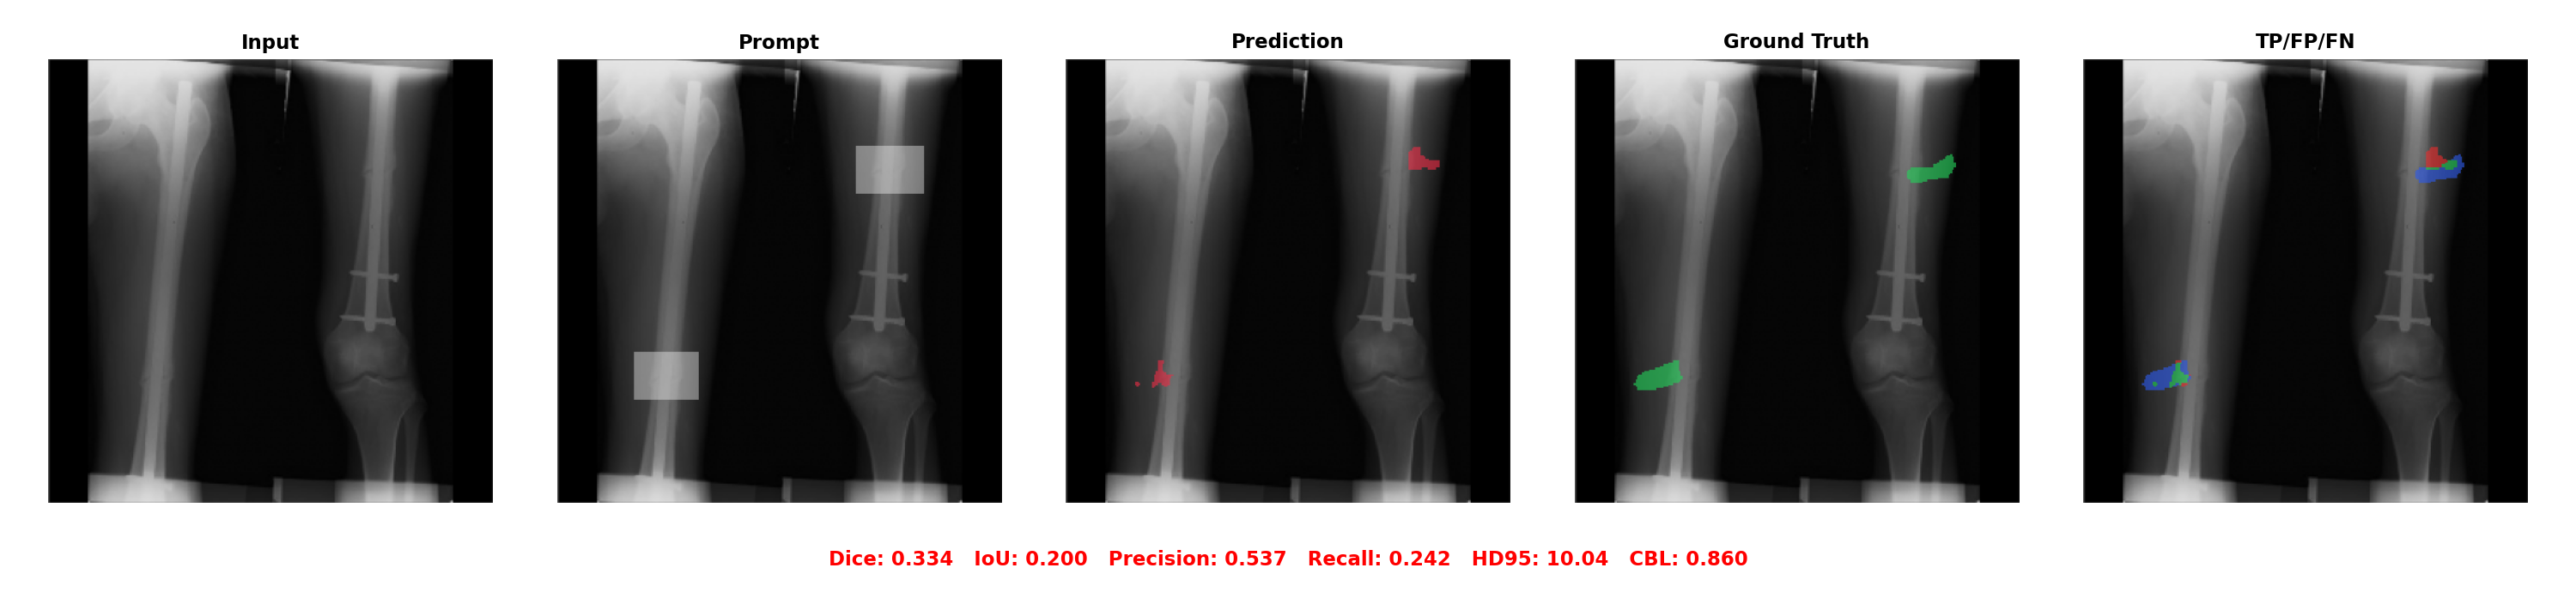

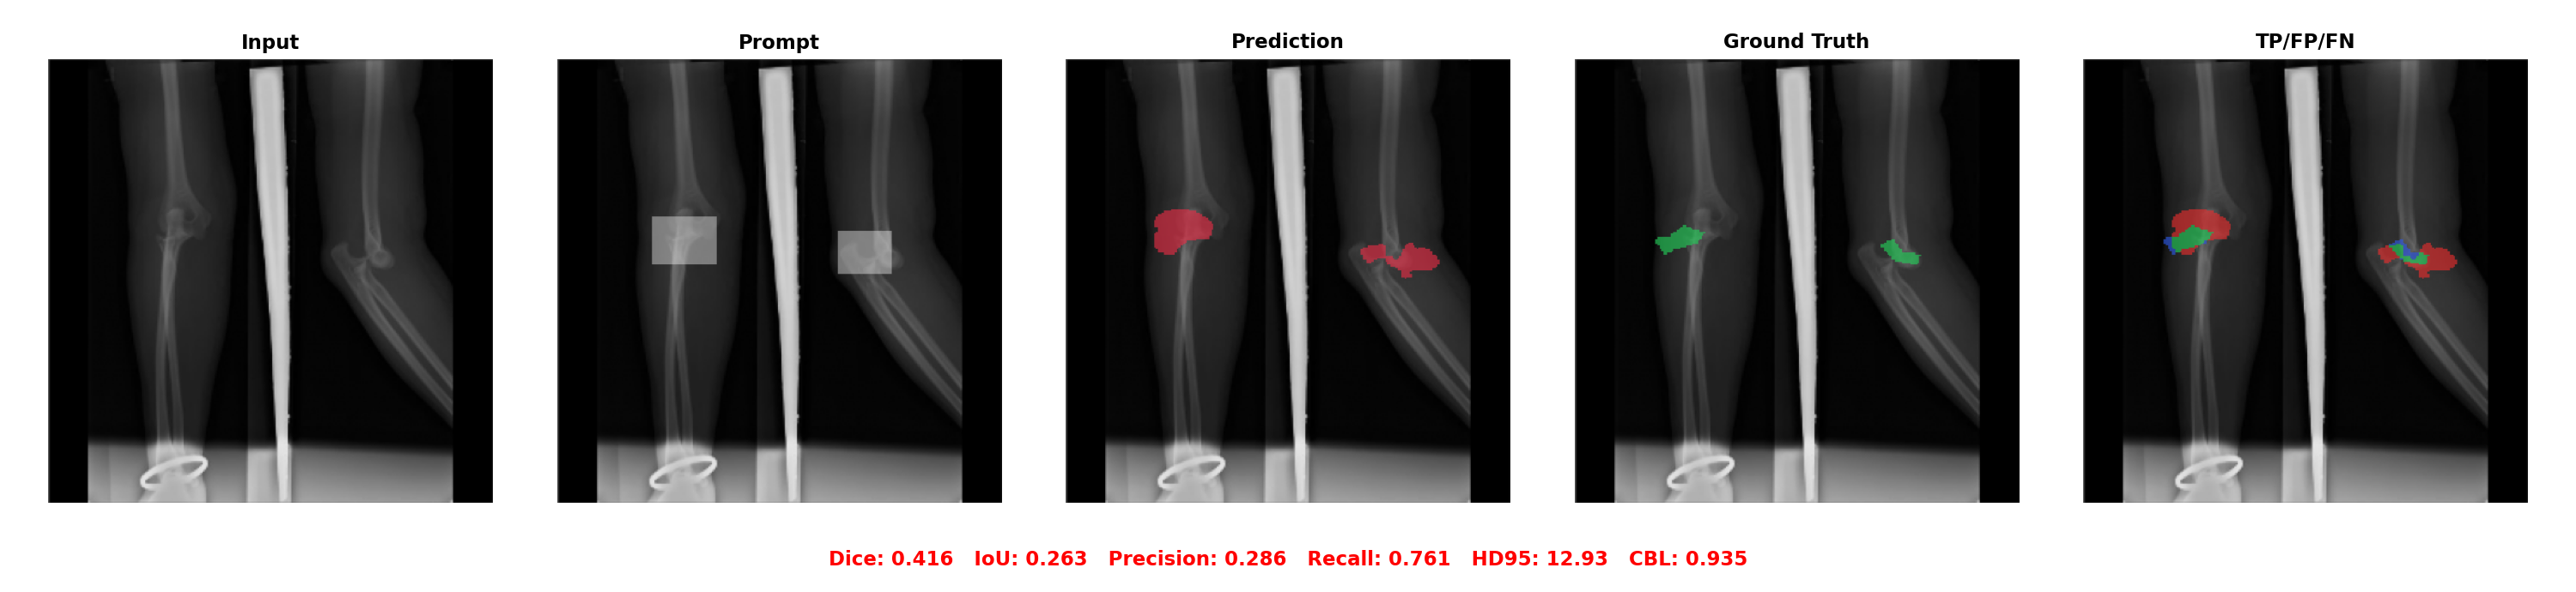

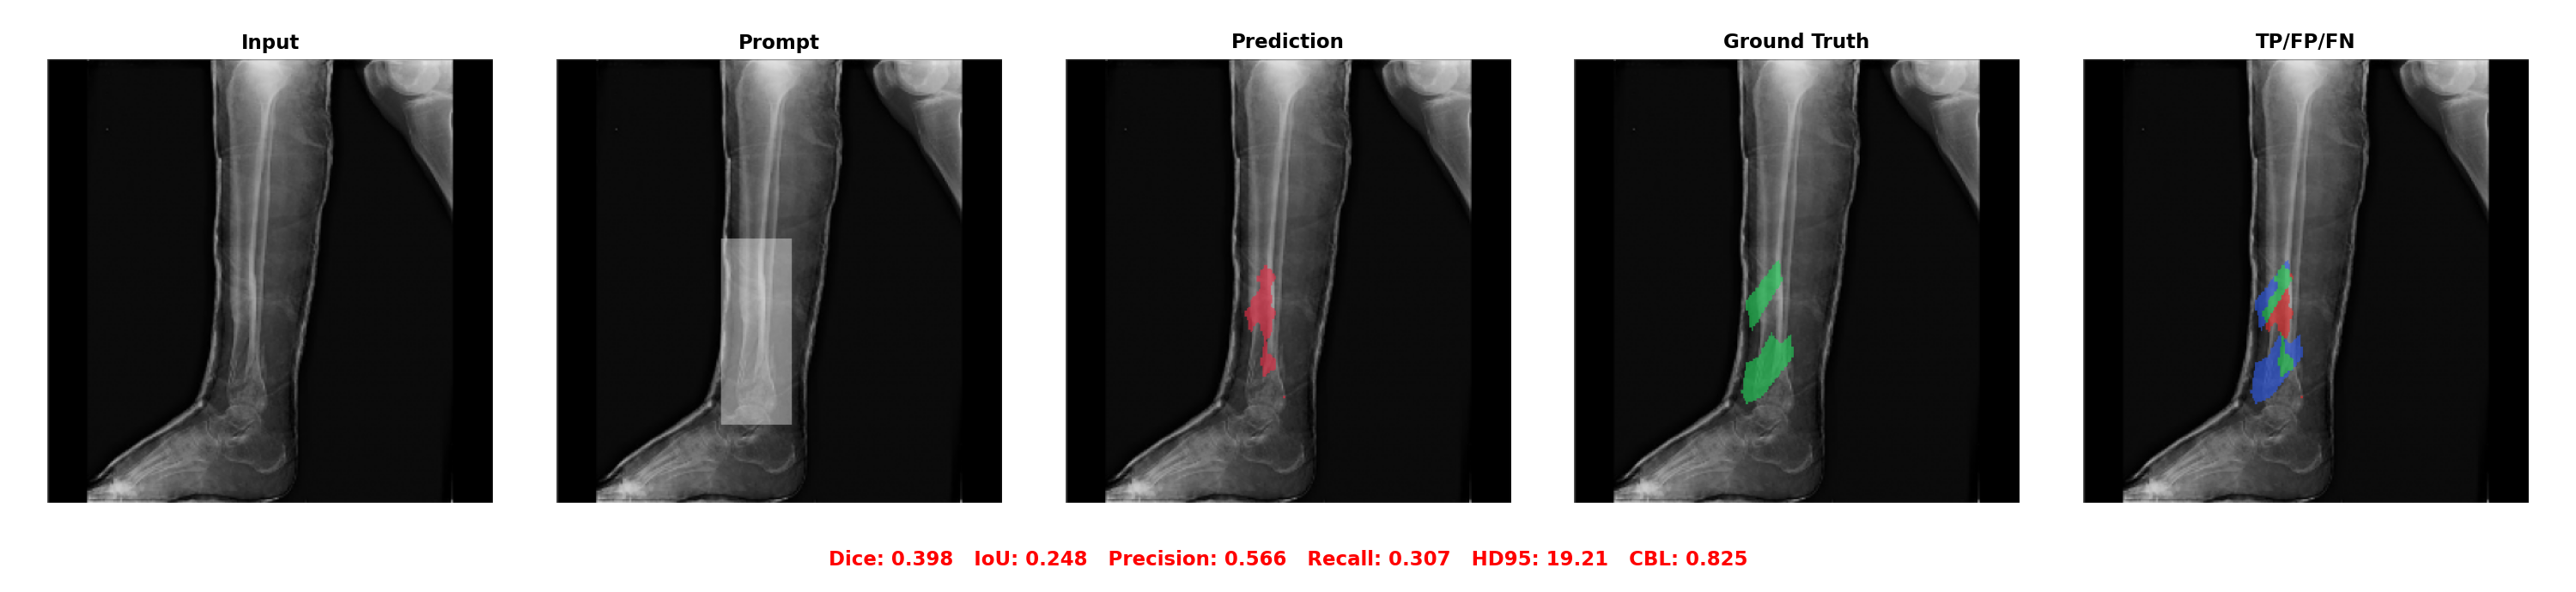

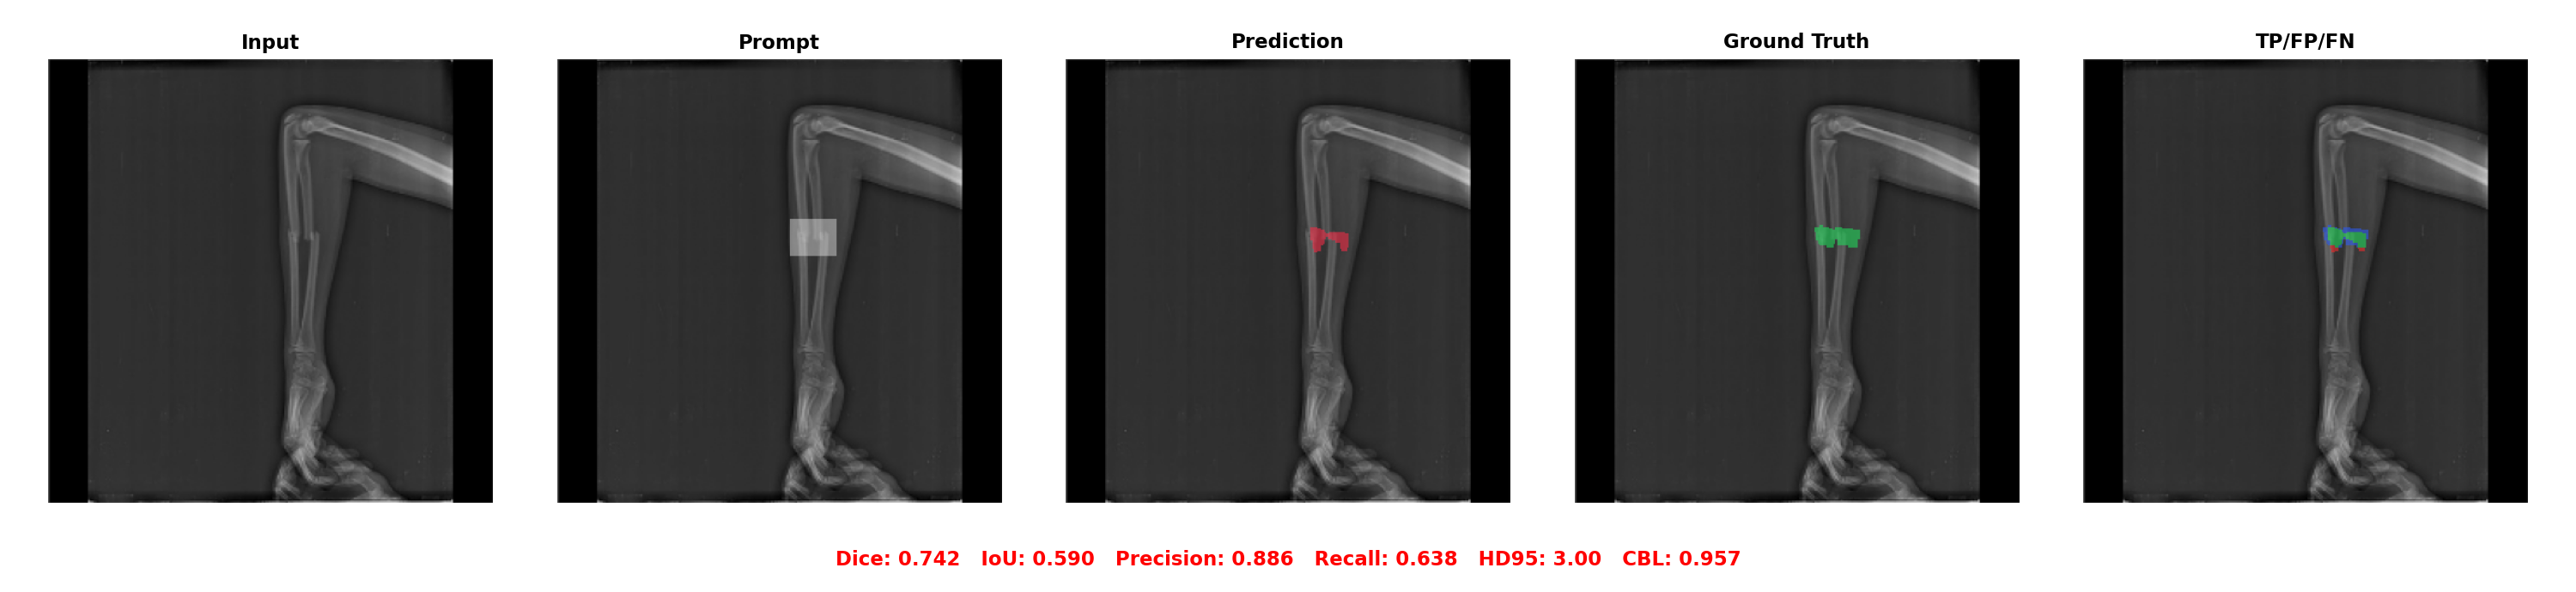

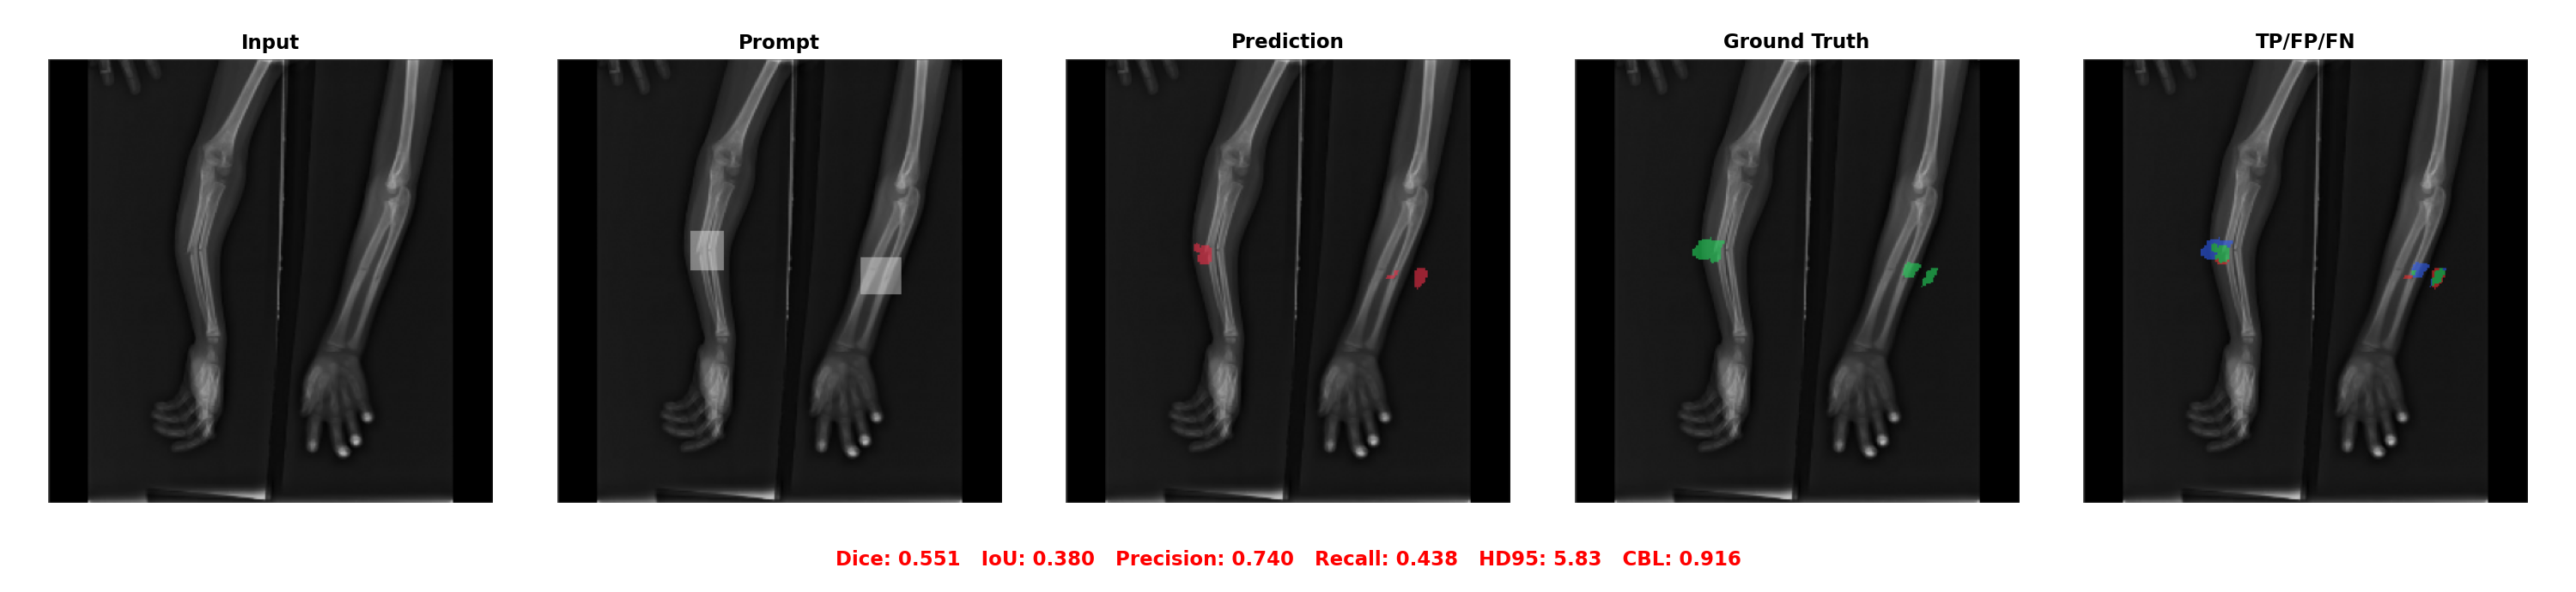

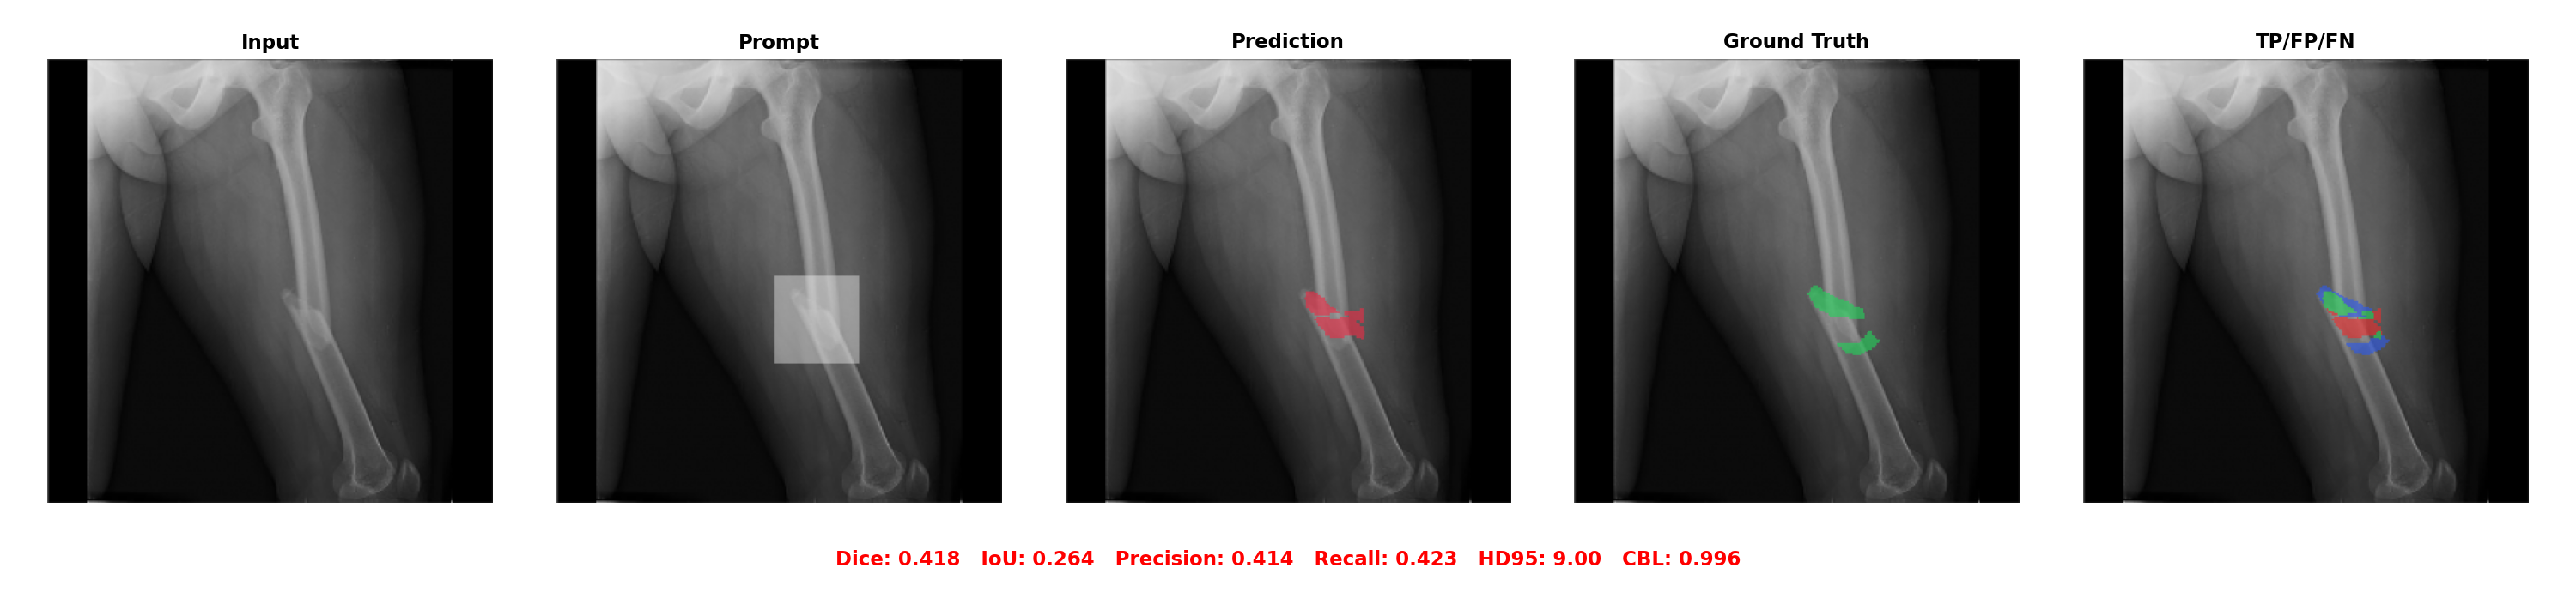

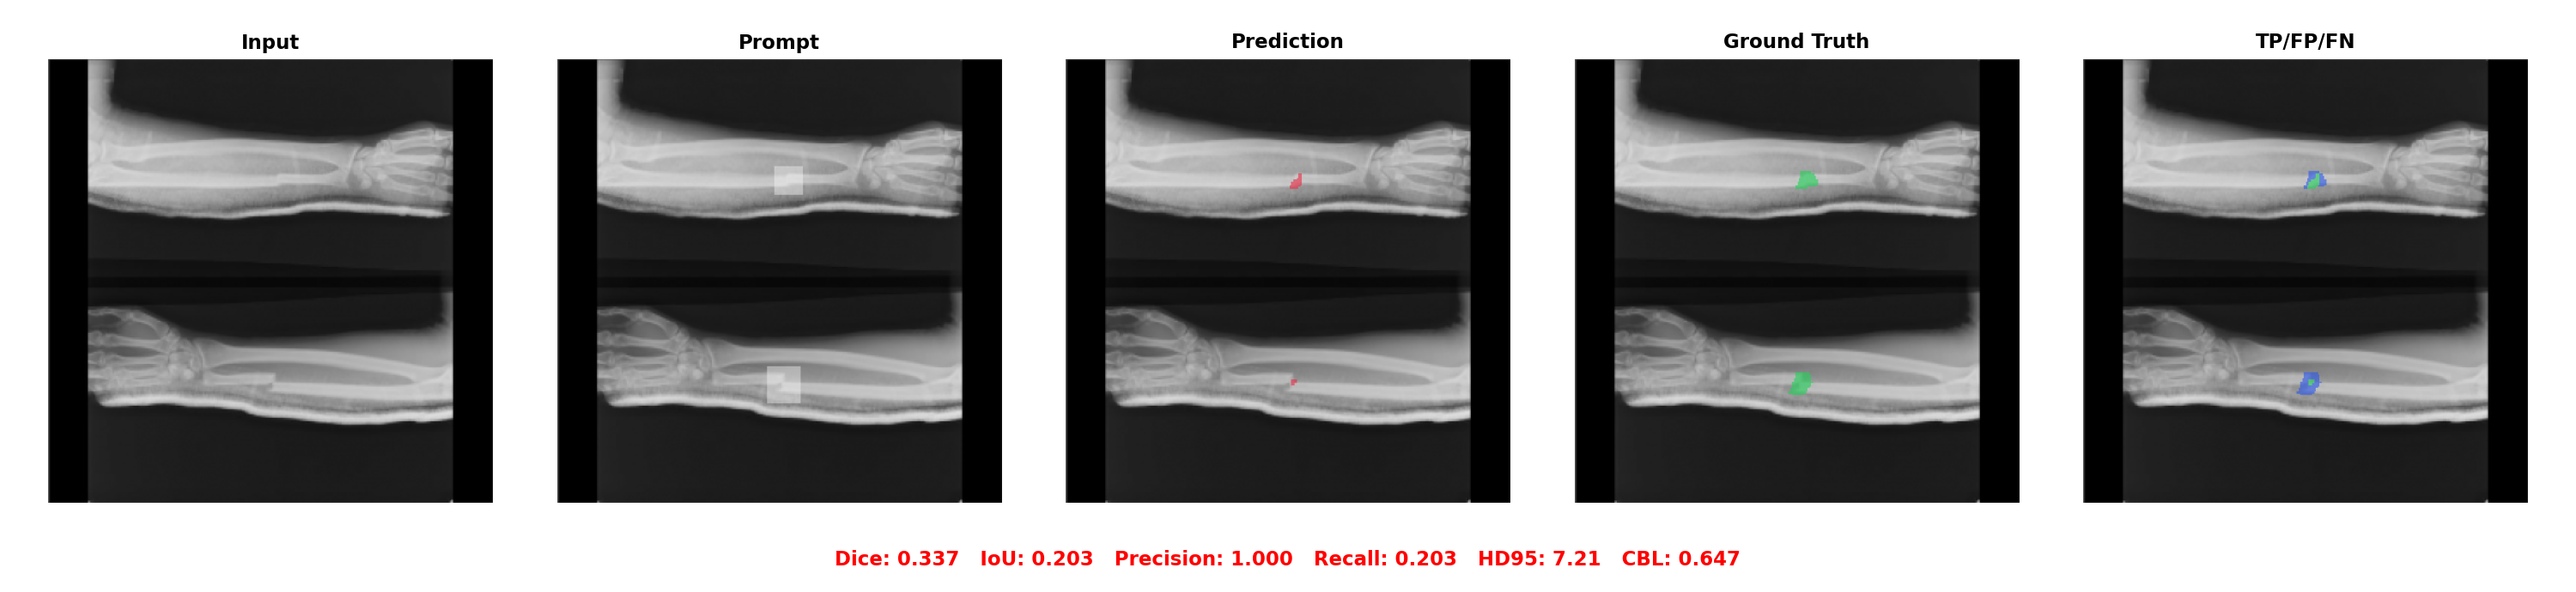

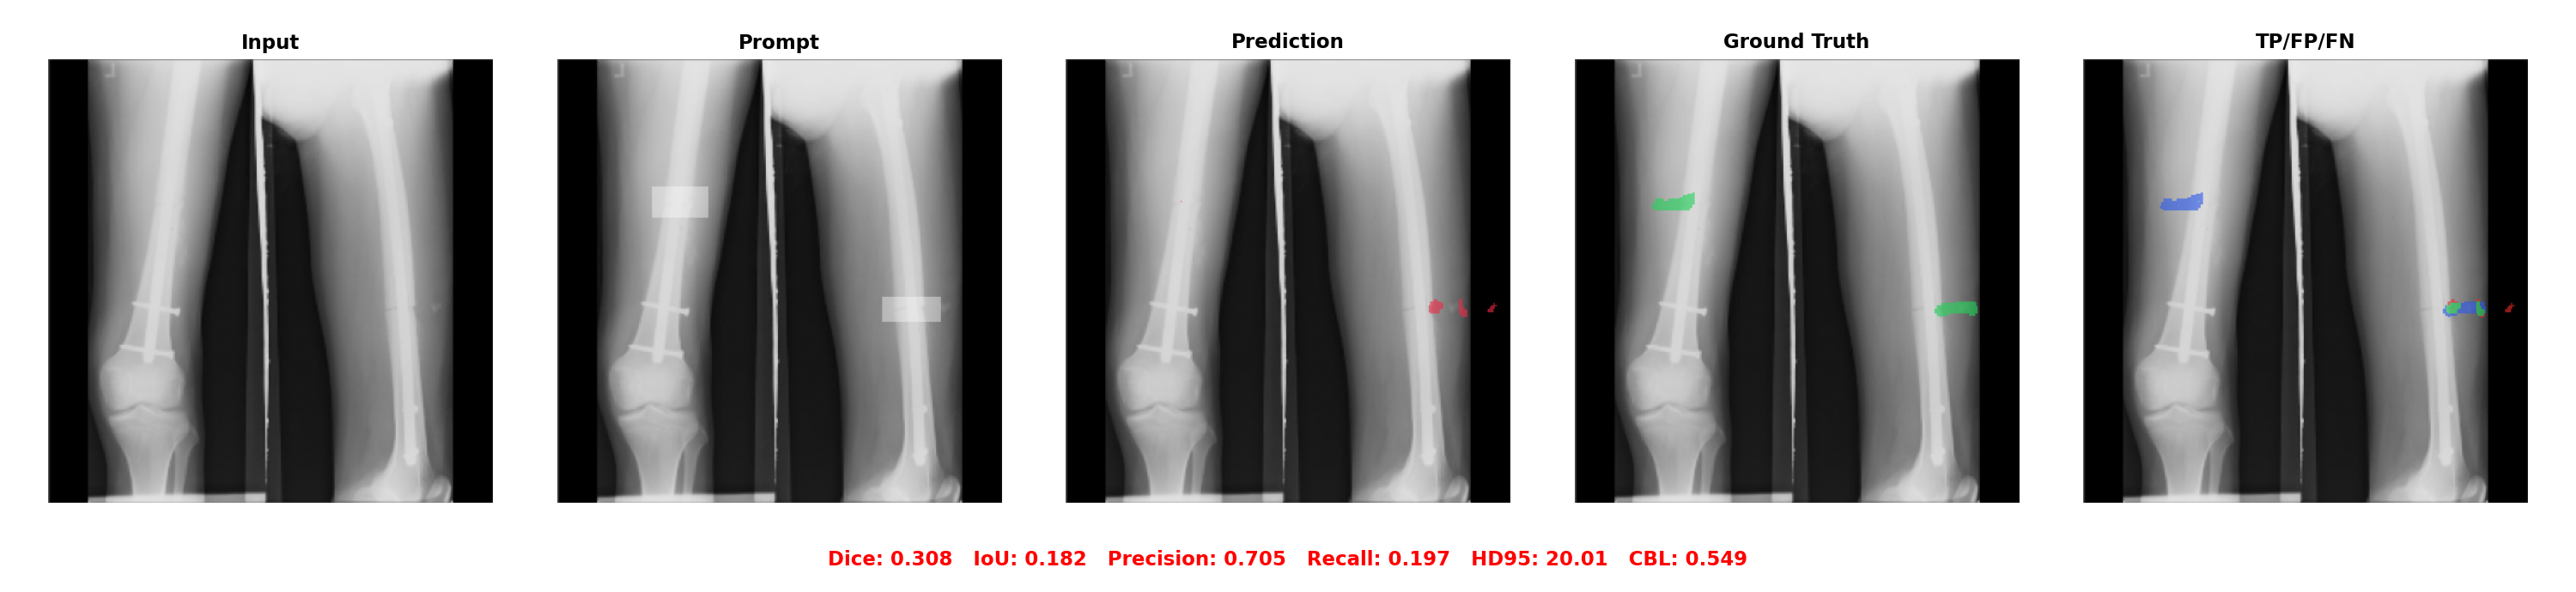

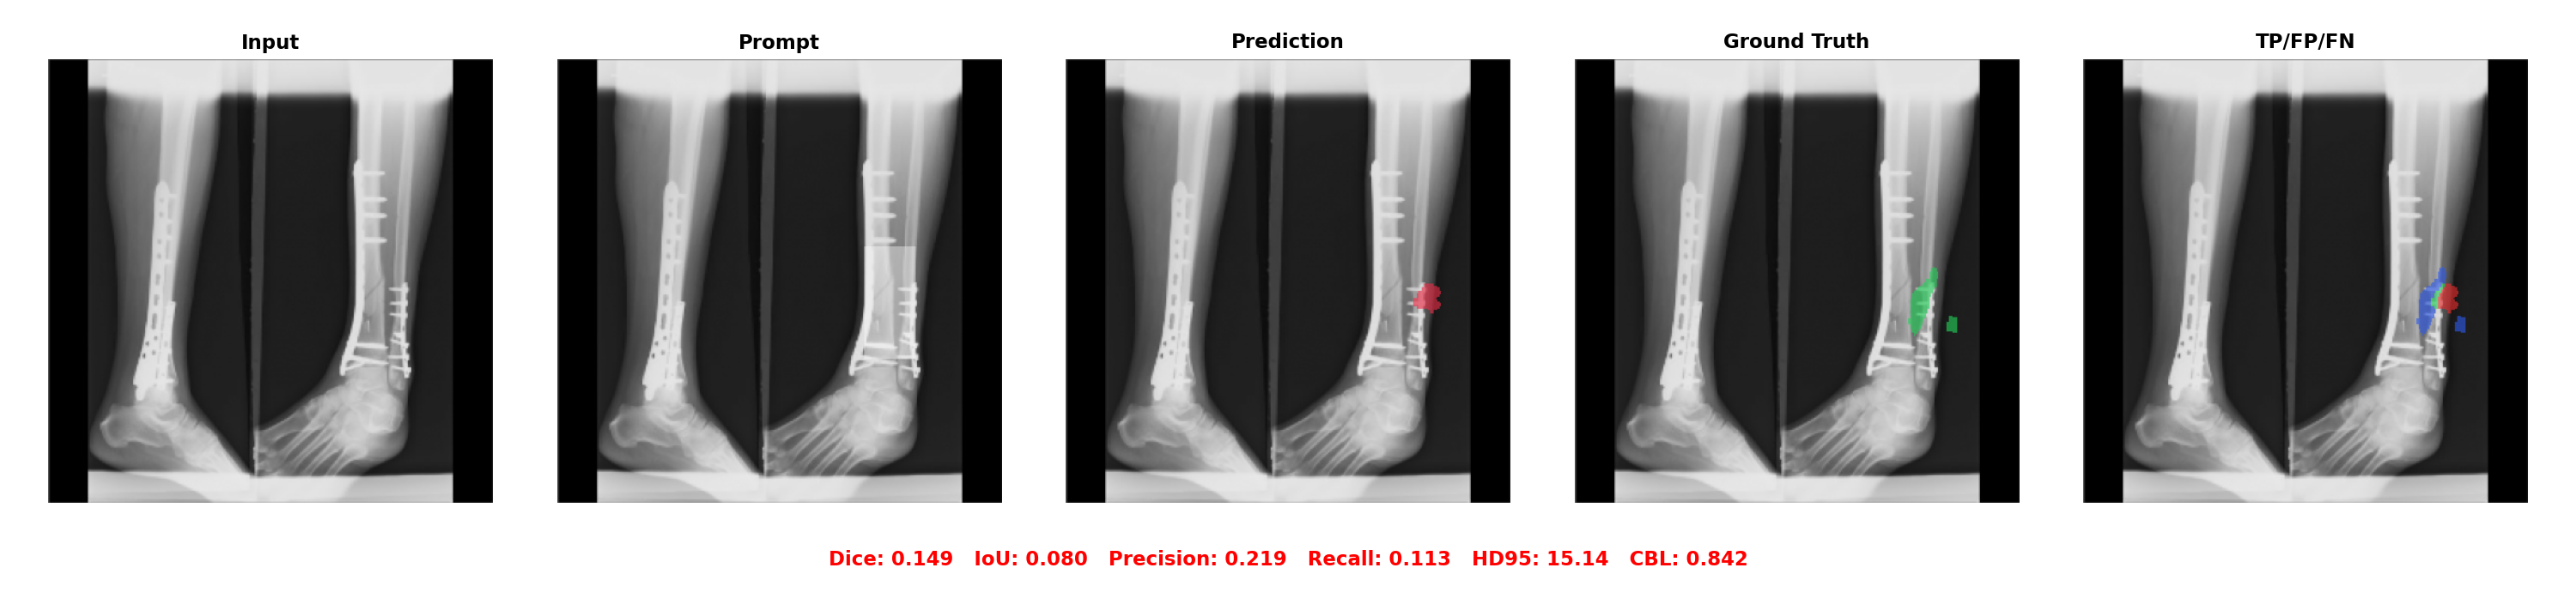

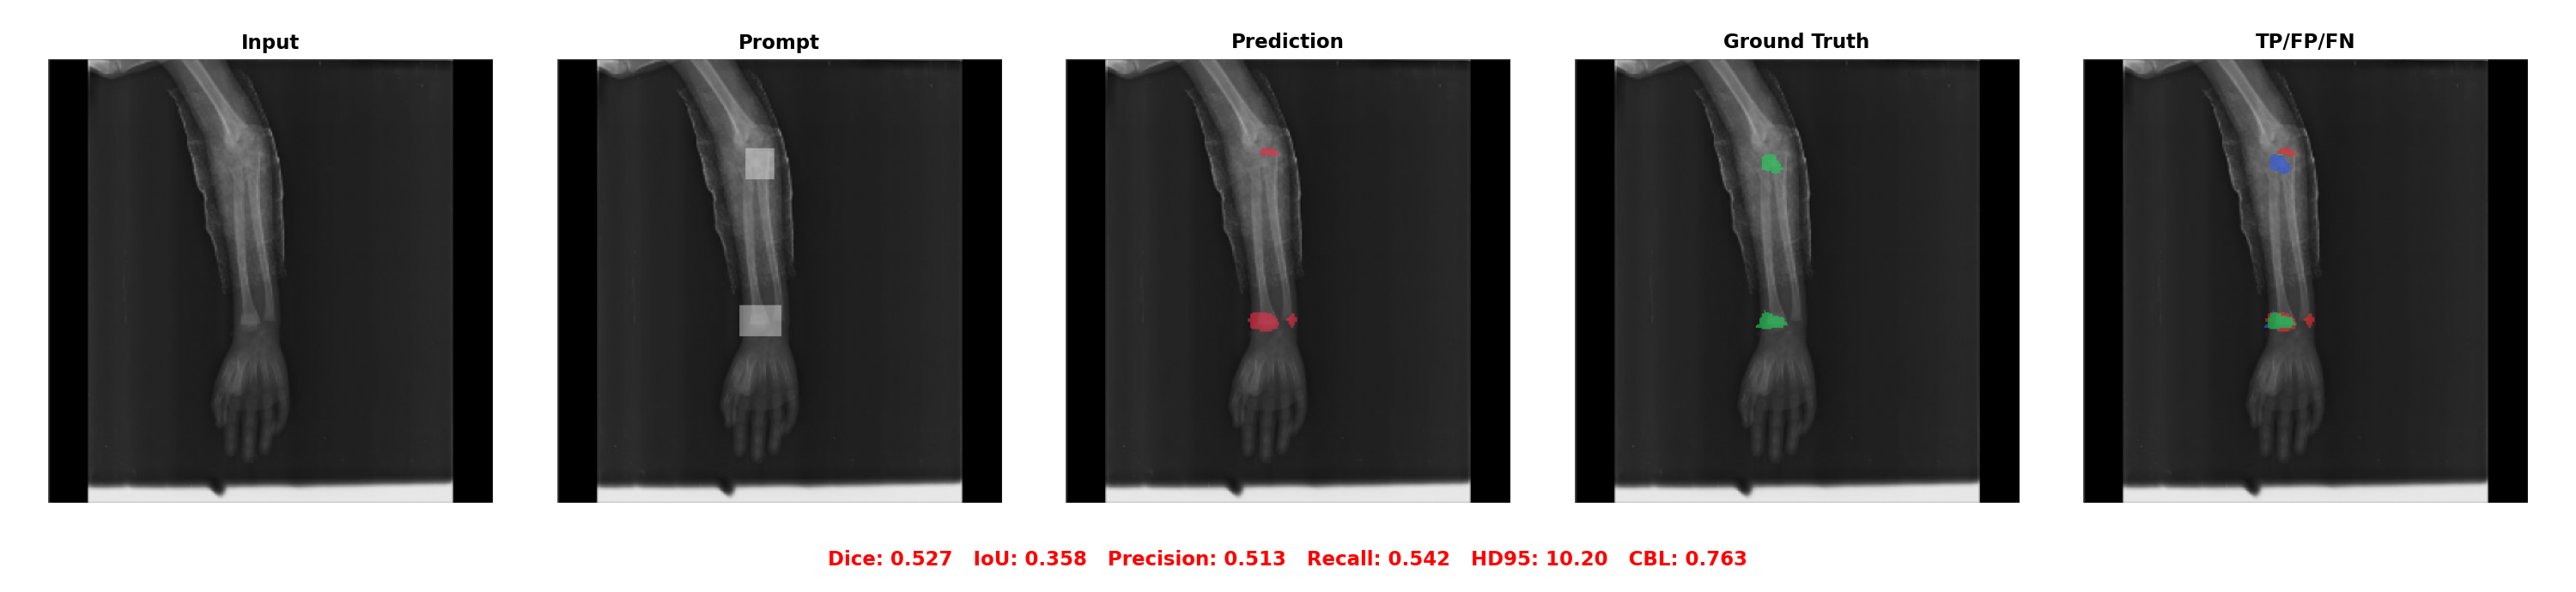

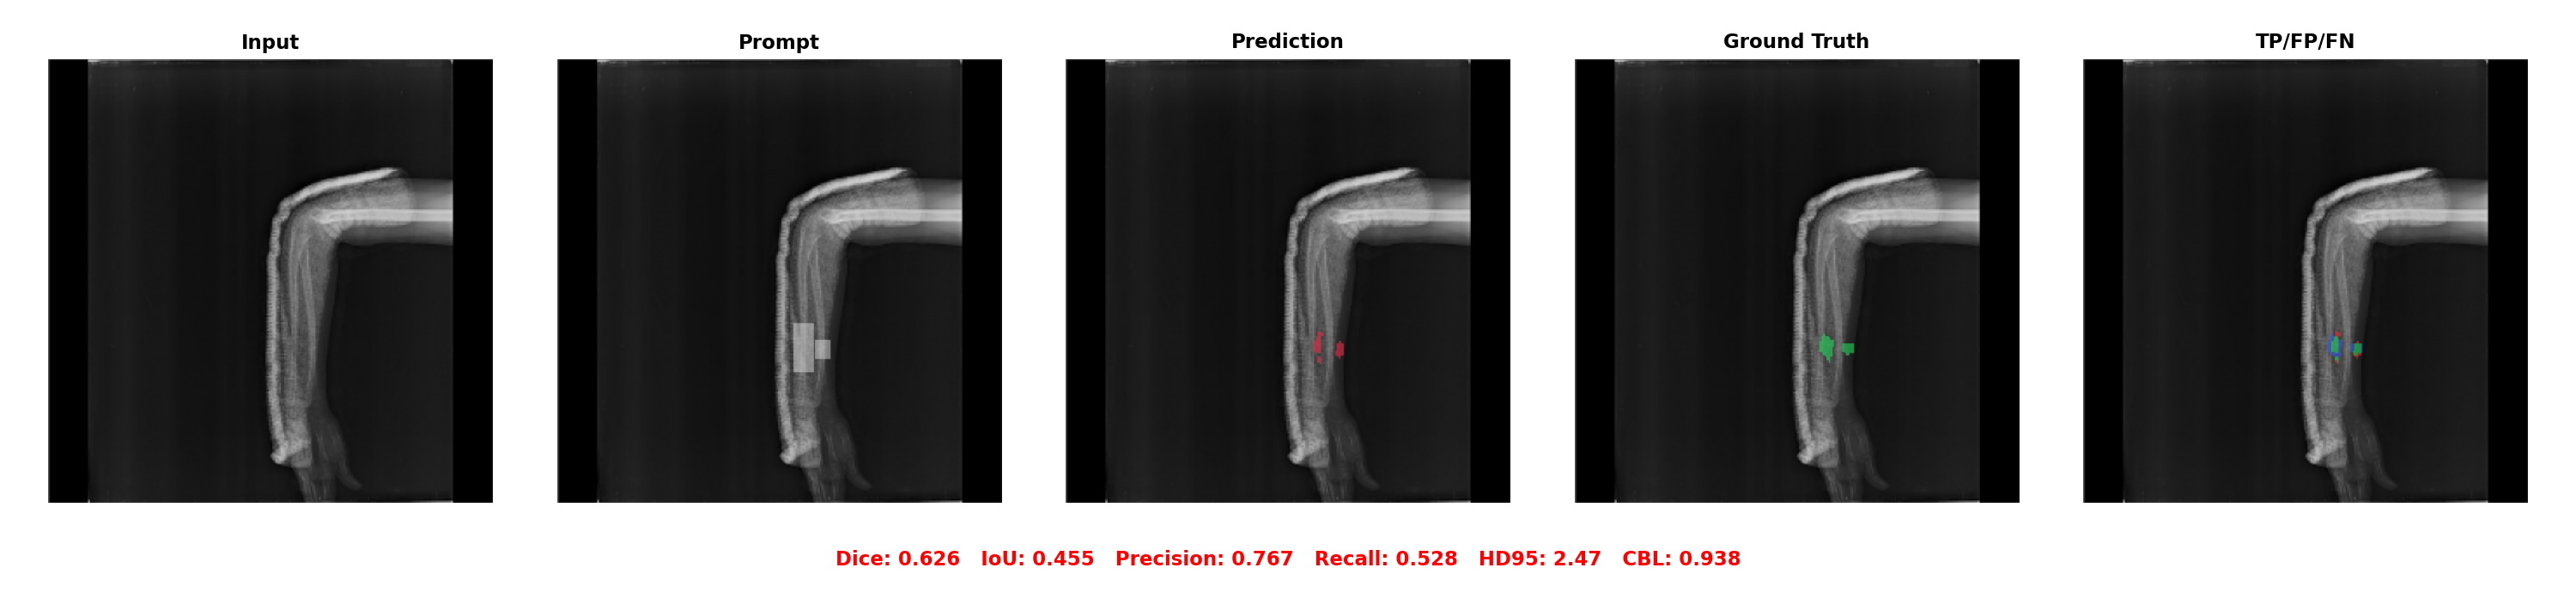

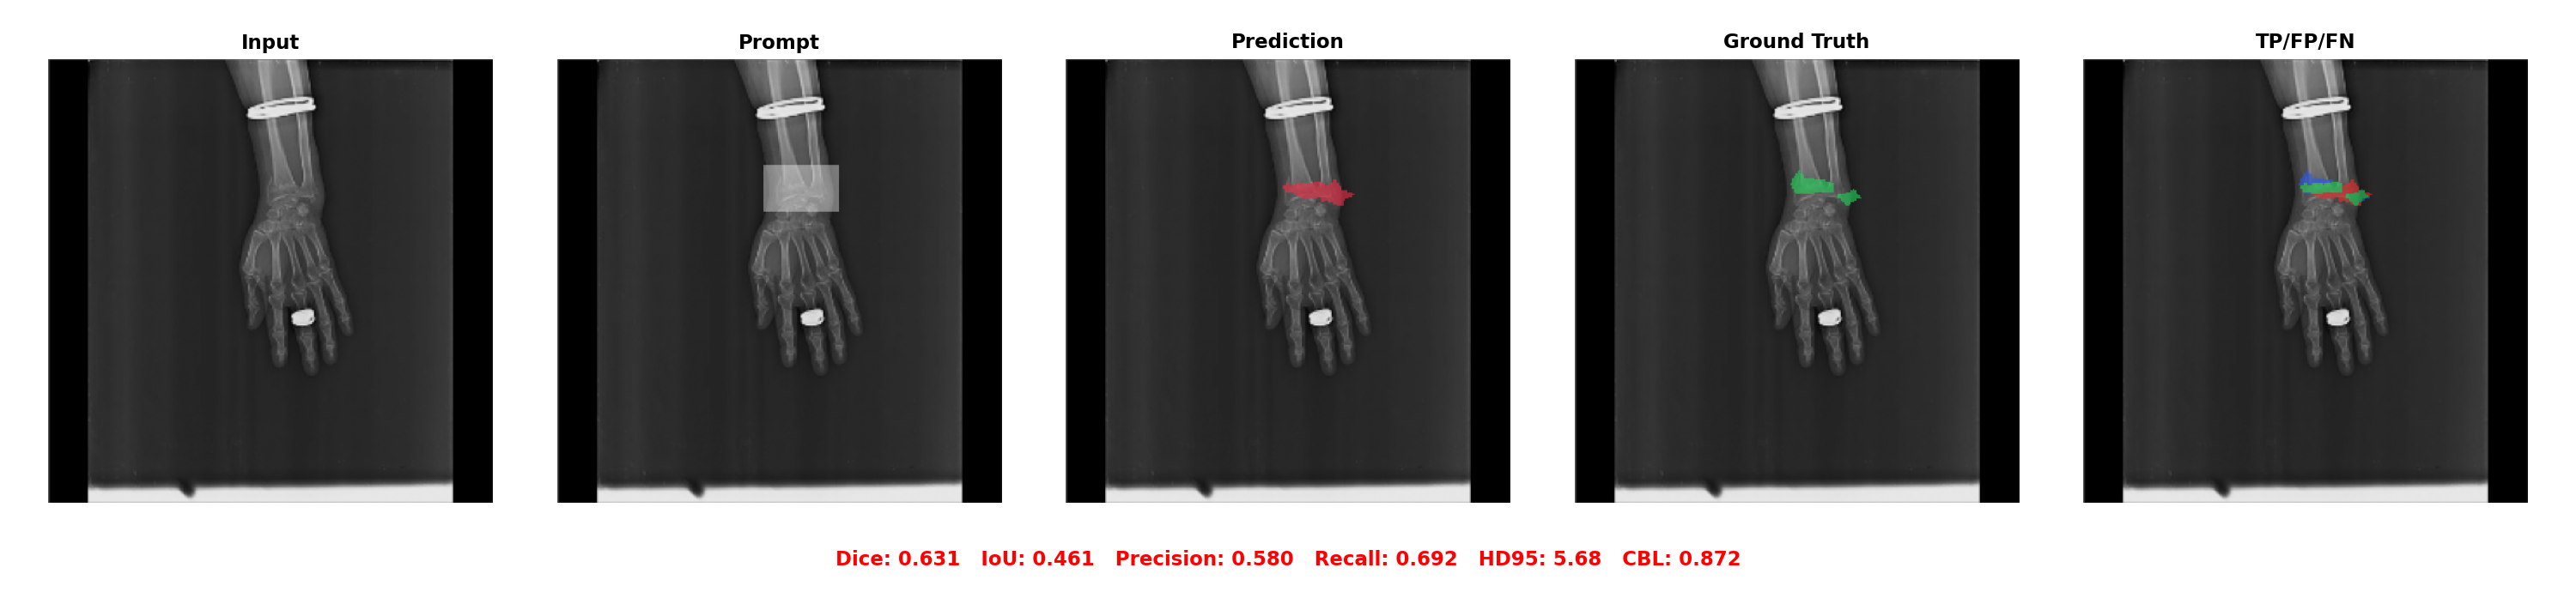

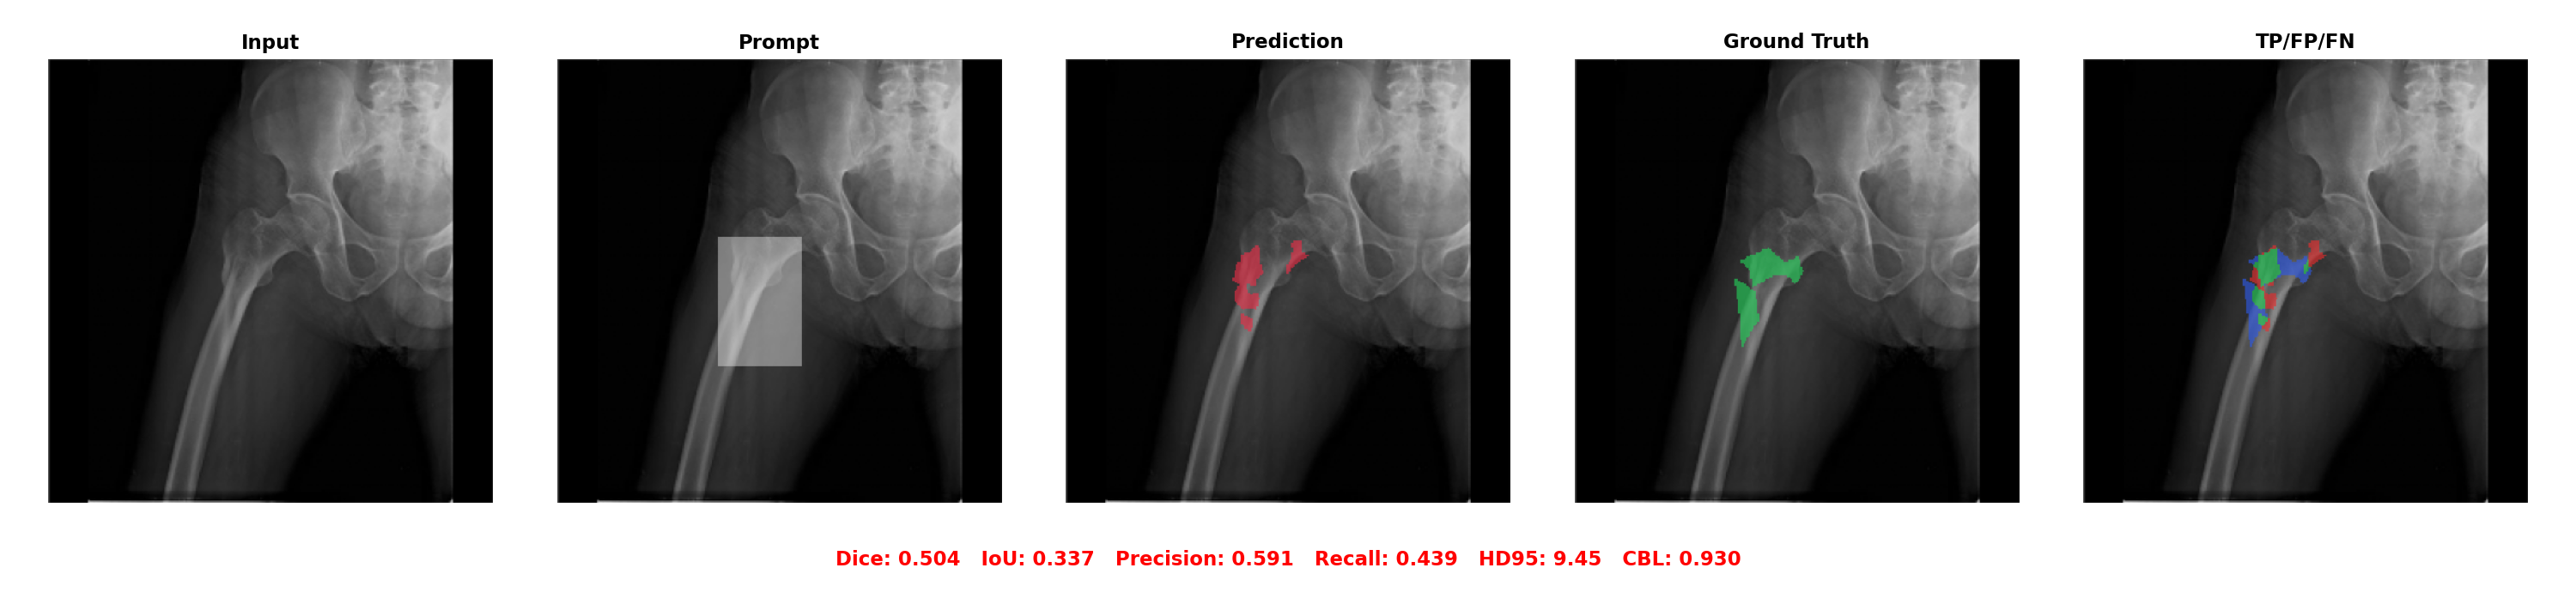

In [12]:
from qualitative_visualization import export_qualitative_rows
import cv2, numpy as np, os, csv, json as _json, glob as _glob
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from IPython.display import display as _ipy_display
from scipy.ndimage import binary_erosion, distance_transform_edt

%cd /kaggle/working/SAM-Med2D

MODES     = ['center_zoom', 'center_shift']
PRED_DIRS = {m: f"workdir/test_results/sammed/boxes_{m}" for m in MODES}
MASK_DIR  = "dataset_FracAtlas/test/masks"
S = 256

def calc_m(prob, gt, eps=1e-6):
    pm = (prob > 0.5).astype(np.float32)
    gm = (gt   > 0.5).astype(np.float32)
    tp = (pm*gm).sum(); fp = (pm*(1-gm)).sum(); fn = ((1-pm)*gm).sum()
    p, g = pm.astype(bool), gm.astype(bool)
    hd95 = float(S)
    if p.any() and g.any():
        pe = p ^ binary_erosion(p); ge = g ^ binary_erosion(g)
        d1 = distance_transform_edt(~ge)[pe]
        d2 = distance_transform_edt(~pe)[ge]
        if len(d1) and len(d2):
            hd95 = float(max(np.percentile(d1, 95), np.percentile(d2, 95)))
    if gm.sum() == 0 or pm.sum() == 0:
        cbl = 0.
    else:
        ys, xs = np.where(gm > 0.5); yp, xp = np.where(pm > 0.5)
        d = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + eps
        cbl = float(np.clip(1. - np.sqrt((xp.mean()-xs.mean())**2 +
                                          (yp.mean()-ys.mean())**2) / d, 0, 1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)),
                iou =float((tp + eps) / (tp + fp + fn + eps)),
                precision=float(tp / (tp + fp+eps)),
                recall   =float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl)

KEYS = ['dice','iou','precision','recall','hd95','cbl']
HDRS = ['Dice↑','IoU↑','Prec↑','Rec↑','HD95↓','CBL↑']

# ── 1. Metrics image-level ────────────────────────────────────────────────────
print(f'\n{"="*78}')
print('  SAM-Med2D Fine-tuned - IMAGE-LEVEL metrics (GT union + max-merge)')
print(f'{"="*78}')
print(f"  {'Mode':<16}" + ''.join(f'{h:>8}' for h in HDRS) + f"  {'N_img':>6}")
print(f"  {'-'*74}")

os.makedirs('workdir/test_results/csv', exist_ok=True)
all_img_recs = {}
ft_results = {}

with open('dataset_FracAtlas/label2image_test.json') as _f:
    l2i = _json.load(_f)
img_lookup = {}
for mp, ip in l2i.items():
    st = os.path.basename(mp).rsplit('_', 1)[0]
    if st not in img_lookup: img_lookup[st] = ip

for mode in MODES:
    pred_dir = PRED_DIRS[mode]
    if not os.path.exists(pred_dir):
        print(f'  ⚠ {mode}: predictions not found - run the test cell first'); continue

    stem_data = {}
    for fn in sorted(os.listdir(MASK_DIR)):
        if not fn.endswith('.png'): continue
        parts = fn.rsplit('_', 1)
        if len(parts) < 2: continue
        stem = parts[0]
        gt_p = cv2.imread(os.path.join(MASK_DIR,   fn), cv2.IMREAD_GRAYSCALE)
        pr_p = cv2.imread(os.path.join(pred_dir,   fn), cv2.IMREAD_GRAYSCALE)
        if gt_p is None or pr_p is None: continue
        gt256 = cv2.resize(gt_p, (S,S), interpolation=cv2.INTER_NEAREST).astype(np.float32)/255.
        pr256 = cv2.resize(pr_p, (S,S), interpolation=cv2.INTER_NEAREST).astype(np.float32)/255.
        if stem not in stem_data:
            stem_data[stem] = dict(gt=gt256.copy(), prob=pr256.copy(), n=1)
        else:
            np.maximum(stem_data[stem]['gt'],   gt256, out=stem_data[stem]['gt'])
            np.maximum(stem_data[stem]['prob'], pr256, out=stem_data[stem]['prob'])
            stem_data[stem]['n'] += 1

    if not stem_data: continue
    recs = []
    for stem, d in sorted(stem_data.items()):
        m = calc_m(d['prob'], d['gt'])
        recs.append(dict(stem=stem, gt=d['gt'], prob=d['prob'], n=d['n'],
                         img_path=img_lookup.get(stem,''), **m))
    all_img_recs[mode] = recs

    avg = {k: np.mean([r[k] for r in recs]) for k in KEYS}
    ft_results[mode] = avg
    print(f"  {mode:<16}" + ''.join(f"{avg[k]:>8.4f}" for k in KEYS) + f"  {len(recs):>6}")

    csv_path = f'workdir/test_results/csv/sammed2d_finetune_{mode}_img.csv'
    with open(csv_path, 'w', newline='') as fc:
        w = csv.writer(fc)
        w.writerow(['model','mode'] + KEYS + ['N_img'])
        w.writerow(['SAM-Med2D-FT', mode] + [f'{avg[k]:.4f}' for k in KEYS] + [len(recs)])

print(f'{"="*78}')

# ── 2. PGA-style 5-col visualization ──────────────────────────────────────────
VIS_MODE = 'center_zoom'
MIN_POLY  = 2
N_MIN     = 10

if VIS_MODE not in all_img_recs:
    print(f"Warning: no results found for {VIS_MODE}. Run Test A first.")
else:
    recs_viz = [r for r in all_img_recs[VIS_MODE] if r['n'] >= MIN_POLY]
    assert len(recs_viz) >= N_MIN, f'Only {len(recs_viz)} images with >={MIN_POLY} GT polygons are available (need {N_MIN}).'
    N_SHOW = len(recs_viz)

    def _resize_and_pad_viz(array, size, interpolation, pad_value=0):
        """Isotropic resize + center pad to a size x size square, matches
        dataset.py's PromptSegmentationDataset._resize_and_pad. Used only for
        this display block; the Dice/IoU/HD95/CBL numbers above (and the CSV)
        keep the plain square resize they were already computed with."""
        h, w = array.shape[:2]
        scale = min(size / w, size / h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        resized = cv2.resize(array, (new_w, new_h), interpolation=interpolation)
        padded = np.full((size, size), pad_value, dtype=resized.dtype)
        pad_left = (size - new_w) // 2
        pad_top = (size - new_h) // 2
        padded[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized
        return padded

    def build_letterboxed_masks(stem, pred_dir):
        """Re-load per-polygon GT/pred PNGs and letterbox-pad + max-merge them,
        independently from `stem_data` above (which stays on the plain square
        resize the reported CSV numbers were computed from)."""
        gt_union = np.zeros((S, S), dtype=np.float32)
        prob_max = np.zeros((S, S), dtype=np.float32)
        for gt_path in sorted(_glob.glob(os.path.join(MASK_DIR, f"{stem}_*.png"))):
            fn = os.path.basename(gt_path)
            gt_raw = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
            if gt_raw is None: continue
            gt256 = _resize_and_pad_viz(gt_raw, S, cv2.INTER_NEAREST).astype(np.float32)
            if gt256.max() > 1: gt256 /= 255.
            np.maximum(gt_union, gt256, out=gt_union)
            pr_raw = cv2.imread(os.path.join(pred_dir, fn), cv2.IMREAD_GRAYSCALE)
            if pr_raw is not None:
                pr256 = _resize_and_pad_viz(pr_raw, S, cv2.INTER_NEAREST).astype(np.float32)
                if pr256.max() > 1: pr256 /= 255.
                np.maximum(prob_max, pr256, out=prob_max)
        return gt_union, prob_max

    def get_poly_bboxes(stem, r=0.30):
        bboxes = []
        for pm_path in sorted(_glob.glob(os.path.join(MASK_DIR, f"{stem}_*.png"))):
            pm = cv2.imread(pm_path, cv2.IMREAD_GRAYSCALE)
            if pm is None: continue
            pm256 = _resize_and_pad_viz(pm, S, cv2.INTER_NEAREST).astype(np.float32)
            if pm256.max() > 1: pm256 /= 255.
            ys, xs = np.where(pm256 > 0.5)
            if not len(xs): continue
            x0,x1 = int(xs.min()),int(xs.max())
            y0,y1 = int(ys.min()),int(ys.max())
            gw,gh = x1-x0, y1-y0
            bboxes.append((max(0,x0-gw*r), max(0,y0-gh*r),
                           min(S,x1+gw*r)-max(0,x0-gw*r),
                           min(S,y1+gh*r)-max(0,y0-gh*r)))
        return bboxes

    fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4*N_SHOW))
    if N_SHOW == 1: axes = axes[np.newaxis, :]
    fig.suptitle(
        f'SAM-Med2D Fine-tuned - {N_SHOW} images with >={MIN_POLY} GT polygon (center_zoom, image-level)',
        fontsize=13, y=1.001)

    for ax, ct in zip(axes[0], ['Input image','Image + box prompts',
                                  'Prediction (merged)','Ground truth','TP/FP/FN']):
        ax.set_title(ct, fontsize=10, fontweight='bold')

    for count, rec in enumerate(recs_viz):
        img_gray = cv2.imread(rec['img_path'], cv2.IMREAD_GRAYSCALE) if rec['img_path'] else None
        if img_gray is not None:
            img_np = _resize_and_pad_viz(img_gray, S, cv2.INTER_LINEAR).astype(np.float32) / 255.
        else:
            img_np = np.zeros((S,S), dtype=np.float32)

        gt_union_viz, prob_max_viz = build_letterboxed_masks(rec['stem'], PRED_DIRS[VIS_MODE])
        gt_np   = (gt_union_viz > 0.5).astype(float)
        pred_np = (prob_max_viz > 0.5).astype(float)
        dice, iou, pre, rec_ = rec['dice'], rec['iou'], rec['precision'], rec['recall']

        row = axes[count]
        bg  = np.stack([img_np]*3, axis=-1)

        # Col 0: Input image
        row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        row[0].set_ylabel(f'#{count+1} [{rec["n"]} poly]\nDice={dice:.3f}', fontsize=8)

        # Col 1: Image + per-polygon box prompts
        row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
        for bx in get_poly_bboxes(rec['stem']):
            row[1].add_patch(Rectangle((bx[0],bx[1]), bx[2], bx[3],
                             linewidth=2, edgecolor='yellow', facecolor='none'))
        row[1].set_title(rec['stem'], fontsize=6, pad=2)

        # Col 2: Prediction (red overlay)
        pr_ov = bg.copy()
        pr_ov[...,0] = np.clip(pr_ov[...,0] + pred_np*0.55, 0, 1)
        pr_ov[...,1] = np.clip(pr_ov[...,1] - pred_np*0.20, 0, 1)
        row[2].imshow(pr_ov)
        row[2].set_title(f'Dice={dice:.3f}  IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)

        # Col 3: Ground truth (green overlay)
        gt_ov = bg.copy()
        gt_ov[...,1] = np.clip(gt_ov[...,1] + gt_np*0.55, 0, 1)
        gt_ov[...,0] = np.clip(gt_ov[...,0] - gt_np*0.20, 0, 1)
        row[3].imshow(gt_ov)

        # Col 4: TP (green) / FP (red) / FN (blue)
        inter = bg.copy()
        inter[...,1] = np.clip(inter[...,1] + pred_np*gt_np      *0.9, 0, 1)
        inter[...,0] = np.clip(inter[...,0] + pred_np*(1-gt_np)  *1.0, 0, 1)
        inter[...,2] = np.clip(inter[...,2] + (1-pred_np)*gt_np  *1.0, 0, 1)
        row[4].imshow(inter)
        row[4].set_title(f'Pre={pre:.3f}  Rec={rec_:.3f}', fontsize=7,
                         color='saddlebrown', pad=2)

        for ax in row:
            ax.axis('off')
            ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

    fig.legend(
        handles=[Patch(facecolor='green', label='TP'),
                 Patch(facecolor='red',   label='FP'),
                 Patch(facecolor='blue',  label='FN')],
        loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.005)
    )
    plt.tight_layout()
    export_qualitative_rows(fig, axes, recs_viz)
    plt.close(fig)

---
# PART 3 - SAM-Med2D Zero-Shot
---

## SAM-Med2D - Zero-Shot Test (no fine-tuning)

Compare **pre-trained** SAM-Med2D (original, not fine-tuned on FracAtlas) against the **fine-tuned** variant and **PGA-UNet**.

Run in order: Setup -> Checkpoint -> WriteFiles -> Label JSON -> Test x3 -> Results

In [13]:
%cd /kaggle/working
import os

# Repo: already cloned in Part 2, so clone only if it is missing.
if not os.path.exists('SAM-Med2D'):
    !git clone -q --branch main --single-branch https://github.com/OpenGVLab/SAM-Med2D/
else:
    print('[Skip] SAM-Med2D repo already exists from Part 2; skipping clone')

%cd /kaggle/working/SAM-Med2D
!pip install -q albumentations gdown

# Dataset: already downloaded in Part 2, so download only if it is missing.
if not os.path.exists('dataset_FracAtlas/test/images'):
    import gdown as _gdown
    _gdown.download('https://drive.google.com/uc?id=1sfMPFQvADmZLCPJC3xPyYDrblnFZ4kQv',
                    '/tmp/dataset_FracAtlas_zs.zip', quiet=False)
    !unzip -oq /tmp/dataset_FracAtlas_zs.zip -d /kaggle/working/SAM-Med2D/
else:
    print('[Skip] dataset_FracAtlas already exists from Part 2; skipping download')

print('\n✅ ZS Setup completed!')


/kaggle/working
[Skip] SAM-Med2D repo already exists from Part 2; skipping clone
/kaggle/working/SAM-Med2D
[Skip] dataset_FracAtlas already exists from Part 2; skipping download

✅ ZS Setup completed!


In [14]:
# ── Conversion: JSON annotations -> per-polygon PNG masks ──────────────────────
# Each polygon (lesion) -> one dedicated mask file (IMG001768_1.png, IMG001768_2.png...)
# After this step: train=1859 samples, val=211, test=248 (exactly matched to PGA)

import cv2, json, numpy as np, os, glob

%cd /kaggle/working/SAM-Med2D

def build_per_polygon_masks(split):
    ann_dir  = f"dataset_FracAtlas/{split}/annotations"
    mask_dir = f"dataset_FracAtlas/{split}/masks"
    img_dir  = f"dataset_FracAtlas/{split}/images"

    if not os.path.exists(ann_dir):
        print(f"[!] {split}: annotations directory not found, skipped."); return

    # Remove all previous masks (merged one-per-image) to avoid incorrect counting
    old = glob.glob(f"{mask_dir}/*.png")
    for p in old: os.remove(p)
    print(f"[*] {split}: removed {len(old)} legacy masks")

    n_written = 0
    for json_path in sorted(glob.glob(f"{ann_dir}/*.json")):
        base = os.path.splitext(os.path.basename(json_path))[0]

        # Locate the source image file (.png / .jpg)
        img_path = None
        for ext in ['.png', '.jpg', '.jpeg']:
            p = os.path.join(img_dir, base + ext)
            if os.path.exists(p): img_path = p; break
        if img_path is None:
            print(f"  [!] Image not found for {base}"); continue

        img  = cv2.imread(img_path)
        H, W = img.shape[:2]
        data = json.load(open(json_path))

        polygons = [s for s in data.get('shapes', [])
                    if s.get('shape_type') == 'polygon']

        for i, shape in enumerate(polygons, start=1):
            pts  = np.array(shape['points'], dtype=np.float32)
            pts  = pts.reshape((-1, 1, 2)).astype(np.int32)
            mask = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(mask, [pts], 255)
            out  = os.path.join(mask_dir, f"{base}_{i}.png")
            cv2.imwrite(out, mask)
            n_written += 1

    print(f"[✅] {split}: created {n_written} per-polygon mask files")

for split in ['train', 'val', 'test']:
    build_per_polygon_masks(split)

print("\n✅ Done. Updated sample counts:")
for split in ['train', 'val', 'test']:
    n = len(glob.glob(f"dataset_FracAtlas/{split}/masks/*.png"))
    print(f"  {split}: {n} mask files")


/kaggle/working/SAM-Med2D
[*] train: removed 730 legacy masks
[✅] train: created 730 per-polygon mask files
[*] val: removed 95 legacy masks
[✅] val: created 95 per-polygon mask files
[*] test: removed 92 legacy masks
[✅] test: created 92 per-polygon mask files

✅ Done. Updated sample counts:
  train: 730 mask files
  val: 95 mask files
  test: 92 mask files


In [15]:
# Download the pre-trained SAM-Med2D checkpoint (no fine-tuning)
import os
os.makedirs('checkpoint', exist_ok=True)
!gdown 'https://drive.google.com/uc?id=1ARiB5RkSsWmAB_8mqWnwDF8ZKTtFwsjl' \
    -O checkpoint/sam_med2d.pth
!ls -lh checkpoint/
ZS_CHECKPOINT = 'checkpoint/sam_med2d.pth'
assert os.path.exists(ZS_CHECKPOINT), '❌ Download failed'
print(f'✅ Zero-shot checkpoint: {ZS_CHECKPOINT}  ({os.path.getsize(ZS_CHECKPOINT)//1024//1024} MB)')


Downloading...
From (original): https://drive.google.com/uc?id=1ARiB5RkSsWmAB_8mqWnwDF8ZKTtFwsjl
From (redirected): https://drive.google.com/uc?id=1ARiB5RkSsWmAB_8mqWnwDF8ZKTtFwsjl&confirm=t&uuid=907ed777-567a-40f2-9ccd-4a2486374c47
To: /kaggle/working/SAM-Med2D/checkpoint/sam_med2d.pth
100%|██████████████████████████████████████| 2.56G/2.56G [00:51<00:00, 49.7MB/s]
total 4.8G
-rw-r--r-- 1 root root 2.4G Aug 26 07:17 best_sam.pth
-rw-r--r-- 1 root root 2.4G Aug 18  2023 sam_med2d.pth
✅ Zero-shot checkpoint: checkpoint/sam_med2d.pth  (2443 MB)


In [16]:
%%writefile /kaggle/working/SAM-Med2D/segment_anything/build_sam.py
# Copyright (c) Meta Platforms, Inc. and affiliates.
# All rights reserved.

# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.

import torch
from functools import partial
from .modeling import ImageEncoderViT, MaskDecoder, PromptEncoder, Sam, TwoWayTransformer
from torch.nn import functional as F

def build_sam_vit_h(args):
    return _build_sam(
        encoder_embed_dim=1280,
        encoder_depth=32,
        encoder_num_heads=16,
        encoder_global_attn_indexes=[7, 15, 23, 31],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter = args.encoder_adapter,
    )


build_sam = build_sam_vit_h


def build_sam_vit_l(args):
    return _build_sam(
        encoder_embed_dim=1024,
        encoder_depth=24,
        encoder_num_heads=16,
        encoder_global_attn_indexes=[5, 11, 17, 23],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter = args.encoder_adapter,
    )


def build_sam_vit_b(args):
    return _build_sam(
        encoder_embed_dim=768,
        encoder_depth=12,
        encoder_num_heads=12,
        encoder_global_attn_indexes=[2, 5, 8, 11],
        image_size=args.image_size,
        checkpoint=args.sam_checkpoint,
        encoder_adapter = args.encoder_adapter,

    )


sam_model_registry = {
    "default": build_sam_vit_h,
    "vit_h": build_sam_vit_h,
    "vit_l": build_sam_vit_l,
    "vit_b": build_sam_vit_b,
}


def _build_sam(
    encoder_embed_dim,
    encoder_depth,
    encoder_num_heads,
    encoder_global_attn_indexes,
    image_size,
    checkpoint,
    encoder_adapter,
):
    prompt_embed_dim = 256
    image_size = image_size
    vit_patch_size = 16
    image_embedding_size = image_size // vit_patch_size
    sam = Sam(
        image_encoder=ImageEncoderViT(
            depth=encoder_depth,
            embed_dim=encoder_embed_dim,
            img_size=image_size,
            mlp_ratio=4,
            norm_layer=partial(torch.nn.LayerNorm, eps=1e-6),
            num_heads=encoder_num_heads,
            patch_size=vit_patch_size,
            qkv_bias=True,
            use_rel_pos = True,
            global_attn_indexes=encoder_global_attn_indexes,
            window_size=14,
            out_chans=prompt_embed_dim,
            adapter_train = encoder_adapter,
        ),
        prompt_encoder=PromptEncoder(
            embed_dim=prompt_embed_dim,
            image_embedding_size=(image_embedding_size, image_embedding_size),
            input_image_size=(image_size, image_size),
            mask_in_chans=16,
        ),
        mask_decoder=MaskDecoder(
            num_multimask_outputs=3,
            transformer=TwoWayTransformer(
                depth=2,
                embedding_dim=prompt_embed_dim,
                mlp_dim=2048,
                num_heads=8,
            ),
            transformer_dim=prompt_embed_dim,
            iou_head_depth=3,
            iou_head_hidden_dim=256,
        ),
        pixel_mean=[123.675, 116.28, 103.53],
        pixel_std=[58.395, 57.12, 57.375],
    )
    # sam.train()
    if checkpoint is not None:
        with open(checkpoint, "rb") as f:
            # Force weights_only=False so that newer PyTorch versions can read the checkpoint containing the authors' Adam optimizer state
            state_dict = torch.load(f, map_location="cpu", weights_only=False)
        try:
            if 'model' in state_dict.keys():
                print(encoder_adapter)
                sam.load_state_dict(state_dict['model'], False) # The original implementation already uses strict=False here
            else:
                if image_size==1024 and encoder_adapter==True:
                    sam.load_state_dict(state_dict, False)
                else:
                    sam.load_state_dict(state_dict)
        except:
            print('*******interpolate')
            new_state_dict = load_from(sam, state_dict, image_size, vit_patch_size)
            sam.load_state_dict(new_state_dict)
        print(f"*******load {checkpoint}")

    return sam


def load_from(sam, state_dicts, image_size, vit_patch_size):

    sam_dict = sam.state_dict()
    except_keys = ['mask_tokens', 'output_hypernetworks_mlps', 'iou_prediction_head']
    new_state_dict = {k: v for k, v in state_dicts.items() if
                      k in sam_dict.keys() and except_keys[0] not in k and except_keys[1] not in k and except_keys[2] not in k}
    pos_embed = new_state_dict['image_encoder.pos_embed']
    token_size = int(image_size // vit_patch_size)
    if pos_embed.shape[1] != token_size:
        # resize pos embedding, which may sacrifice the performance, but I have no better idea
        pos_embed = pos_embed.permute(0, 3, 1, 2)  # [b, c, h, w]
        pos_embed = F.interpolate(pos_embed, (token_size, token_size), mode='bilinear', align_corners=False)
        pos_embed = pos_embed.permute(0, 2, 3, 1)  # [b, h, w, c]
        new_state_dict['image_encoder.pos_embed'] = pos_embed
        rel_pos_keys = [k for k in sam_dict.keys() if 'rel_pos' in k]

        global_rel_pos_keys = [k for k in rel_pos_keys if
                                                        '2' in k or
                                                        '5' in k or
                                                        '7' in k or
                                                        '8' in k or
                                                        '11' in k or
                                                        '13' in k or
                                                        '15' in k or
                                                        '23' in k or
                                                        '31' in k]
        # print(sam_dict)
        for k in global_rel_pos_keys:
            h_check, w_check = sam_dict[k].shape
            rel_pos_params = new_state_dict[k]
            h, w = rel_pos_params.shape
            rel_pos_params = rel_pos_params.unsqueeze(0).unsqueeze(0)
            if h != h_check or w != w_check:
                rel_pos_params = F.interpolate(rel_pos_params, (h_check, w_check), mode='bilinear', align_corners=False)

            new_state_dict[k] = rel_pos_params[0, 0, ...]

    sam_dict.update(new_state_dict)
    return sam_dict

Overwriting /kaggle/working/SAM-Med2D/segment_anything/build_sam.py


In [17]:
%%writefile /kaggle/working/SAM-Med2D/DataLoader.py
# (Write this before training so that TrainingDataset includes _noisy_box and zoom_ratio; TestingDataset uses the PGA center-scaled prompt family, center_zoom/center_shift, scale_factor=3.0, shift_ratio=0.5)
import os
from torch.utils.data import Dataset
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2
import torch
import numpy as np
from torch.nn import functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
from utils import train_transforms, get_boxes_from_mask, init_point_sampling
import json
import random

class TestingDataset(Dataset):
    def __init__(self, data_path, image_size=256, mode='test', requires_name=True, point_num=1, return_ori_mask=True, prompt_path=None, prompt_mode='center_shift', shift_ratio=0.5, scale_factor=3.0):
        """
        Initializes a TestingDataset object.
        """
        self.image_size = image_size
        self.return_ori_mask = return_ori_mask
        self.prompt_path = prompt_path
        self.prompt_list = {} if prompt_path is None else json.load(open(prompt_path, "r"))
        self.requires_name = requires_name
        self.point_num = point_num
        self.mode = mode
        self.is_train = (mode == 'train')

        # Add variables controlling robust box perturbation
        self.prompt_mode = prompt_mode
        self.shift_ratio = shift_ratio
        # How many times larger than the tight GT box the covering box is,
        # measured from the GT center. Mirrors dataset.py's scale_factor.
        self.scale_factor = scale_factor

        json_file = open(os.path.join(data_path, f'label2image_{mode}.json'), "r")
        dataset = json.load(json_file)

        self.image_paths = list(dataset.values())
        self.label_paths = list(dataset.keys())

        self.pixel_mean = [123.675, 116.28, 103.53]
        self.pixel_std = [58.395, 57.12, 57.375]

    def _center_zoom_bbox(self, x_min, x_max, y_min, y_max, orig_h, orig_w):
        """Scale the tight GT box outward from its own center by a fixed
        scale_factor (all four sides together). No randomness (train and
        test use the same formula). Mirrors
        PromptSegmentationDataset._center_zoom_bbox in dataset.py exactly."""
        cx = (x_min + x_max) / 2.0
        cy = (y_min + y_max) / 2.0
        half_w = (x_max - x_min) / 2.0 * self.scale_factor
        half_h = (y_max - y_min) / 2.0 * self.scale_factor
        bx_min = max(0,       cx - half_w)
        bx_max = min(orig_w,  cx + half_w)
        by_min = max(0,       cy - half_h)
        by_max = min(orig_h,  cy + half_h)
        return bx_min, bx_max, by_min, by_max

    def _center_shift_bbox(self, x_min, x_max, y_min, y_max, orig_h, orig_w, seed_idx=None):
        """Displaces _center_zoom_bbox off-center: train picks a random
        offset each sample, test uses a fixed, reproducible offset per
        sample (seeded by seed_idx). Mirrors dataset.py's
        _center_shift_bbox exactly."""
        gt_w, gt_h = x_max - x_min, y_max - y_min
        bx_min, bx_max, by_min, by_max = self._center_zoom_bbox(x_min, x_max, y_min, y_max, orig_h, orig_w)

        if self.is_train:
            dx = random.uniform(-gt_w * self.shift_ratio, gt_w * self.shift_ratio)
            dy = random.uniform(-gt_h * self.shift_ratio, gt_h * self.shift_ratio)
        else:
            rng = random.Random(seed_idx or 0)
            dx = rng.uniform(gt_w * 0.4, gt_w * 0.7) * self.shift_ratio
            dy = rng.uniform(gt_h * 0.1, gt_h * 0.3) * self.shift_ratio

        bx_min = max(0,       bx_min + dx)
        bx_max = min(orig_w,  bx_max + dx)
        by_min = max(0,       by_min + dy)
        by_max = min(orig_h,  by_max + dy)

        # Shift must still cover the full GT, only changing its relative position inside the box.
        box_w = bx_max - bx_min
        box_h = by_max - by_min
        bx_min = min(bx_min, x_min)
        by_min = min(by_min, y_min)
        bx_max = max(bx_max, x_max)
        by_max = max(by_max, y_max)
        if bx_max - bx_min < box_w:
            if bx_min <= 0:
                bx_max = min(orig_w, bx_min + box_w)
            elif bx_max >= orig_w:
                bx_min = max(0, bx_max - box_w)
        if by_max - by_min < box_h:
            if by_min <= 0:
                by_max = min(orig_h, by_min + box_h)
            elif by_max >= orig_h:
                by_min = max(0, by_max - box_h)
        return bx_min, bx_max, by_min, by_max

    def __getitem__(self, index):
        image_input = {}
        try:
            image = cv2.imread(self.image_paths[index])
            image = (image - self.pixel_mean) / self.pixel_std
        except:
            print(self.image_paths[index])

        mask_path = self.label_paths[index]
        ori_np_mask = cv2.imread(mask_path, 0)

        if ori_np_mask.max() == 255:
            ori_np_mask = ori_np_mask / 255

        assert np.array_equal(ori_np_mask, ori_np_mask.astype(bool)), f"Mask should only contain binary values 0 and 1. {self.label_paths[index]}"

        h, w = ori_np_mask.shape
        ori_mask = torch.tensor(ori_np_mask).unsqueeze(0)

        transforms = train_transforms(self.image_size, h, w)
        augments = transforms(image=image, mask=ori_np_mask)
        image, mask = augments['image'], augments['mask'].to(torch.int64)

        if self.prompt_path is None:
            # Extract a tight box from the transformed mask
            y_indices, x_indices = torch.where(mask > 0)
            if len(y_indices) > 0 and len(x_indices) > 0:
                y_min, y_max = y_indices.min().item(), y_indices.max().item()
                x_min, x_max = x_indices.min().item(), x_indices.max().item()
            else:
                x_min, x_max, y_min, y_max = 0, self.image_size, 0, self.image_size

            orig_h, orig_w = self.image_size, self.image_size

            # Apply bounding-box perturbation scenarios
            if self.prompt_mode == 'center_zoom':
                bx_min, bx_max, by_min, by_max = self._center_zoom_bbox(x_min, x_max, y_min, y_max, orig_h, orig_w)
            elif self.prompt_mode == 'center_shift':
                bx_min, bx_max, by_min, by_max = self._center_shift_bbox(x_min, x_max, y_min, y_max, orig_h, orig_w, seed_idx=index)
            else:
                bx_min, bx_max, by_min, by_max = x_min, x_max, y_min, y_max

            boxes = torch.tensor([[bx_min, by_min, bx_max, by_max]], dtype=torch.float)
            point_coords, point_labels = init_point_sampling(mask, self.point_num)
        else:
            prompt_key = mask_path.split('/')[-1]
            boxes = torch.as_tensor(self.prompt_list[prompt_key]["boxes"], dtype=torch.float)
            point_coords = torch.as_tensor(self.prompt_list[prompt_key]["point_coords"], dtype=torch.float)
            point_labels = torch.as_tensor(self.prompt_list[prompt_key]["point_labels"], dtype=torch.int)

        image_input["image"] = image
        image_input["label"] = mask.unsqueeze(0)
        image_input["point_coords"] = point_coords
        image_input["point_labels"] = point_labels
        image_input["boxes"] = boxes
        image_input["original_size"] = (h, w)
        image_input["label_path"] = '/'.join(mask_path.split('/')[:-1])

        if self.return_ori_mask:
            image_input["ori_label"] = ori_mask

        image_name = self.label_paths[index].split('/')[-1]
        if self.requires_name:
            image_input["name"] = image_name
            return image_input
        else:
            return image_input

    def __len__(self):
        return len(self.label_paths)

class TrainingDataset(Dataset):
    def __init__(self, data_dir, image_size=256, mode='train', requires_name=True, point_num=1, mask_num=5,
                 zoom_ratio=(0.15, 0.45), shift_ratio=0.30):
        self.image_size = image_size
        self.requires_name = requires_name
        self.point_num = point_num
        self.mask_num = mask_num
        self.zoom_ratio = zoom_ratio      # noisy box setting matched to PGA
        self.shift_ratio = shift_ratio
        self.pixel_mean = [123.675, 116.28, 103.53]
        self.pixel_std = [58.395, 57.12, 57.375]

        dataset = json.load(open(os.path.join(data_dir, f'image2label_{mode}.json'), "r"))
        self.image_paths = list(dataset.keys())
        self.label_paths = list(dataset.values())

    def _noisy_box(self, mask_tensor: torch.Tensor) -> torch.Tensor:
        """Tight box plus random zoom-out in [lo, hi], matched to PGA training."""
        y_idx, x_idx = torch.where(mask_tensor > 0)
        if len(y_idx) == 0:
            return torch.zeros(1, 4, dtype=torch.float)
        x0, x1 = int(x_idx.min()), int(x_idx.max())
        y0, y1 = int(y_idx.min()), int(y_idx.max())
        H = W = self.image_size
        lo, hi = self.zoom_ratio
        r_l = random.uniform(lo, hi); r_r = random.uniform(lo, hi)
        r_t = random.uniform(lo, hi); r_b = random.uniform(lo, hi)
        gw, gh = x1 - x0, y1 - y0
        bx0 = max(0, x0 - gw*r_l);  bx1 = min(W, x1 + gw*r_r)
        by0 = max(0, y0 - gh*r_t);  by1 = min(H, y1 + gh*r_b)
        return torch.tensor([[bx0, by0, bx1, by1]], dtype=torch.float)

    def __getitem__(self, index):
        image_input = {}
        try:
            image = cv2.imread(self.image_paths[index])
            image = (image - self.pixel_mean) / self.pixel_std
        except:
            print(self.image_paths[index])

        h, w, _ = image.shape
        transforms = train_transforms(self.image_size, h, w)

        masks_list = []
        boxes_list = []
        point_coords_list, point_labels_list = [], []
        mask_path = random.choices(self.label_paths[index], k=self.mask_num)
        for m in mask_path:
            pre_mask = cv2.imread(m, 0)
            if pre_mask.max() == 255:
                pre_mask = pre_mask / 255

            augments = transforms(image=image, mask=pre_mask)
            image_tensor, mask_tensor = augments['image'], augments['mask'].to(torch.int64)

            boxes = self._noisy_box(mask_tensor)
            point_coords, point_label = init_point_sampling(mask_tensor, self.point_num)

            masks_list.append(mask_tensor)
            boxes_list.append(boxes)
            point_coords_list.append(point_coords)
            point_labels_list.append(point_label)

        mask = torch.stack(masks_list, dim=0)
        boxes = torch.stack(boxes_list, dim=0)
        point_coords = torch.stack(point_coords_list, dim=0)
        point_labels = torch.stack(point_labels_list, dim=0)

        image_input["image"] = image_tensor.unsqueeze(0)
        image_input["label"] = mask.unsqueeze(1)
        image_input["boxes"] = boxes
        image_input["point_coords"] = point_coords
        image_input["point_labels"] = point_labels

        image_name = self.image_paths[index].split('/')[-1]
        if self.requires_name:
            image_input["name"] = image_name
            return image_input
        else:
            return image_input

    def __len__(self):
        return len(self.image_paths)

def stack_dict_batched(batched_input):
    out_dict = {}
    for k,v in batched_input.items():
        if isinstance(v, list):
            out_dict[k] = v
        else:
            out_dict[k] = v.reshape(-1, *v.shape[2:])
    return out_dict

Overwriting /kaggle/working/SAM-Med2D/DataLoader.py


In [18]:
%%writefile /kaggle/working/SAM-Med2D/metrics.py
import torch
import torch.nn as nn


class SegMetrics(nn.Module):
    """
    SegMetrics(pred, label, metrics)
    pred, label : Tensor [B, 1, H, W]  (logits or 0/1)
    metrics     : list of str in {'iou','dice','precision','recall'}
    Usage       : bm = SegMetrics(pred, label, ['iou','dice','precision','recall'])
                  val = float(bm[i])
    """

    def __init__(self, pred, label, metrics):
        super().__init__()
        pred_bin  = (pred  > 0).float()
        label_bin = (label > 0).float()

        B = pred_bin.shape[0]
        p = pred_bin.view(B, -1)
        g = label_bin.view(B, -1)

        tp = (p * g).sum(dim=1)                 # [B]
        fp = (p * (1 - g)).sum(dim=1)
        fn = ((1 - p) * g).sum(dim=1)
        eps = 1e-7

        iou       = ((tp + eps) / (tp + fp + fn + eps)).mean()
        dice      = (2 * tp / (2 * tp + fp + fn + eps)).mean()
        precision = (tp / (tp + fp + eps)).mean()
        recall    = (tp / (tp + fn + eps)).mean()

        self._map = {
            'iou':       iou,
            'dice':      dice,
            'precision': precision,
            'recall':    recall,
        }
        self._results = [self._map[m] for m in metrics]

    def __getitem__(self, idx):
        return self._results[idx]

    def __len__(self):
        return len(self._results)


Overwriting /kaggle/working/SAM-Med2D/metrics.py


In [19]:
%%writefile /kaggle/working/SAM-Med2D/test.py
from segment_anything import sam_model_registry
import torch.nn as nn
import torch
import argparse
import os
from utils import FocalDiceloss_IoULoss, generate_point, save_masks
from torch.utils.data import DataLoader
from DataLoader import TestingDataset
from metrics import SegMetrics
import time
from tqdm import tqdm
import numpy as np
from torch.nn import functional as F
import logging
import datetime
import random
import csv
import json
from scipy.ndimage import binary_erosion, distance_transform_edt

def parse_args():
    parser = argparse.ArgumentParser()
    parser.add_argument("--work_dir", type=str, default="workdir", help="work dir")
    parser.add_argument("--run_name", type=str, default="sammed", help="run model name")
    parser.add_argument("--batch_size", type=int, default=1, help="batch size")
    parser.add_argument("--image_size", type=int, default=256, help="image_size")
    parser.add_argument('--device', type=str, default='cuda')
    parser.add_argument("--data_path", type=str, default="data_demo", help="train data path")
    parser.add_argument("--metrics", nargs='+', default=['iou', 'dice', 'precision', 'recall'], help="metrics")
    parser.add_argument("--model_type", type=str, default="vit_b", help="sam model_type")
    parser.add_argument("--sam_checkpoint", type=str, default="pretrain_model/sam-med2d_b.pth", help="sam checkpoint")
    parser.add_argument("--boxes_prompt", type=bool, default=True, help="use boxes prompt")
    parser.add_argument("--point_num", type=int, default=1, help="point num")
    parser.add_argument("--iter_point", type=int, default=1, help="iter num")
    parser.add_argument("--multimask", type=bool, default=True, help="ouput multimask")
    parser.add_argument("--encoder_adapter", type=bool, default=True, help="use adapter")
    parser.add_argument("--prompt_path", type=str, default=None, help="fix prompt path")
    parser.add_argument("--save_pred", type=bool, default=False, help="save result")
    parser.add_argument("--prompt_mode", type=str, default="center_shift",
                        choices=['center_zoom', 'center_shift'],
                        help="Bbox prompt scenario")
    parser.add_argument("--scale_factor", type=float, default=3.0)
    parser.add_argument("--shift_ratio", type=float, default=0.5)
    args = parser.parse_args()
    if args.iter_point > 1:
        args.point_num = 1
    return args

def to_device(batch_input, device):
    device_input = {}
    for key, value in batch_input.items():
        if value is not None:
            if key=='image' or key=='label':
                device_input[key] = value.float().to(device)
            elif type(value) is list or type(value) is torch.Size:
                device_input[key] = value
            else:
                device_input[key] = value.to(device)
        else:
            device_input[key] = value
    return device_input

def postprocess_masks(low_res_masks, image_size, original_size):
    ori_h, ori_w = original_size
    masks = F.interpolate(low_res_masks, (image_size, image_size),
                          mode="bilinear", align_corners=False)
    if ori_h < image_size and ori_w < image_size:
        top  = torch.div((image_size - ori_h), 2, rounding_mode='trunc')
        left = torch.div((image_size - ori_w), 2, rounding_mode='trunc')
        masks = masks[..., top:ori_h+top, left:ori_w+left]
        pad = (top, left)
    else:
        masks = F.interpolate(masks, original_size, mode="bilinear", align_corners=False)
        pad = None
    return masks, pad

def prompt_and_decoder(args, batched_input, ddp_model, image_embeddings):
    points = (batched_input["point_coords"], batched_input["point_labels"]) \
             if batched_input["point_coords"] is not None else None
    with torch.no_grad():
        sparse_embeddings, dense_embeddings = ddp_model.prompt_encoder(
            points=points,
            boxes=batched_input.get("boxes", None),
            masks=batched_input.get("mask_inputs", None),
        )
        low_res_masks, iou_predictions = ddp_model.mask_decoder(
            image_embeddings=image_embeddings,
            image_pe=ddp_model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_embeddings,
            dense_prompt_embeddings=dense_embeddings,
            multimask_output=args.multimask,
        )
    if args.multimask:
        max_values, max_indexs = torch.max(iou_predictions, dim=1)
        iou_predictions = max_values.unsqueeze(1)
        low_res_masks = torch.stack([low_res_masks[i:i+1, idx]
                                     for i, idx in enumerate(max_indexs)], 0)
    masks = F.interpolate(low_res_masks, (args.image_size, args.image_size),
                          mode="bilinear", align_corners=False)
    return masks, low_res_masks, iou_predictions

def calc_hd95(pred, gt):
    pred, gt = pred.astype(bool), gt.astype(bool)
    if not pred.any() and not gt.any(): return 0.0
    if not pred.any() or not gt.any(): return 256.0
    pe, ge = pred ^ binary_erosion(pred), gt ^ binary_erosion(gt)
    d1 = distance_transform_edt(~ge)[pe]
    d2 = distance_transform_edt(~pe)[ge]
    if not len(d1) or not len(d2): return 256.0
    return float(max(np.percentile(d1, 95), np.percentile(d2, 95)))

def calc_cbl(pred_bin, gt_bin):
    if gt_bin.sum() == 0: return None
    ys, xs = np.where(gt_bin)
    gt_diag = np.sqrt((ys.max()-ys.min())**2 + (xs.max()-xs.min())**2) + 1e-6
    if pred_bin.sum() == 0: return 0.0
    yp, xp = np.where(pred_bin)
    d = np.sqrt((xp.mean()-xs.mean())**2 + (yp.mean()-ys.mean())**2)
    return float(np.clip(1.0 - d / gt_diag, 0.0, 1.0))

def main(args):
    if args.device == 'cuda' and not torch.cuda.is_available():
        print('Warning: CUDA is unavailable, so execution will fall back to CPU. This is slower and should be used only when no GPU is available.')
        args.device = 'cpu'
    print('*'*80)
    for k, v in vars(args).items(): print(f"  {k}: {v}")
    print('*'*80)

    model = sam_model_registry[args.model_type](args).to(args.device)
    criterion = FocalDiceloss_IoULoss()
    test_dataset = TestingDataset(
        data_path=args.data_path, image_size=args.image_size,
        mode='test', requires_name=True, point_num=args.point_num,
        return_ori_mask=True, prompt_path=args.prompt_path,
        prompt_mode=args.prompt_mode,
        scale_factor=args.scale_factor, shift_ratio=args.shift_ratio)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=4)
    print(f'Test data: {len(test_loader)}  |  prompt_mode: {args.prompt_mode}')

    model.eval()
    test_loss, test_hd95, test_cbl = [], [], []
    test_iter_metrics = [0] * len(args.metrics)
    l = len(test_loader)

    for batched_input in tqdm(test_loader):
        batched_input = to_device(batched_input, args.device)
        ori_labels   = batched_input["ori_label"]
        original_size = batched_input["original_size"]
        img_name     = batched_input['name'][0]

        with torch.no_grad():
            image_embeddings = model.image_encoder(batched_input["image"])

        batched_input["point_coords"], batched_input["point_labels"] = None, None
        save_path = os.path.join(args.work_dir, args.run_name, f"boxes_{args.prompt_mode}")
        masks, low_res_masks, iou_predictions = prompt_and_decoder(
            args, batched_input, model, image_embeddings)

        masks, pad = postprocess_masks(low_res_masks, args.image_size, original_size)
        if args.save_pred:
            save_masks(masks, save_path, img_name, args.image_size,
                       original_size, pad, batched_input.get("boxes", None), None)

        loss = criterion(masks, ori_labels, iou_predictions)
        test_loss.append(loss.item())

        pred_bin = (masks[0, 0].cpu().numpy() > 0.0).astype(np.float32)
        gt_bin   = ori_labels[0, 0].cpu().numpy().astype(np.float32)
        test_hd95.append(calc_hd95(pred_bin, gt_bin))
        cbl = calc_cbl(pred_bin, gt_bin)
        if cbl is not None: test_cbl.append(cbl)

        bm = SegMetrics(masks, ori_labels, args.metrics)
        for j in range(len(args.metrics)):
            test_iter_metrics[j] += float(bm[j])

    metrics = {args.metrics[i]: f"{test_iter_metrics[i]/l:.4f}" for i in range(len(args.metrics))}
    mean_dice = test_iter_metrics[args.metrics.index('dice')] / l if 'dice' in args.metrics else 0.0
    mean_iou  = test_iter_metrics[args.metrics.index('iou')]  / l if 'iou'  in args.metrics else 0.0
    mean_pre  = test_iter_metrics[args.metrics.index('precision')] / l if 'precision' in args.metrics else 0.0
    mean_rec  = test_iter_metrics[args.metrics.index('recall')]    / l if 'recall'    in args.metrics else 0.0
    mean_hd95 = float(np.mean(test_hd95)) if test_hd95 else 0.0
    mean_cbl  = float(np.mean(test_cbl))  if test_cbl  else 0.0
    print(f"\n[{args.prompt_mode}] loss={np.mean(test_loss):.4f} | "
          f"IoU={mean_iou:.4f} | Dice={mean_dice:.4f} | "
          f"Pre={mean_pre:.4f} | Rec={mean_rec:.4f} | "
          f"HD95={mean_hd95:.2f}px | CBL={mean_cbl:.4f} | N={l}")

    os.makedirs(os.path.join(args.work_dir, "csv"), exist_ok=True)
    csv_path = os.path.join(args.work_dir, "csv", f"sammed2d_{args.prompt_mode}.csv")
    with open(csv_path, "w", newline="") as f_csv:
        writer = csv.writer(f_csv)
        writer.writerow(["model", "prompt_mode", "dice", "iou", "precision", "recall", "hd95", "cbl", "n_samples"])
        writer.writerow(["SAM-Med2D", args.prompt_mode,
                         f"{mean_dice:.4f}", f"{mean_iou:.4f}",
                         f"{mean_pre:.4f}", f"{mean_rec:.4f}",
                         f"{mean_hd95:.4f}", f"{mean_cbl:.4f}", l])
    print(f"CSV saved: {csv_path}")

if __name__ == '__main__':
    args = parse_args()
    main(args)


Overwriting /kaggle/working/SAM-Med2D/test.py


In [20]:
%cd /kaggle/working/SAM-Med2D
import os, json

def create_evaluation_json(split='test'):
    mask_dir = f'dataset_FracAtlas/{split}/masks'
    img_dir  = f'dataset_FracAtlas/{split}/images'
    label2image = {}
    if not os.path.exists(mask_dir) or not os.path.exists(img_dir):
        print(f'[!] {split}: directory not found'); return
    img_dict = {}
    for f in os.listdir(img_dir):
        if f.lower().endswith(('.png','.jpg','.jpeg')):
            img_dict[os.path.splitext(f)[0]] = f
    for mask_name in os.listdir(mask_dir):
        if not mask_name.lower().endswith(('.png','.jpg','.jpeg')): continue
        mask_base = os.path.splitext(mask_name)[0]
        img_base  = mask_base.split('_')[0] if '_' in mask_base else mask_base
        if img_base in img_dict:
            label2image[f'dataset_FracAtlas/{split}/masks/{mask_name}'] = \
                        f'dataset_FracAtlas/{split}/images/{img_dict[img_base]}'
    out = f'dataset_FracAtlas/label2image_{split}.json'
    with open(out,'w',encoding='utf-8') as fout:
        json.dump(label2image, fout, indent=4)
    print(f'[*] label2image_{split}.json - {len(label2image)} samples')

create_evaluation_json('test')
create_evaluation_json('val')
print('✅ JSON ready')


/kaggle/working/SAM-Med2D
[*] label2image_test.json - 92 samples
[*] label2image_val.json - 95 samples
✅ JSON ready


### A: Center-Zoom (scale_factor=3.0)

In [21]:
assert os.path.exists(ZS_CHECKPOINT), '❌ Run the checkpoint download cell first'
!python test.py \
    --work_dir 'workdir/zeroshot_results' \
    --data_path 'dataset_FracAtlas' \
    --batch_size 1 \
    --image_size 256 \
    --boxes_prompt True \
    --prompt_mode center_zoom \
    --scale_factor 3.0 \
    --sam_checkpoint {ZS_CHECKPOINT} \
    --save_pred True


********************************************************************************
  work_dir: workdir/zeroshot_results
  run_name: sammed
  batch_size: 1
  image_size: 256
  device: cuda
  data_path: dataset_FracAtlas
  metrics: ['iou', 'dice', 'precision', 'recall']
  model_type: vit_b
  sam_checkpoint: checkpoint/sam_med2d.pth
  boxes_prompt: True
  point_num: 1
  iter_point: 1
  multimask: True
  encoder_adapter: True
  prompt_path: None
  save_pred: True
  prompt_mode: center_zoom
  scale_factor: 3.0
  shift_ratio: 0.5
********************************************************************************
True
*******load checkpoint/sam_med2d.pth
Test data: 92  |  prompt_mode: center_zoom
100%|███████████████████████████████████████████| 92/92 [00:28<00:00,  3.24it/s]

[center_zoom] loss=1.5177 | IoU=0.1524 | Dice=0.2565 | Pre=0.1673 | Rec=0.6399 | HD95=60.34px | CBL=0.7233 | N=92
CSV saved: workdir/zeroshot_results/csv/sammed2d_center_zoom.csv


### B: Center-Shift (shift_ratio=0.5)

In [22]:
assert os.path.exists(ZS_CHECKPOINT), '❌ Run the checkpoint download cell first'
!python test.py \
    --work_dir 'workdir/zeroshot_results' \
    --data_path 'dataset_FracAtlas' \
    --batch_size 1 \
    --image_size 256 \
    --boxes_prompt True \
    --prompt_mode center_shift \
    --shift_ratio 0.5 \
    --sam_checkpoint {ZS_CHECKPOINT} \
    --save_pred True


********************************************************************************
  work_dir: workdir/zeroshot_results
  run_name: sammed
  batch_size: 1
  image_size: 256
  device: cuda
  data_path: dataset_FracAtlas
  metrics: ['iou', 'dice', 'precision', 'recall']
  model_type: vit_b
  sam_checkpoint: checkpoint/sam_med2d.pth
  boxes_prompt: True
  point_num: 1
  iter_point: 1
  multimask: True
  encoder_adapter: True
  prompt_path: None
  save_pred: True
  prompt_mode: center_shift
  scale_factor: 3.0
  shift_ratio: 0.5
********************************************************************************
True
*******load checkpoint/sam_med2d.pth
Test data: 92  |  prompt_mode: center_shift
100%|███████████████████████████████████████████| 92/92 [00:27<00:00,  3.30it/s]

[center_shift] loss=1.5092 | IoU=0.1534 | Dice=0.2566 | Pre=0.1690 | Rec=0.6212 | HD95=63.19px | CBL=0.7098 | N=92
CSV saved: workdir/zeroshot_results/csv/sammed2d_center_shift.csv


### Results and comparison with Fine-Tuned SAM-Med2D and PGA-UNet

In [23]:
# Image-level results from the SAM-Med2D prediction PNGs
# `test.py` stores per-polygon prediction PNGs in `PRED_DIRS`.
# Group them by source image, apply max-merging, and compute image-level metrics.
import cv2, numpy as np, os, csv
from scipy.ndimage import binary_erosion, distance_transform_edt

MODES    = ['center_zoom','center_shift']
PRED_DIRS = {m: f"workdir/zeroshot_results/sammed/boxes_{m}" for m in MODES}
MASK_DIR  = "dataset_FracAtlas/test/masks"   # per-polygon GT PNGs: IMG001768_1.png
IMG_DIR_Z = "dataset_FracAtlas/test/images"

S = 256   # SAM image size

def calc_metrics_img_zs(prob, gt, eps=1e-6):
    pm=(prob>0.5).astype(np.float32); gm=(gt>0.5).astype(np.float32)
    tp=(pm*gm).sum(); fp=(pm*(1-gm)).sum(); fn=((1-pm)*gm).sum()
    p,g=pm.astype(bool),gm.astype(bool); hd95=float(S)
    if p.any() and g.any():
        pe=p^binary_erosion(p); ge=g^binary_erosion(g)
        d1=distance_transform_edt(~ge)[pe]; d2=distance_transform_edt(~pe)[ge]
        if len(d1) and len(d2): hd95=float(max(np.percentile(d1,95),np.percentile(d2,95)))
    if gm.sum()==0 or pm.sum()==0: cbl=0.
    else:
        ys,xs=np.where(gm>0.5); yp,xp=np.where(pm>0.5)
        d=np.sqrt((ys.max()-ys.min())**2+(xs.max()-xs.min())**2)+eps
        cbl=float(np.clip(1.-np.sqrt((xp.mean()-xs.mean())**2+(yp.mean()-ys.mean())**2)/d,0,1))
    return dict(dice=float((2*tp+eps)/(2*tp+fp+fn+eps)), iou=float((tp + eps) / (tp + fp + fn + eps)),
                precision=float(tp / (tp + fp+eps)),   recall=float((tp+eps)/(tp+fn+eps)),
                hd95=hd95, cbl=cbl)

KEYS = ['dice','iou','precision','recall','hd95','cbl']
img_results = {}
zs_results = {}

for mode in MODES:
    pred_dir = PRED_DIRS[mode]
    if not os.path.exists(pred_dir):
        print(f'  Warning: {pred_dir} not found for mode={mode}; run `test.py` first.')
        img_results[mode] = {}; continue
    # Group per-polygon GT masks and predictions by source image (stem)
    stem_data = {}
    for fn in sorted(os.listdir(MASK_DIR)):
        if not fn.endswith('.png'): continue
        parts = fn.rsplit('_', 1)
        if len(parts) < 2: continue
        stem = parts[0]
        gt_png  = cv2.imread(os.path.join(MASK_DIR, fn), cv2.IMREAD_GRAYSCALE)
        pred_png = cv2.imread(os.path.join(pred_dir, fn), cv2.IMREAD_GRAYSCALE)
        if gt_png is None or pred_png is None: continue
        gt256   = cv2.resize(gt_png,  (S,S), interpolation=cv2.INTER_NEAREST).astype(np.float32)/255.
        pred256 = cv2.resize(pred_png,(S,S), interpolation=cv2.INTER_NEAREST).astype(np.float32)/255.
        if stem not in stem_data:
            stem_data[stem] = dict(gt_union=gt256.copy(), prob_max=pred256.copy())
        else:
            np.maximum(stem_data[stem]['gt_union'],  gt256,   out=stem_data[stem]['gt_union'])
            np.maximum(stem_data[stem]['prob_max'],  pred256, out=stem_data[stem]['prob_max'])
    recs = {}
    for stem, d in sorted(stem_data.items()):
        recs[stem] = calc_metrics_img_zs(d['prob_max'], d['gt_union'])
    img_results[mode] = recs
    m_avg = {k: np.mean([r[k] for r in recs.values()]) for k in KEYS}
    zs_results[mode] = m_avg
    print(f"  [{mode:12s}] N={len(recs)} imgs | Dice={m_avg['dice']:.4f}  IoU={m_avg['iou']:.4f}"
          f"  Pre={m_avg['precision']:.4f}  Rec={m_avg['recall']:.4f}"
          f"  HD95={m_avg['hd95']:.2f}px  CBL={m_avg['cbl']:.4f}")

os.makedirs('results', exist_ok=True)
with open('results/zeroshot_image_level.csv','w',newline='') as f:
    import csv as _csv
    w = _csv.writer(f); w.writerow(['mode']+KEYS+['N_img'])
    for mode in MODES:
        if not img_results.get(mode): continue
        recs = img_results[mode]
        m = {k: np.mean([r[k] for r in recs.values()]) for k in KEYS}
        w.writerow([mode]+[f'{m[k]:.4f}' for k in KEYS]+[str(len(recs))])
print('✅ CSV: results/zeroshot_image_level.csv')


  [center_zoom ] N=72 imgs | Dice=0.2620  IoU=0.1558  Pre=0.1720  Rec=0.6474  HD95=21.28px  CBL=0.7516
  [center_shift] N=72 imgs | Dice=0.2584  IoU=0.1539  Pre=0.1702  Rec=0.6247  HD95=22.52px  CBL=0.7217
✅ CSV: results/zeroshot_image_level.csv


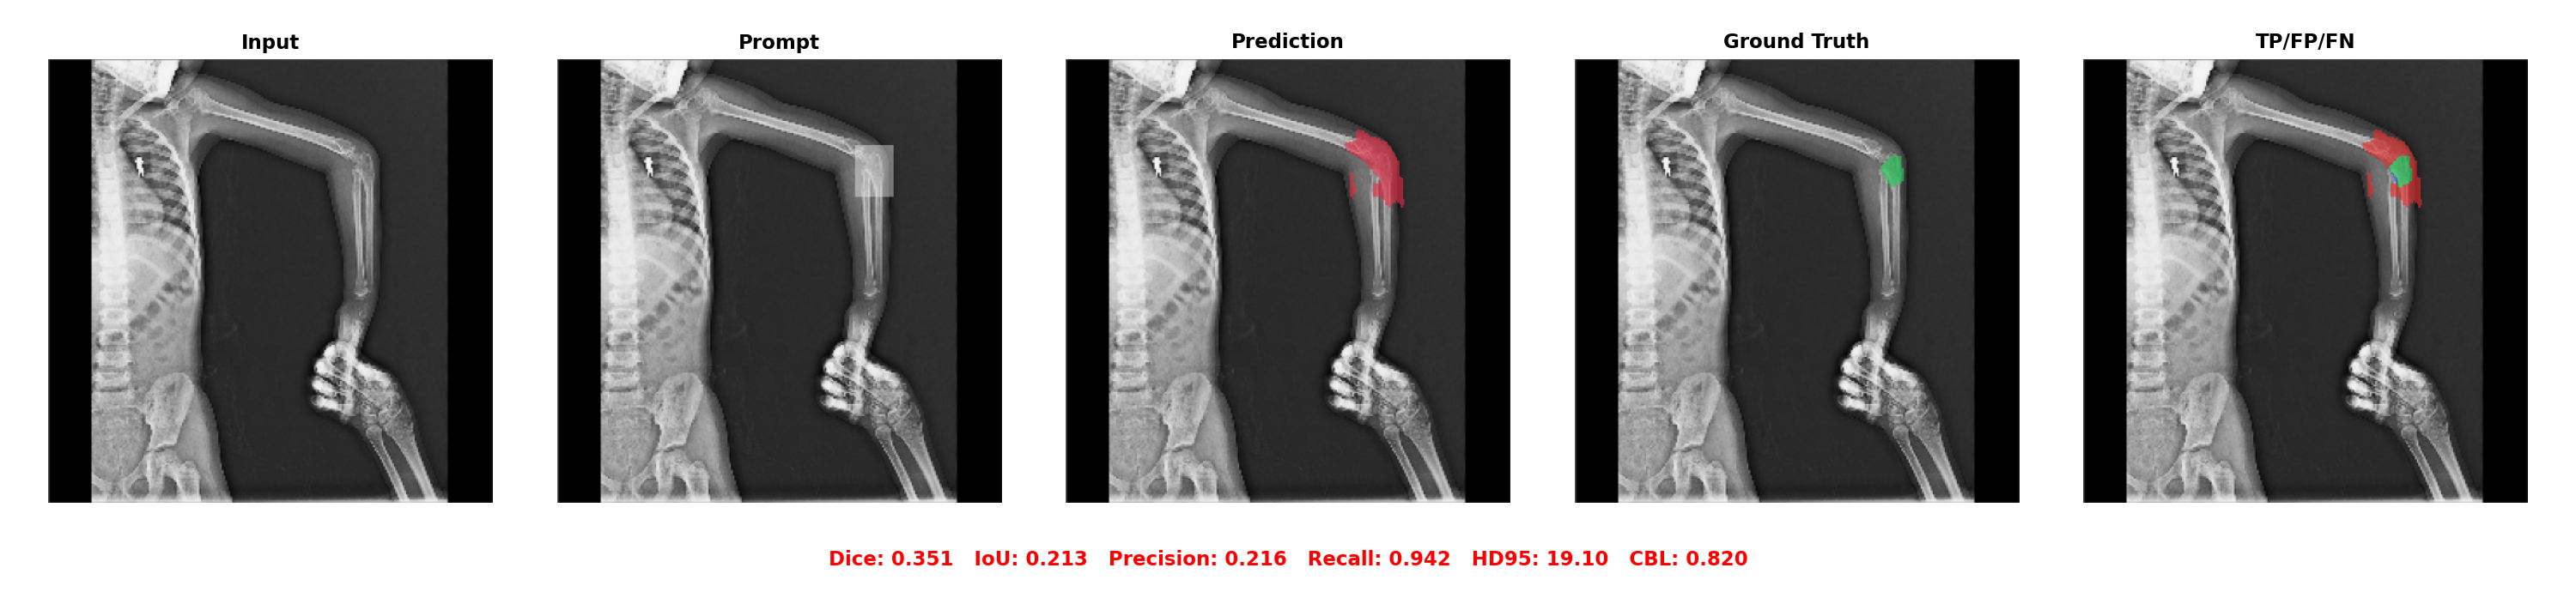

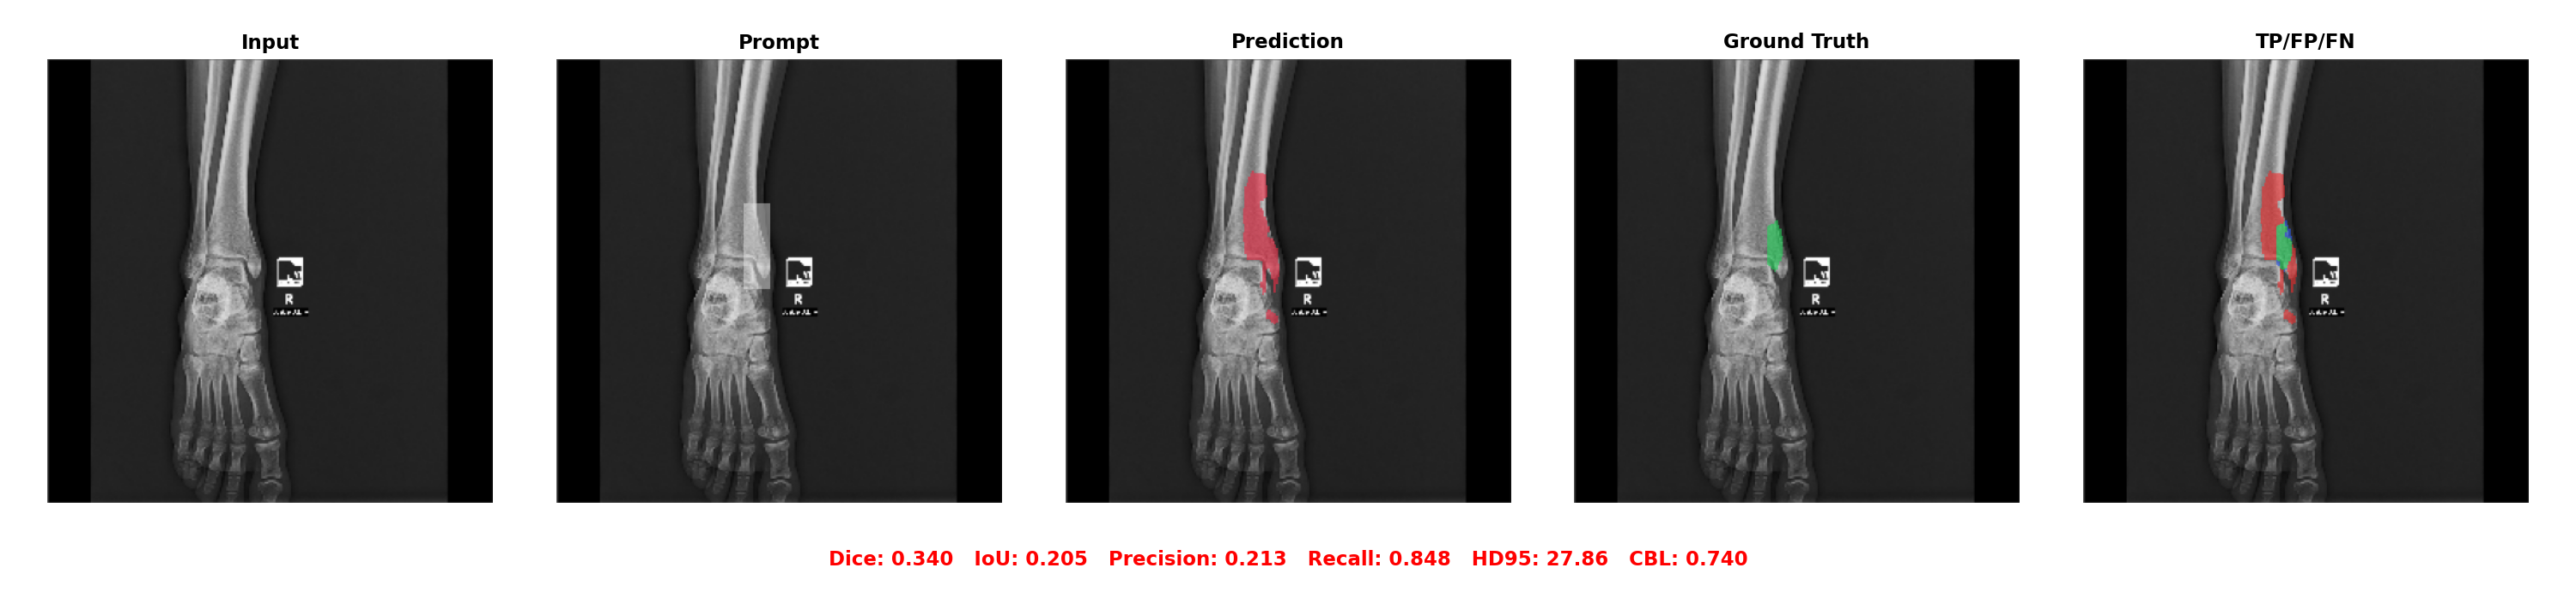

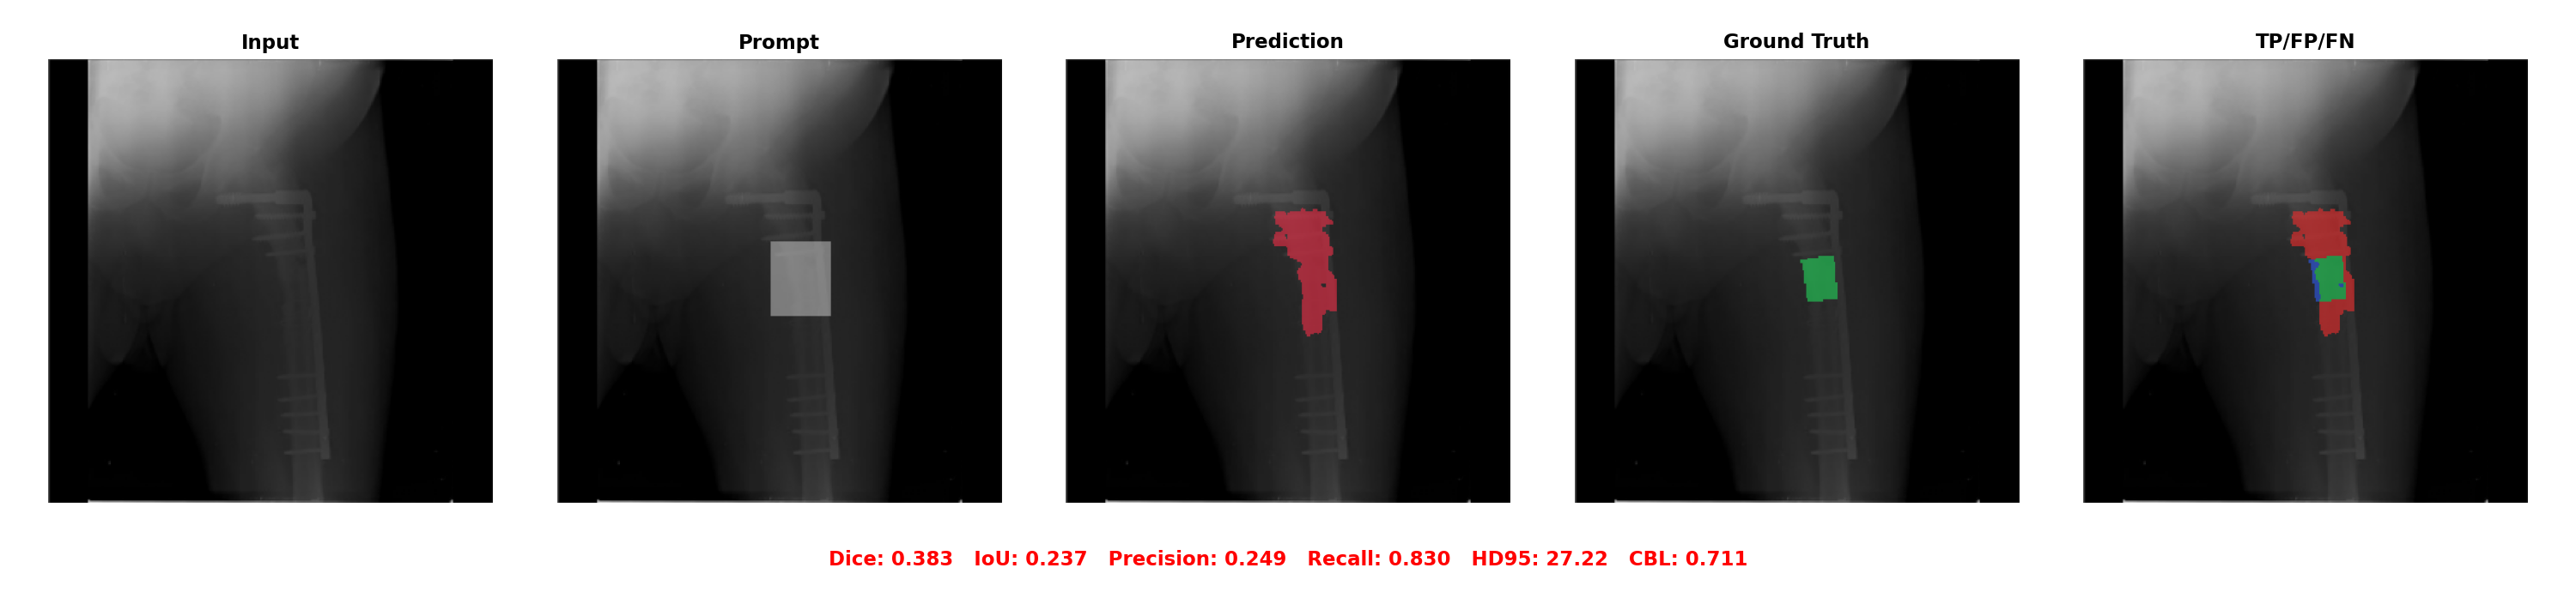

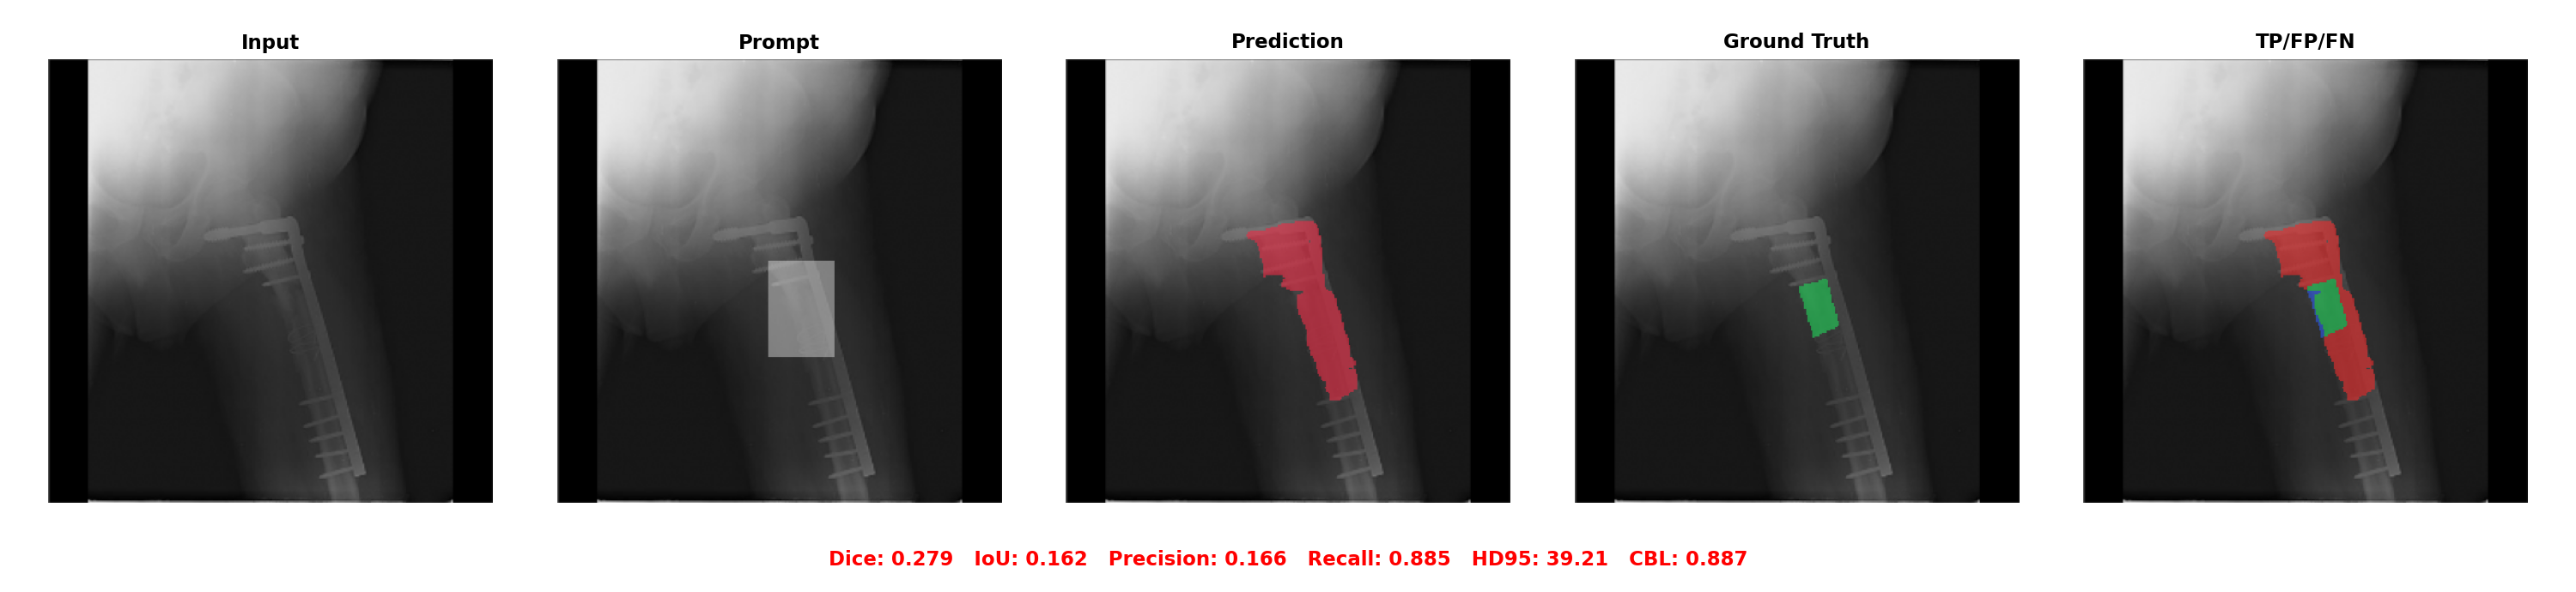

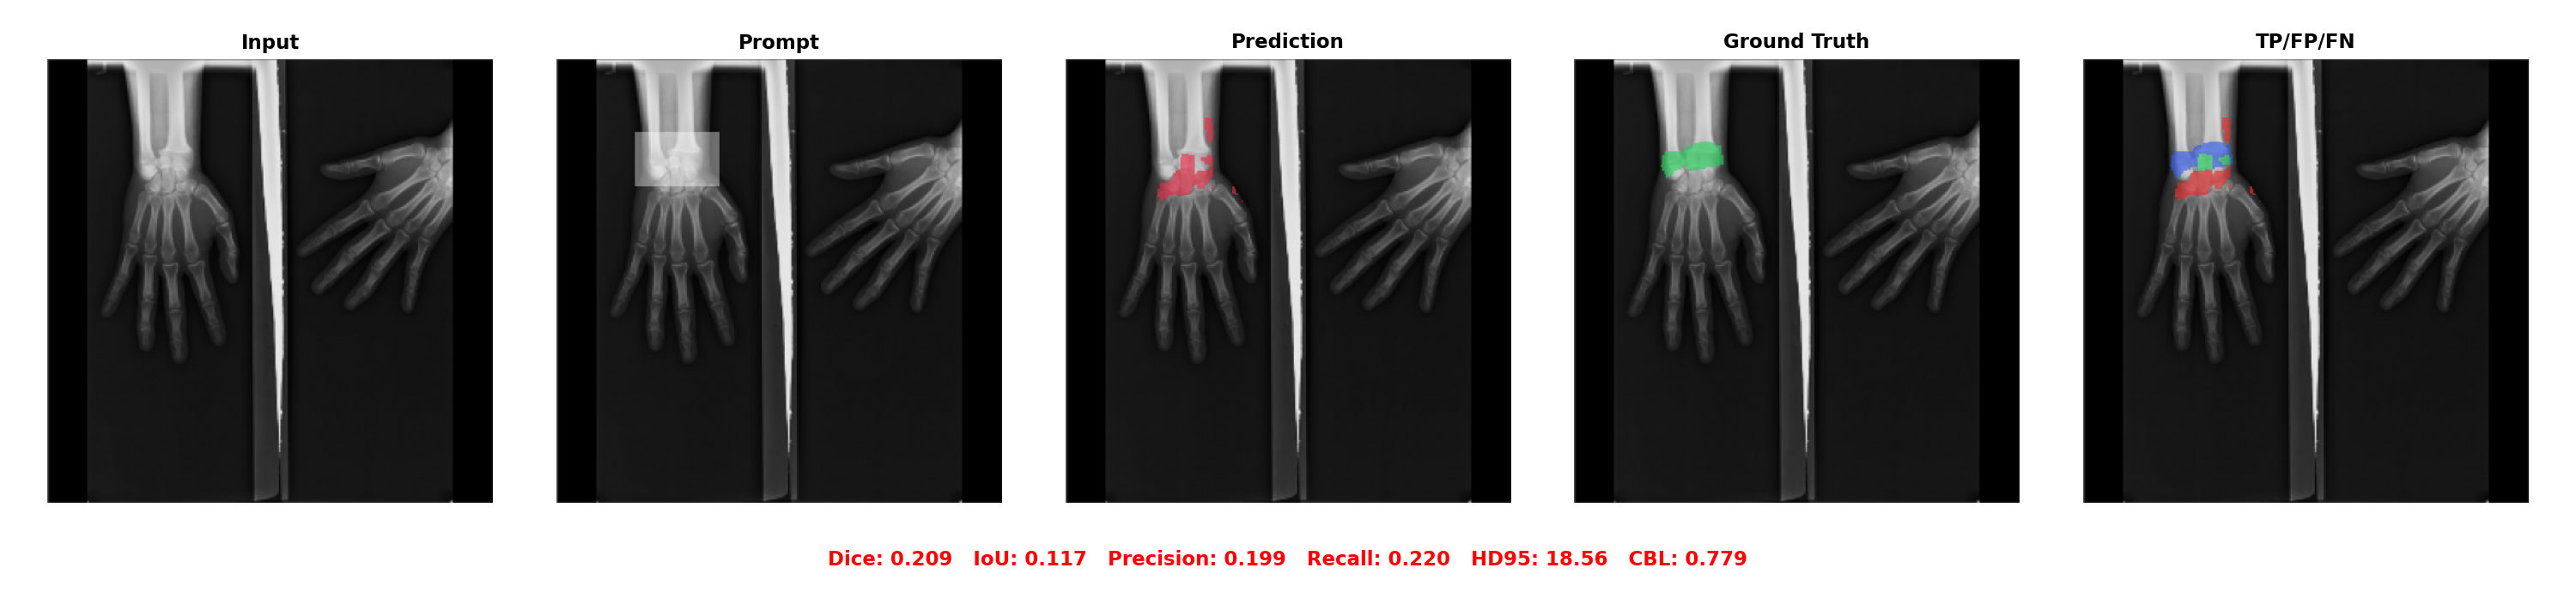

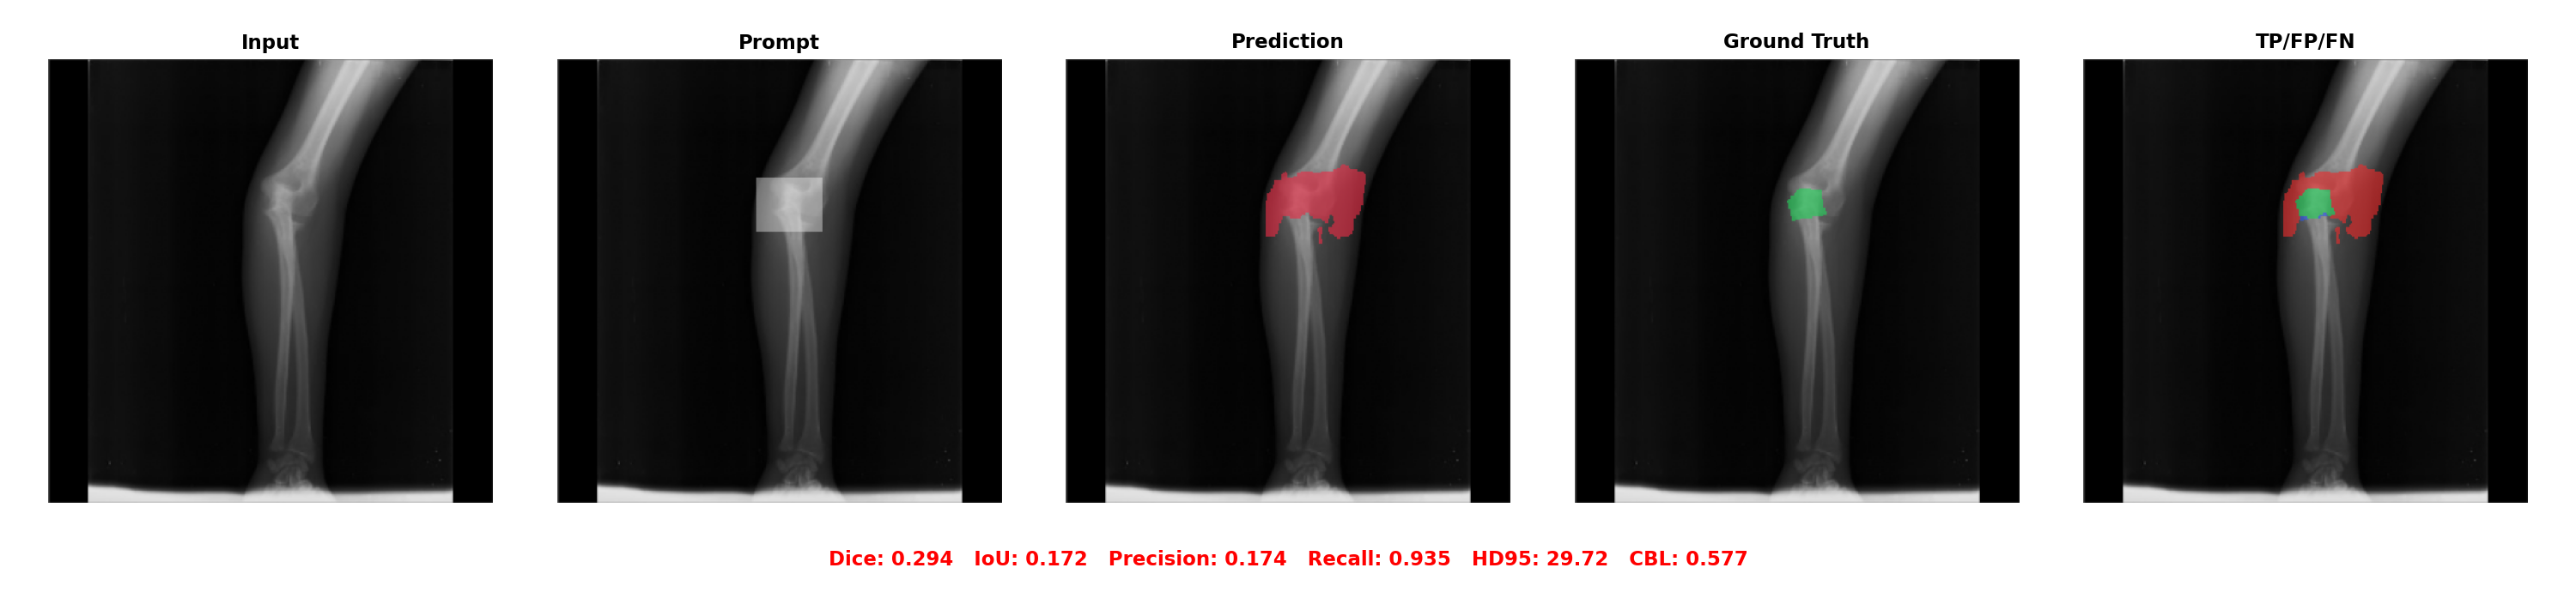

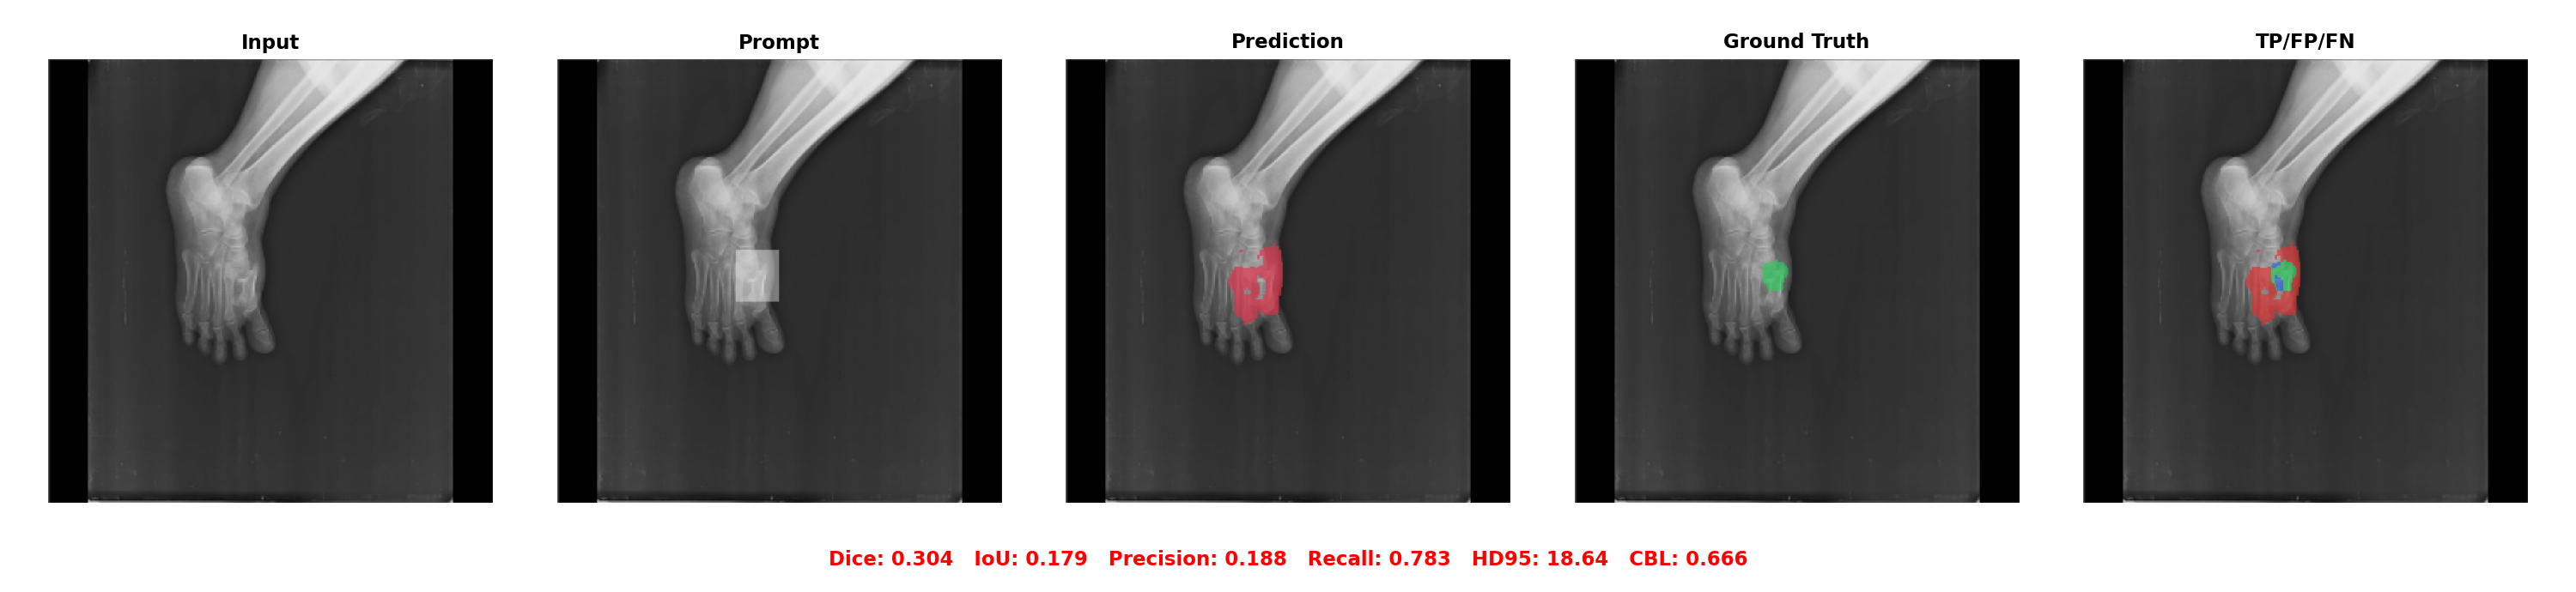

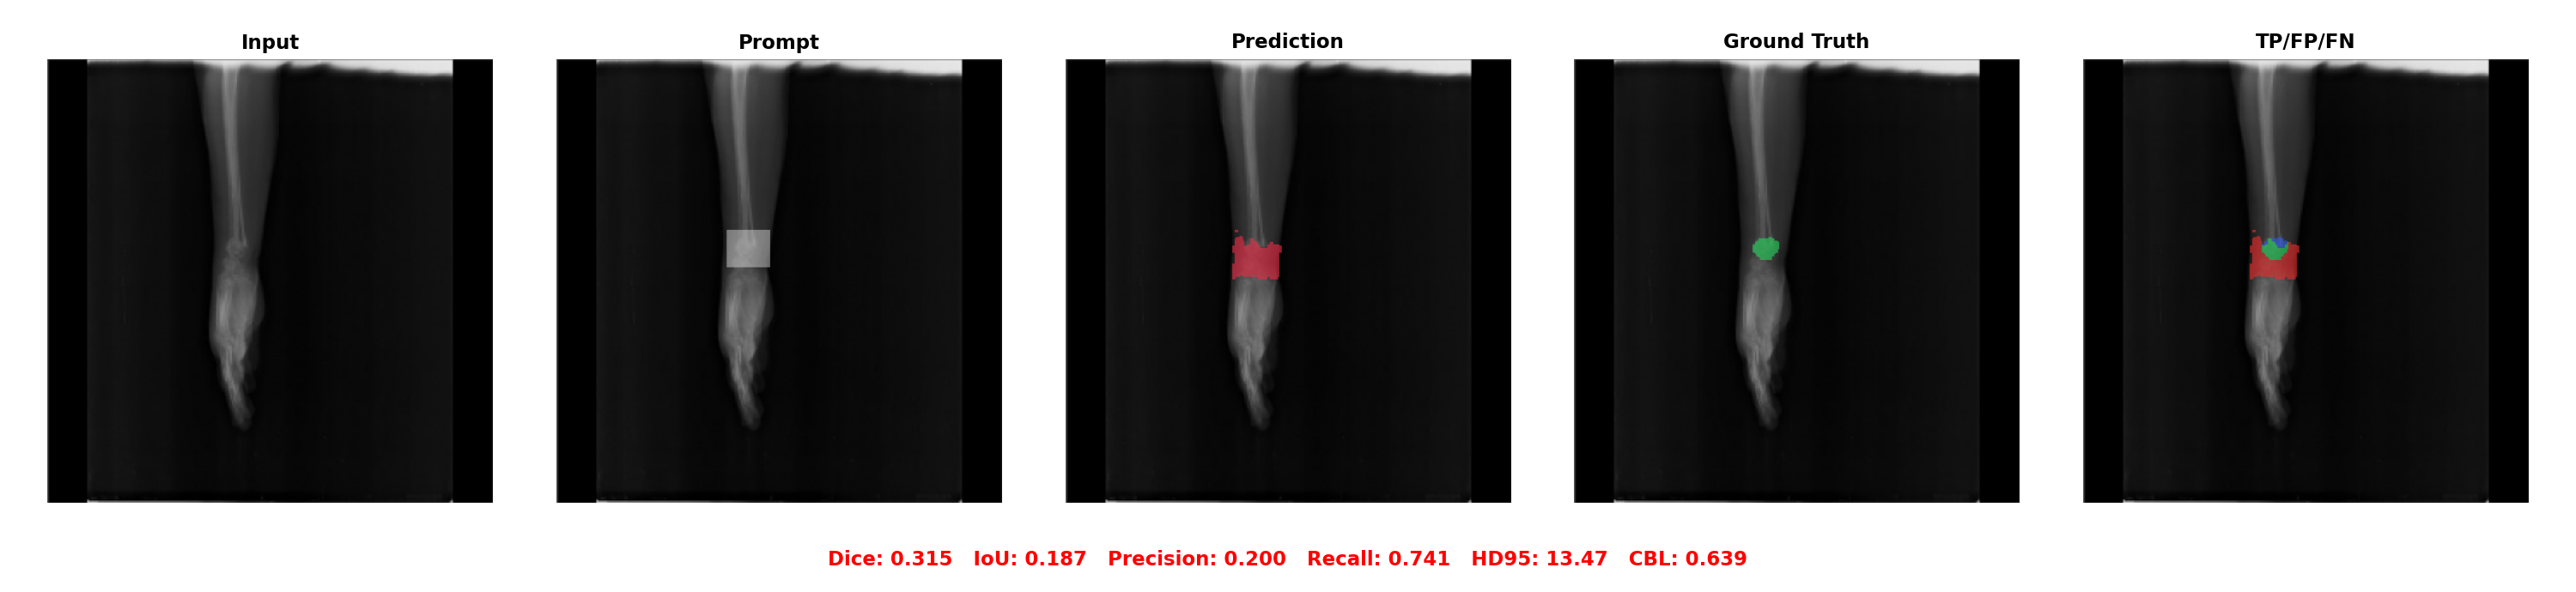

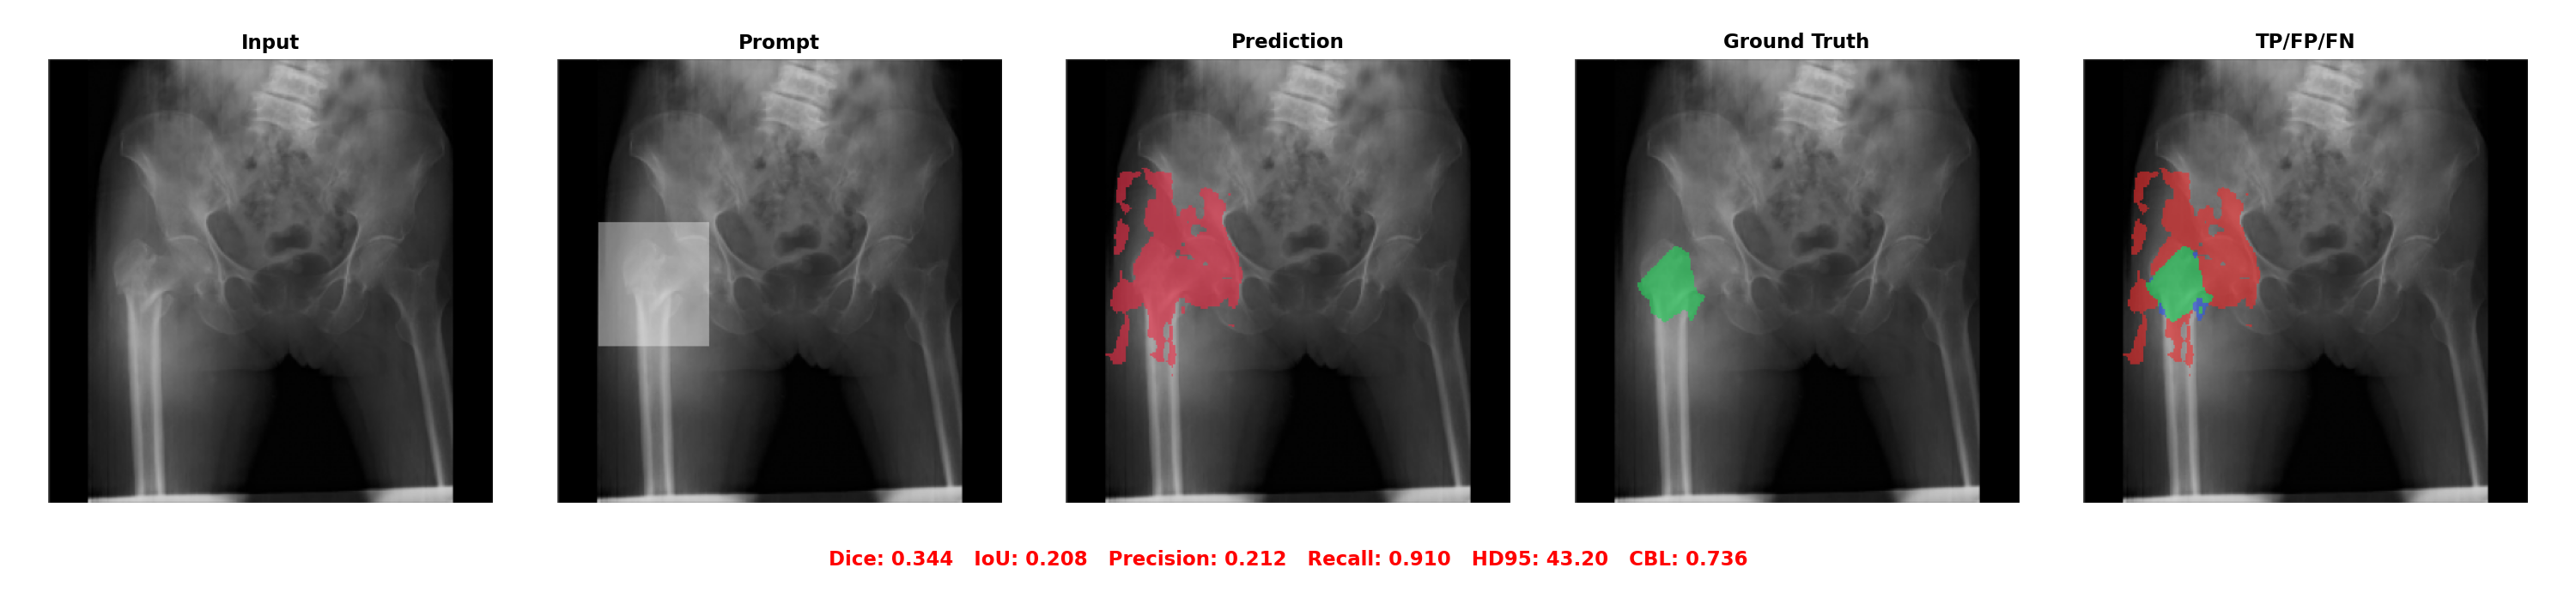

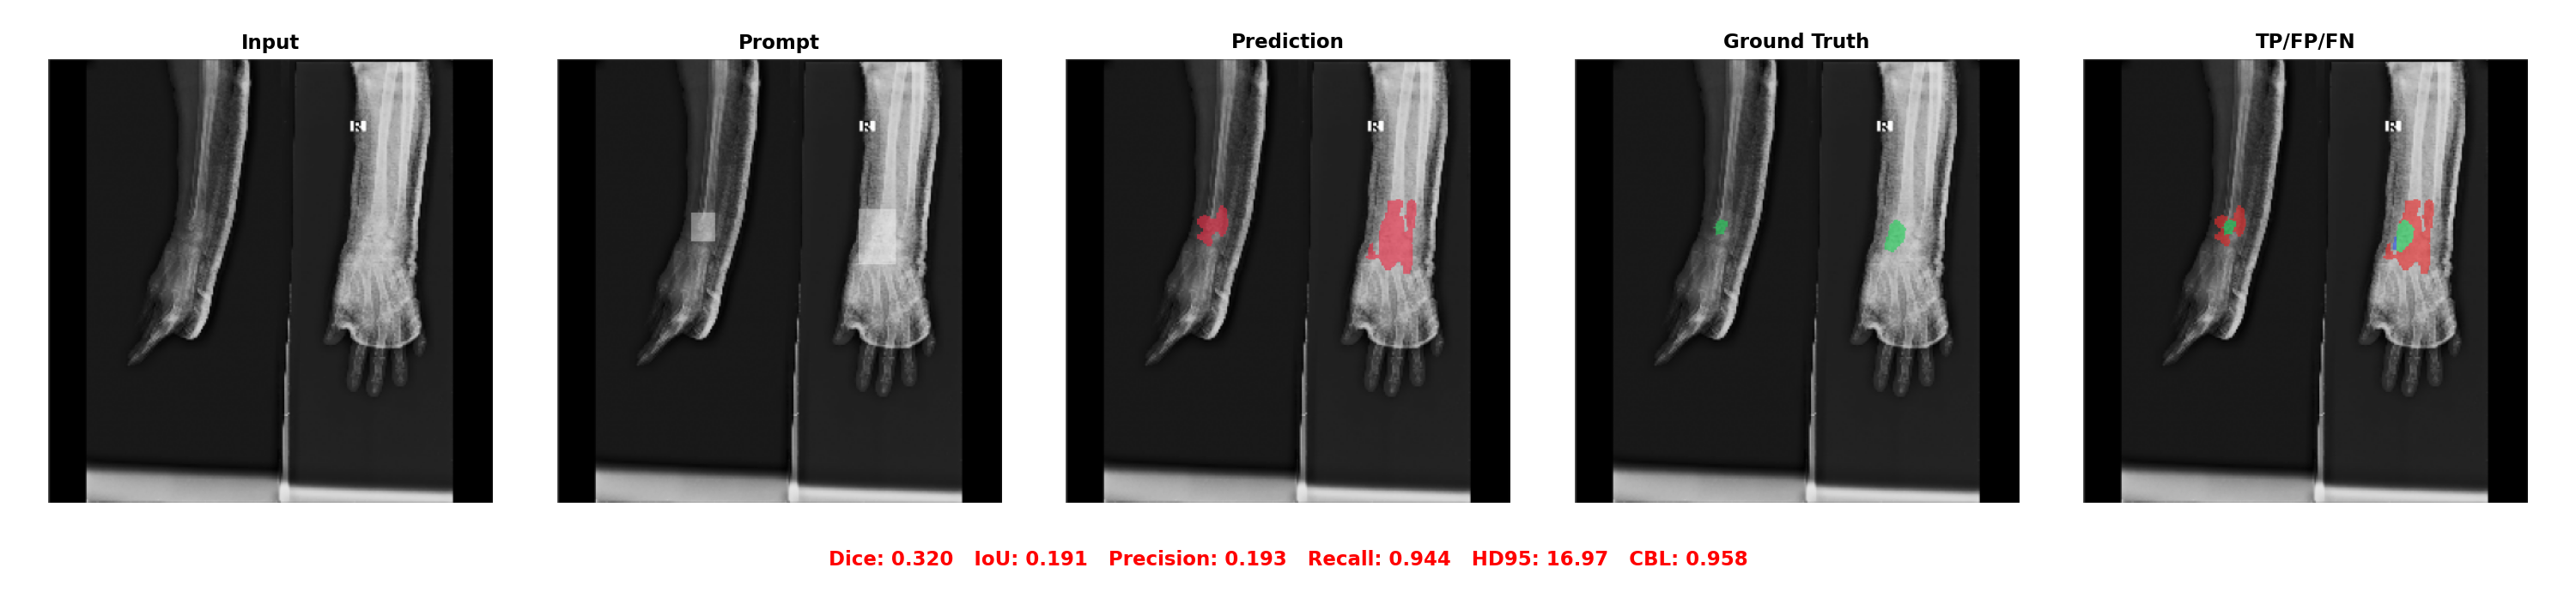

In [24]:
from qualitative_visualization import export_qualitative_rows
# ── Visualization: balanced test stems (center_zoom, image-level merged) ─
import matplotlib.pyplot as plt
import numpy as np
import cv2, os, json, glob as _glob
from matplotlib.patches import Patch, Rectangle
from IPython.display import display as _ipy_display

PRED_DIR    = "workdir/zeroshot_results/sammed/boxes_center_zoom"

def _resize_and_pad(array, size, interpolation, pad_value=0):
    """Isotropic resize + center pad to a size x size square, matches
    dataset.py's PromptSegmentationDataset._resize_and_pad (no aspect distortion)."""
    h, w = array.shape[:2]
    scale = min(size / w, size / h)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(array, (new_w, new_h), interpolation=interpolation)
    padded = np.full((size, size), pad_value, dtype=resized.dtype)
    pad_left = (size - new_w) // 2
    pad_top = (size - new_h) // 2
    padded[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized
    return padded
MASK_DIR    = "dataset_FracAtlas/test/masks"
S           = 256
MODEL_LABEL = "SAM-Med2D Zero-Shot"

assert os.path.exists(PRED_DIR), f'❌ Predictions not found. Run the center_zoom test cell first.\n  {PRED_DIR}'
assert 'BALANCED_TEST_STEMS_R256' in dir(), '❌ Run the PGA visualization cell first to define BALANCED_TEST_STEMS_R256.'

# 1. Group per-polygon masks to the image level (max-merge)
with open("dataset_FracAtlas/label2image_test.json") as f:
    label2image = json.load(f)

stem_data = {}
for mask_rel, img_rel in label2image.items():
    mask_name = os.path.basename(mask_rel)
    parts = mask_name.rsplit('_', 1)
    if len(parts) < 2: continue
    stem = parts[0]

    gt_p = cv2.imread(mask_rel, cv2.IMREAD_GRAYSCALE)
    pr_p = cv2.imread(os.path.join(PRED_DIR, mask_name), cv2.IMREAD_GRAYSCALE)
    if gt_p is None: continue
    gt256 = _resize_and_pad(gt_p, S, cv2.INTER_NEAREST).astype(np.float32)
    if gt256.max() > 1: gt256 /= 255.
    pr256 = np.zeros((S, S), dtype=np.float32)
    if pr_p is not None:
        pr256 = _resize_and_pad(pr_p, S, cv2.INTER_NEAREST).astype(np.float32)
        if pr256.max() > 1: pr256 /= 255.

    if stem not in stem_data:
        img_bgr = cv2.imread(img_rel, cv2.IMREAD_GRAYSCALE)
        img256  = _resize_and_pad(img_bgr, S, cv2.INTER_LINEAR) if img_bgr is not None else np.zeros((S, S), np.uint8)
        stem_data[stem] = dict(gt_union=gt256.copy(), prob_max=pr256.copy(),
                               n_poly=1, img=img256.astype(np.float32) / 255.)
    else:
        np.maximum(stem_data[stem]['gt_union'], gt256, out=stem_data[stem]['gt_union'])
        np.maximum(stem_data[stem]['prob_max'], pr256, out=stem_data[stem]['prob_max'])
        stem_data[stem]['n_poly'] += 1

# 2. Compute metrics and keep only the shared balanced stems
EPS = 1e-6
def _calc(prob, gt):
    pm = (prob > 0.5).astype(np.float32); gm = (gt > 0.5).astype(np.float32)
    tp = (pm * gm).sum(); fp = (pm * (1 - gm)).sum(); fn = ((1 - pm) * gm).sum()
    return dict(dice=float((2*tp+EPS)/(2*tp+fp+fn+EPS)),
                iou=float((tp+EPS)/(tp+fp+fn+EPS)),
                precision=float(tp/(tp+fp+EPS)),
                recall=float((tp+EPS)/(tp+fn+EPS)))

recs = []
for _raw_stem in BALANCED_TEST_STEMS_R256:
    stem = os.path.splitext(_raw_stem)[0]  # BALANCED_TEST_STEMS_R256 keeps the extension, stem_data keys don't
    assert stem in stem_data, f'{MODEL_LABEL} is missing qualitative stem: {stem}'
    d = stem_data[stem]
    m = _calc(d['prob_max'], d['gt_union'])
    recs.append(dict(img_name=stem, img=d['img'],
                     gt=d['gt_union'], prob=d['prob_max'],
                     n_poly=d['n_poly'], **m))

N_SHOW = len(recs)
fig, axes = plt.subplots(N_SHOW, 5, figsize=(20, 4 * N_SHOW))
if N_SHOW == 1:
    axes = axes[np.newaxis, :]
fig.suptitle(f'{MODEL_LABEL} - balanced test images (same stems as PGA)', fontsize=13, y=1.001)

col_titles = ['Input image', 'Image + box prompts', 'Prediction (merged)', 'Ground truth', 'TP/FP/FN']
for ax, ct in zip(axes[0], col_titles):
    ax.set_title(ct, fontsize=10, fontweight='bold')

def get_per_poly_bboxes(stem, r=0.30):
    bboxes = []
    for pm_path in sorted(_glob.glob(os.path.join(MASK_DIR, f"{stem}_*.png"))):
        pm_raw = cv2.imread(pm_path, cv2.IMREAD_GRAYSCALE)
        if pm_raw is None: continue
        pm256 = _resize_and_pad(pm_raw, S, cv2.INTER_NEAREST).astype(np.float32)
        if pm256.max() > 1: pm256 /= 255.
        ys_p, xs_p = np.where(pm256 > 0.5)
        if len(xs_p) == 0: continue
        x0, x1 = int(xs_p.min()), int(xs_p.max())
        y0, y1 = int(ys_p.min()), int(ys_p.max())
        gw, gh = x1 - x0, y1 - y0
        bx0 = max(0, x0 - gw * r); bx1 = min(S, x1 + gw * r)
        by0 = max(0, y0 - gh * r); by1 = min(S, y1 + gh * r)
        bboxes.append((bx0, by0, bx1 - bx0, by1 - by0))
    return bboxes

for count, rec in enumerate(recs):
    img_np  = rec['img']
    gt_np   = (rec['gt']   > 0.5).astype(float)
    pred_np = (rec['prob'] > 0.5).astype(float)
    n       = rec['n_poly']
    dice    = rec['dice'];  iou  = rec['iou']
    pre     = rec['precision']; rec_ = rec['recall']

    row = axes[count]
    bg  = np.stack([img_np] * 3, axis=-1)
    row[0].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    row[0].set_ylabel(f'#{count+1} [{n} poly]\nDice={dice:.3f}', fontsize=8)

    row[1].imshow(img_np, cmap='gray', vmin=0, vmax=1)
    for bbox in get_per_poly_bboxes(rec['img_name']):
        row[1].add_patch(Rectangle((bbox[0], bbox[1]), bbox[2], bbox[3], fill=False, edgecolor='yellow', linewidth=1.5))
    row[1].set_title(rec['img_name'], fontsize=6, pad=2)

    pr_ov = bg.copy(); pr_ov[..., 0] = np.clip(pr_ov[..., 0] + pred_np * 0.55, 0, 1); pr_ov[..., 1] = np.clip(pr_ov[..., 1] - pred_np * 0.2, 0, 1)
    row[2].imshow(pr_ov); row[2].set_title(f'Dice={dice:.3f}  IoU={iou:.3f}', fontsize=7, color='darkred', pad=2)
    gt_ov = bg.copy(); gt_ov[..., 1] = np.clip(gt_ov[..., 1] + gt_np * 0.55, 0, 1); gt_ov[..., 0] = np.clip(gt_ov[..., 0] - gt_np * 0.2, 0, 1)
    row[3].imshow(gt_ov)

    inter = bg.copy()
    inter[..., 1] = np.clip(inter[..., 1] + pred_np * gt_np * 0.9, 0, 1)
    inter[..., 0] = np.clip(inter[..., 0] + pred_np * (1-gt_np) * 1.0, 0, 1)
    inter[..., 2] = np.clip(inter[..., 2] + (1-pred_np) * gt_np * 1.0, 0, 1)
    row[4].imshow(inter); row[4].set_title(f'Pre={pre:.3f}  Rec={rec_:.3f}', fontsize=7, color='saddlebrown', pad=2)
    for ax in row:
        ax.axis('off')
        ax.add_patch(plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#555555', linewidth=1.0, clip_on=False))

fig.legend(handles=[Patch(facecolor='green', label='TP'), Patch(facecolor='red', label='FP'), Patch(facecolor='blue', label='FN')],
           loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.5, -0.005))
plt.tight_layout()
export_qualitative_rows(fig, axes, recs)
plt.close(fig)


---
# PART 4 - Summary and Comparison Across 3 Models
---


════════════════════════════════════════════════════════════════════════════════
  COMPARISON SUMMARY (center_zoom) - Image-level metrics (N≈87 test images)
════════════════════════════════════════════════════════════════════════════════
  Model                          Dice↑      IoU↑     Prec↑      Rec↑HD95↓ (px)      CBL↑
  -----------------------------------------------------------------------------
  PGA-UNet                      0.6287    0.4704    0.5026    0.9071   10.6074    0.8951
  SAM-Med2D Zero-Shot           0.2620    0.1558    0.1720    0.6474   21.2799    0.7516
  SAM-Med2D Fine-tuned          0.5628    0.4165    0.6357    0.5660    7.9983    0.8458
════════════════════════════════════════════════════════════════════════════════
  Δ PGA-UNet − SAM-ZS  [DICE        ]: +0.3667
  Δ PGA-UNet − SAM-FT  [DICE        ]: +0.0659

  Δ PGA-UNet − SAM-ZS  [IOU         ]: +0.3146
  Δ PGA-UNet − SAM-FT  [IOU         ]: +0.0539

  Δ PGA-UNet − SAM-ZS  [PRECISION   ]: +0.3306
  Δ PGA

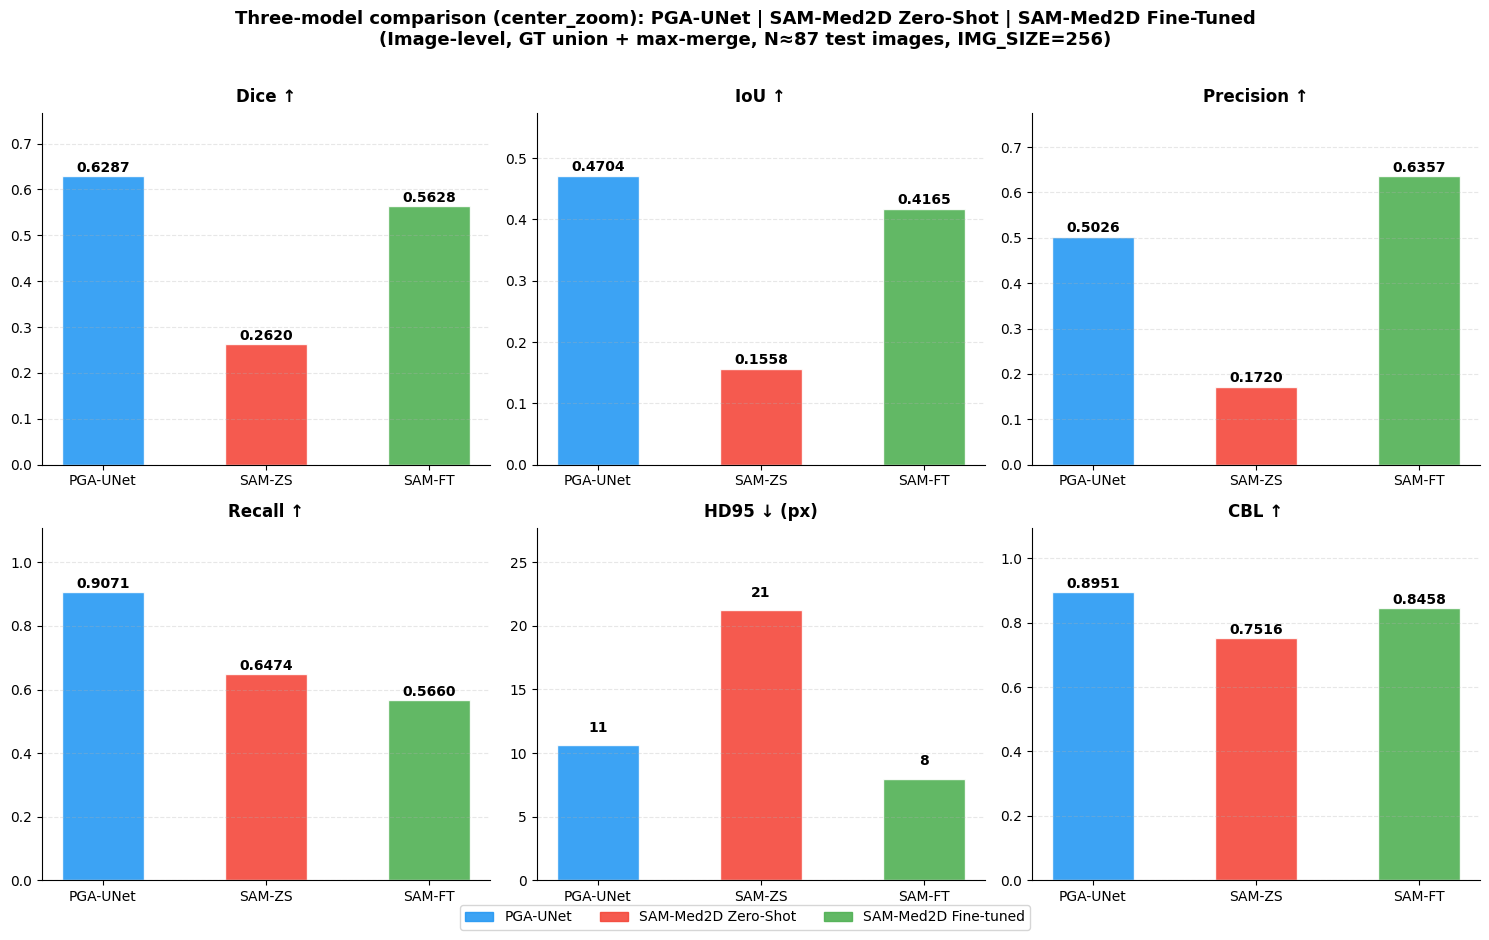


✅ Figure saved: comparison_3models_centerzoom.png


In [25]:
# ══════════════════════════════════════════════════════════════════════
# COMPARISON SUMMARY (center_zoom): PGA-UNet vs SAM-Med2D Zero-Shot vs SAM-Med2D Fine-Tuned
# Use the results computed directly in the test cells above; do not hard-code any numbers.
# ══════════════════════════════════════════════════════════════════════
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

assert 'pga_results' in dir(), '❌ The PGA-UNet test cell (2 prompt modes) has not been run yet.'
assert 'zs_results'  in dir(), '❌ The SAM-Med2D zero-shot results cell has not been run yet.'
assert 'ft_results'  in dir(), '❌ The SAM-Med2D fine-tuned results cell has not been run yet.'

MODE = 'center_zoom'
for _name, _res in [('PGA-UNet', pga_results), ('SAM-Med2D Zero-Shot', zs_results),
                     ('SAM-Med2D Fine-tuned', ft_results)]:
    assert MODE in _res, f'❌ {_name}: no results found for mode={MODE!r}; rerun the corresponding test cell.'

data_zo = {
    'PGA-UNet':             pga_results[MODE],
    'SAM-Med2D Zero-Shot':  zs_results[MODE],
    'SAM-Med2D Fine-tuned': ft_results[MODE],
}

MODELS  = list(data_zo.keys())
KEYS    = ['dice', 'iou', 'precision', 'recall', 'hd95', 'cbl']
HDRS    = ['Dice\u2191', 'IoU\u2191', 'Prec\u2191', 'Rec\u2191', 'HD95\u2193 (px)', 'CBL\u2191']
METRICS = list(zip(KEYS, ['Dice \u2191', 'IoU \u2191', 'Precision \u2191',
                           'Recall \u2191', 'HD95 \u2193 (px)', 'CBL \u2191']))
COLORS  = ['#2196F3', '#F44336', '#4CAF50']   # PGA=blue, ZS=red, FT=green
X_LBLS  = ['PGA-UNet', 'SAM-ZS', 'SAM-FT']

# ── 1. Summary table ──────────────────────────────────────────────────────────
bar = '\u2550' * 80
print(f'\n{bar}')
print('  COMPARISON SUMMARY (center_zoom) - Image-level metrics (N\u224887 test images)')
print(f'{bar}')
print(f"  {'Model':<26}" + ''.join(f'{h:>10}' for h in HDRS))
print('  ' + '-' * 77)
for model, m in data_zo.items():
    print(f"  {model:<26}" + ''.join(f'{m[k]:>10.4f}' for k in KEYS))
print(f'{bar}')
for k in KEYS:
    suffix = '  (negative means PGA is better)' if k == 'hd95' else ''
    for comp in ['SAM-Med2D Zero-Shot', 'SAM-Med2D Fine-tuned']:
        delta = data_zo['PGA-UNet'][k] - data_zo[comp][k]
        tag   = 'ZS' if 'Zero' in comp else 'FT'
        print(f'  \u0394 PGA-UNet \u2212 SAM-{tag}  [{k.upper():<12}]: {delta:+.4f}{suffix}')
    print()

# ── 2. Bar charts ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
fig.suptitle('Three-model comparison (center_zoom): PGA-UNet | SAM-Med2D Zero-Shot | SAM-Med2D Fine-Tuned\n'
             '(Image-level, GT union + max-merge, N\u224887 test images, IMG_SIZE=256)',
             fontsize=13, fontweight='bold', y=1.01)

x = np.arange(len(MODELS))
for ax_idx, (metric_key, metric_label) in enumerate(METRICS):
    ax   = axes[ax_idx]
    vals = [data_zo[m][metric_key] for m in MODELS]

    bars = ax.bar(x, vals, 0.5, color=COLORS, alpha=0.88, edgecolor='white')
    for bar_, v in zip(bars, vals):
        fmt = f'{v:.0f}' if metric_key == 'hd95' else f'{v:.4f}'
        ax.text(bar_.get_x() + bar_.get_width()/2,
                bar_.get_height() + (0.004 if metric_key != 'hd95' else 0.8),
                fmt, ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(metric_label, fontsize=12, fontweight='bold', pad=8)
    hi = max(vals)
    ax.set_ylim(0, hi * 1.22 if metric_key != 'hd95' else hi * 1.30)
    ax.set_xticks(x); ax.set_xticklabels(X_LBLS, fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

handles = [mpatches.Patch(color=c, alpha=0.88, label=l)
           for c, l in zip(COLORS, ['PGA-UNet', 'SAM-Med2D Zero-Shot', 'SAM-Med2D Fine-tuned'])]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig('/kaggle/working/comparison_3models_centerzoom.png', dpi=150, bbox_inches='tight')
from IPython.display import display as _ipy_display
_ipy_display(fig)
plt.close(fig)
print('\n✅ Figure saved: comparison_3models_centerzoom.png')